# User Behavior Clustering & Autoencoder — Decision‑Oriented Notebook

**What this notebook does:**
- Create **interpretable characteristics of user-level behaviour** from slot-level data (e.g., daily energy quotas, entropy, weekend/peak usage, circadian concentration, daily variability, peaks).
- Pre-processes features with targeted transformations (e.g., logit for actions, winsorisation + log1p for variability), reduces collinearity, and applies robust scaling.
- Evaluate and adjust **K‑Means** (default setting **K=5**), save artefacts (model, preprocessors, labels).
- Train a dense symmetric autoencoder (AE)** to obtain a **latent embedding** and a **reconstruction error (MSE)** per user; it also supports reloading previously saved AE outputs.
- Produces diagnostic figures (PCA, Δ behaviour heat map, latent dispersion, reconstruction error per cluster) and a **Where‑to‑Act** that combines **opportunities** (reward) and **stability** (low overwriting), optionally penalised by AE risk.

**How to run:**
- If you already have artifacts under `artifacts/clustering_behavior_K5/` and `artifacts/ae_K5/`, use the **Instant Reload** cells to regenerate figures/tables without refitting.
- Otherwise, run cells sequentially to rebuild **features, preprocessing, KMeans, AE, figures**.

**Inputs expected:** a long table at slot level per user (`ca_number`) with energy (e.g., `energy_Wh`), time features, weekend/peak flags, and related fields.

**Outputs & artifacts (written by the code):**
- `artifacts/clustering_behavior_K5/`: `kmeans.joblib`, `preprocessor.joblib`, `robust_scaler.joblib`, `metadata.json`, optional `labels_K5.parquet`.
- `artifacts/ae_K5/`: `ae_best_K5.keras`, `tables/embeddings_K5.parquet`, `tables/recon_error_K5.parquet`, `ae_metadata_K5.json`.
- Optional report PNGs (PCA, heatmaps, latent scatter, error, Where‑to‑Act).

*Reproducibility note:* where applicable, seeds are set in code cells; artifacts enable **instant re‑analysis** without refitting.


In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import joblib
from typing import Dict, List, Optional, Tuple
from __future__ import annotations
import json, os, warnings
from dataclasses import dataclass, asdict
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.utils import check_random_state
import matplotlib.pyplot as plt


## 1) Preamble & Reproducibility

This section sets paths (e.g., `ART_DIR`, `AE_DIR`), imports dependencies, and loads the base dataset.  
Keep `ID_COL` consistent across the notebook. Artifacts are written under `artifacts/…` for fast reloads.


In [29]:
# Setup
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score

# Reproducibilità
SEED = 42
np.random.seed(SEED)

#centralizzata
POSSIBILI_VALORI = {
    "winsor_q_low": 0.005,
    "winsor_q_high": 0.995,
    "corr_threshold": 0.95,     # taglio collinearità post-scaling
    "min_variance": 1e-6,       # drop near-constant
}

# # Output dir (salvataggi)
# OUT_DIR = Path('/mnt/data/reports')
# (OUT_DIR / 'figures').mkdir(parents=True, exist_ok=True)


In [2]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.append("src")

In [3]:
df_switch_clean = pd.read_csv("data/powbal clean/powbal_clean.csv", low_memory=False)


In [4]:
from powbal.full_pipeline import apply_all_transformations
df_switch_transformed = apply_all_transformations(df_switch_clean)

In [9]:
df_switch_transformed.head()

,power,schedule_id,ca_number,ca_number_str,timestamp,off,on,reward_rate,notify_participant_at,posted_to_api,...,rolling_daily_reward,event_intensity,event_recent_history,active_today,event_upcoming_count_3h,event_upcoming_cat_3h,event_next_run_length,event_next_run_class,event_recent_count_8h,override_rolling_8h
0,66.309998,NaN,60000191183,60000191183,2023-10-17 04:00,NaN,NaN,0,NaN,NaN,...,0.0,0,0,False,0,none,0,none,0,0.0
1,70.660004,NaN,60000191183,60000191183,2023-10-17 04:31,NaN,NaN,0,NaN,NaN,...,0.0,0,0,False,0,none,0,none,0,0.0
2,28.690001,NaN,60000191183,60000191183,2023-10-17 06:00,NaN,NaN,0,NaN,NaN,...,0.0,0,0,False,0,none,0,none,0,0.0
3,29.820000,NaN,60000191183,60000191183,2023-10-17 07:00,NaN,NaN,0,NaN,NaN,...,0.0,0,0,False,0,none,0,none,0,0.0
4,79.440002,NaN,60000191183,60000191183,2023-10-17 07:30,NaN,NaN,0,NaN,NaN,...,0.0,0,0,False,0,none,0,none,0,0.0


In [ ]:
This

In [2]:
#df_switch_transformed = pd.read_parquet("data/df_switch_derived.parquet")

In [17]:
#df_switch_derived.head()

,power,schedule_id,ca_number,ca_number_str,timestamp,off,on,reward_rate,notify_participant_at,posted_to_api,...,rolling_daily_reward,event_intensity,event_recent_history,active_today,event_upcoming_count_3h,event_upcoming_cat_3h,event_next_run_length,event_next_run_class,event_recent_count_8h,override_rolling_8h
0,66.309998,NaN,60000191183,60000191183,2023-10-17 04:00,NaN,NaN,0,NaN,NaN,...,0.0,0,0,False,0,none,0,none,0,0.0
1,70.660004,NaN,60000191183,60000191183,2023-10-17 04:31,NaN,NaN,0,NaN,NaN,...,0.0,0,0,False,0,none,0,none,0,0.0
2,28.690001,NaN,60000191183,60000191183,2023-10-17 06:00,NaN,NaN,0,NaN,NaN,...,0.0,0,0,False,0,none,0,none,0,0.0
3,29.820000,NaN,60000191183,60000191183,2023-10-17 07:00,NaN,NaN,0,NaN,NaN,...,0.0,0,0,False,0,none,0,none,0,0.0
4,79.440002,NaN,60000191183,60000191183,2023-10-17 07:30,NaN,NaN,0,NaN,NaN,...,0.0,0,0,False,0,none,0,none,0,0.0


In [4]:
#from powbal.sequence_preparation import (
#    extract_event_timing_features,
#    build_sequences_for_modeling
#)

In [10]:
#df_switch_transformed.to_pickle("data/df_switch_transformed_new.pkl")

In [18]:
#df_switch_transformed_new = pd.read_pickle("data/df_switch_transformed_new.pkl")


In [7]:
#df_switch_transformed_new.head()

,power,schedule_id,ca_number,ca_number_str,timestamp,off,on,reward_rate,notify_participant_at,posted_to_api,...,morning_share,afternoon_share,evening_share,night_share,pod_entropy,excess_weekend_share,peak_energy_share,circadian_concentration,day_to_day_cv,peakiness_p95
0,66.309998,NaN,60000191183,60000191183,2023-10-17 04:00,NaN,NaN,0,NaN,NaN,...,0.091345,0.292303,0.192052,0.12844,0.895004,0.000759,0.192052,0.150208,0.378456,0.478971
1,70.660004,NaN,60000191183,60000191183,2023-10-17 04:31,NaN,NaN,0,NaN,NaN,...,0.091345,0.292303,0.192052,0.12844,0.895004,0.000759,0.192052,0.150208,0.378456,0.478971
2,28.690001,NaN,60000191183,60000191183,2023-10-17 06:00,NaN,NaN,0,NaN,NaN,...,0.091345,0.292303,0.192052,0.12844,0.895004,0.000759,0.192052,0.150208,0.378456,0.478971
3,29.820000,NaN,60000191183,60000191183,2023-10-17 07:00,NaN,NaN,0,NaN,NaN,...,0.091345,0.292303,0.192052,0.12844,0.895004,0.000759,0.192052,0.150208,0.378456,0.478971
4,79.440002,NaN,60000191183,60000191183,2023-10-17 07:30,NaN,NaN,0,NaN,NaN,...,0.091345,0.292303,0.192052,0.12844,0.895004,0.000759,0.192052,0.150208,0.378456,0.478971


In [8]:
df_switch_transformed.head()

,power,schedule_id,ca_number,ca_number_str,timestamp,off,on,reward_rate,notify_participant_at,posted_to_api,...,morning_share,afternoon_share,evening_share,night_share,pod_entropy,excess_weekend_share,peak_energy_share,circadian_concentration,day_to_day_cv,peakiness_p95
0,66.309998,NaN,60000191183,60000191183,2023-10-17 04:00,NaN,NaN,0,NaN,NaN,...,0.091345,0.292303,0.192052,0.12844,0.895004,0.000759,0.192052,0.150208,0.378456,0.478971
1,70.660004,NaN,60000191183,60000191183,2023-10-17 04:31,NaN,NaN,0,NaN,NaN,...,0.091345,0.292303,0.192052,0.12844,0.895004,0.000759,0.192052,0.150208,0.378456,0.478971
2,28.690001,NaN,60000191183,60000191183,2023-10-17 06:00,NaN,NaN,0,NaN,NaN,...,0.091345,0.292303,0.192052,0.12844,0.895004,0.000759,0.192052,0.150208,0.378456,0.478971
3,29.820000,NaN,60000191183,60000191183,2023-10-17 07:00,NaN,NaN,0,NaN,NaN,...,0.091345,0.292303,0.192052,0.12844,0.895004,0.000759,0.192052,0.150208,0.378456,0.478971
4,79.440002,NaN,60000191183,60000191183,2023-10-17 07:30,NaN,NaN,0,NaN,NaN,...,0.091345,0.292303,0.192052,0.12844,0.895004,0.000759,0.192052,0.150208,0.378456,0.478971


In [2]:
df_switch_transformed = pd.read_pickle("data/df_switch_transformed_1.pkl")

## 2) Build Behavior Features (User‑Level Matrix)

I constructed per‑user **behavior** features from the long table, then aggregate (median) at user level.  
Included features typically cover **Part‑of‑Day** energy shares (Morning/Afternoon/Evening), **`pod_entropy`**, **`excess_weekend_share`**, **`peak_energy_share`**, **`circadian_concentration`**, **`day_to_day_cv`**, and **`peakiness_p95`**.  
PoD shares are canonicalized; duplicates are removed to ensure unique names.


In [3]:
# === 0A) Feature engineering comportamentale (Metodo C) ===
# Requires at least the following in the df: 'ca_number' and an energy measurement (e.g. 'energy_Wh').
# If 'part_of_day' and/or 'is_weekend' are not present, create them from 'parsed_datetime' (or 'hour').

def _pick_energy_col(d):
    for c in ['energy_Wh','total_energy_Wh','energy_wh','energy']:
        if c in d.columns: return c
    raise KeyError("Colonna energia non trovata (energy_Wh/total_energy_Wh/energy_wh/energy).")

def add_behavior_features(df_long: pd.DataFrame,
                          id_col: str = "ca_number") -> pd.DataFrame:
    df = df_long.copy()
    E = _pick_energy_col(df)

    # --- Part-of-day & weekend ------------------------------------------------
    # part_of_day: [Night, Morning, Afternoon, Evening]
    if 'part_of_day' not in df.columns:
        if 'parsed_datetime' in df.columns:
            hh = pd.to_datetime(df['parsed_datetime']).dt.hour
        elif 'hour' in df.columns:
            hh = df['hour'].astype(int)
        else:
            raise ValueError("Serve 'part_of_day' oppure 'parsed_datetime'/'hour'.")
        df['part_of_day'] = pd.cut(hh, [-0.1, 6, 12, 18, 24],
                                   labels=['Night','Morning','Afternoon','Evening'])
    if 'is_weekend' not in df.columns:
        if 'parsed_datetime' in df.columns:
            dt = pd.to_datetime(df['parsed_datetime'])
            df['is_weekend'] = (dt.dt.dayofweek >= 5).astype(int)
        else:
            df['is_weekend'] = 0

    # --- Quote energia per fascia oraria + share ------------------------------------------------
    g = df.groupby(id_col, observed=True)
    totE = g[E].sum().rename('total_energy')

    ed = df.pivot_table(index=id_col, columns='part_of_day', values=E, aggfunc='sum').fillna(0.0)
    for c in ['Morning','Afternoon','Evening','Night']:
        if c not in ed.columns: ed[c] = 0.0
    ed = ed[['Morning','Afternoon','Evening','Night']]

    shares = ed.div(totE, axis=0).fillna(0.0).clip(0, 1)
    # Nomi attesi dall’autoconfiguratore:
    shares.columns = ['morning_share','afternoon_share','evening_share','night_share']

    # --- Entropy of the "part of day" distribution (without Night to avoid sum=1) -----------
    def _entropy_row(r: pd.Series) -> float:
        z = r.replace(0, np.nan)
        return float((-(z*np.log(z))).sum(skipna=True))
    pod_entropy = shares[['morning_share','afternoon_share','evening_share']].apply(_entropy_row, axis=1).fillna(0.0)

    # --- “Excess weekend”: energia nei weekend oltre la quota di slot weekend -------------------
    weekE = df.loc[df['is_weekend']==1].groupby(id_col)[E].sum(min_count=1).reindex(totE.index).fillna(0.0)
    week_energy_share = (weekE/(totE+1e-6)).fillna(0.0)
    week_slot_share   = g['is_weekend'].mean().reindex(totE.index).fillna(0.0)
    excess_weekend_share = (week_energy_share - week_slot_share).fillna(0.0)

    # --- Peak energy share: se non hai 'is_peak', usa la quota serale come proxy ----------------
    if 'is_peak' in df.columns:
        peakE = df.loc[df['is_peak']==1].groupby(id_col)[E].sum(min_count=1).reindex(totE.index).fillna(0.0)
        peak_energy_share = (peakE/(totE+1e-6)).fillna(0.0)
    else:
        peak_energy_share = shares['evening_share'].copy()

    # --- Concentrazione circadiana (versore medio pesato dall’energia) --------------------------
    if 'parsed_datetime' in df.columns:
        hour = pd.to_datetime(df['parsed_datetime']).dt.hour.to_numpy()
    else:
        hour = df['hour'].to_numpy()
    theta = 2*np.pi*(hour % 24)/24.0
    w = df[E].to_numpy()
    cos_c = pd.Series(np.cos(theta)*w, index=df.index).groupby(df[id_col]).sum()
    sin_c = pd.Series(np.sin(theta)*w, index=df.index).groupby(df[id_col]).sum()
    circadian_concentration = (np.sqrt(cos_c**2 + sin_c**2)/(totE + 1e-6)).reindex(totE.index).fillna(0.0)

    # --- Day-to-day variability (CV) -----------------------------------------------------
    if 'parsed_datetime' in df.columns:
        df['date'] = pd.to_datetime(df['parsed_datetime']).dt.date
    elif 'date' not in df.columns:
        raise ValueError("Serve 'parsed_datetime' o 'date' per calcolare day_to_day_cv.")
    daily = df.groupby([id_col,'date'])[E].sum().reset_index()
    day_to_day_cv = daily.groupby(id_col)[E] \
        .agg(lambda x: float(x.std(ddof=0)/(x.mean()+1e-6))) \
        .reindex(totE.index).fillna(0.0)

    # --- “Peakiness” on the slots (1 - mean/p95) --------------------------------------------------
    slot_mean = g[E].mean().reindex(totE.index).fillna(0.0)
    slot_p95  = g[E].quantile(0.95).reindex(totE.index).fillna(1e-6)
    peakiness_p95 = (1.0 - (slot_mean/(slot_p95+1e-6)).clip(0,1)).fillna(0.0)

    # --- I compose at user level and report back in the long df
    X_user = pd.concat([
        shares[['morning_share','afternoon_share','evening_share','night_share']],
        pod_entropy.rename('pod_entropy'),
        excess_weekend_share.rename('excess_weekend_share'),
        peak_energy_share.rename('peak_energy_share'),
        circadian_concentration.rename('circadian_concentration'),
        day_to_day_cv.rename('day_to_day_cv'),
        peakiness_p95.rename('peakiness_p95')
    ], axis=1).fillna(0.0)

    df_enriched = df.merge(X_user, left_on=id_col, right_index=True, how='left')
    return df_enriched



In [ ]:
# EXECUTE 
df_switch_transformed = add_behavior_features(df_switch_transformed)


### Methodology: construction and consistency of behavioral features

The two cells might seem repetitive, but they play distinct and complementary roles:

- **`add_behavior_features`**
  This function implements the **construction logic** of behavioral features starting from the base energy column.
  It directly calculates the variables (shares for each part of the day, entropy, weekend excess, peak share, circadian concentration, daily coefficient of variation, peakiness) and adds them to the dataset.
- **`ensure_behavior_features`** (next cell)
  This function acts as a **consistency check**.
  It checks if the features required for clustering are already present:
  - if they are missing, it calls `add_behavior_features` to construct them;
  - if they already exist, it avoids unnecessary recalculations;
  - in both cases, it standardizes the column names (e.g. `energy_Morning_share`) and eliminates any duplicates, in order to guarantee compatibility and reproducibility of the pipeline, even during inference.
 
`add_behavior_features` is the **builder**, while `ensure_behavior_features` is the **consistency gatekeeper**. This distinction serves to keep the pipeline both **robust** (it can handle datasets in slightly different formats) and **reusable** (same names and same features during training and prediction).




In [4]:
# -*- coding: utf-8 -*-
#BEHAVIOURAL CLUSTERING (Method C) + FIX duplicates + Manual K
# Consistent with trial and project plan; artefacts saved for autoencoder.

# -------------------------------------------------------------------
#0) UTIL: deduplication & normalisation of Part-of-Day (PoD) names
# -------------------------------------------------------------------

def _deduplicate_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Removes duplicate names, keeping the first occurrence (Sklearn requires unique names)."""
    dupes = df.columns[df.columns.duplicated(keep=False)]
    if len(dupes) > 0:
        warnings.warn(f"Rilevati nomi duplicati: {sorted(set(dupes))}. Tengo la prima occorrenza.")
        df = df.loc[:, ~df.columns.duplicated()].copy()
    return df

def _canonicalize_pod_shares(df: pd.DataFrame, prefer_energy_prefix: bool = True) -> pd.DataFrame:
    """
    Normalise PoD quota names to canonical names:
    energy_Morning_share, energy_Afternoon_share, energy_Evening_share, energy_Night_share
    If you find variants (e.g. 'evening_share', 'share_evening', 'energy_evening_share'), rename and
    if clones exist, it removes them, keeping the canonical version.
    """
    df = df.copy()
    lower_map = {c.lower(): c for c in df.columns}
    parts = {
        "Morning": ["morning", "morn"],
        "Afternoon": ["afternoon", "noon"],
        "Evening": ["evening", "eve", "pm"],
        "Night": ["night", "late_night", "latenight"]
    }
    # Find candidates for each band
    canon = {}
    for Part, tokens in parts.items():
        cands = []
        for c in df.columns:
            cl = c.lower()
            if "share" in cl and any(tok in cl for tok in tokens):
                cands.append(c)
        if len(cands) == 0:
            continue
        # Prefer names with "energy" if present
        pick = None
        if prefer_energy_prefix:
            for c in cands:
                if "energy" in c.lower():
                    pick = c; break
        if pick is None:
            pick = cands[0]
        canon_name = f"energy_{Part}_share"
        if pick != canon_name:
            # Se esiste già canonico, lo elimino per tenere quello scelto
            if canon_name in df.columns:
                df = df.drop(columns=[canon_name])
            df = df.rename(columns={pick: canon_name})
        # Elimina eventuali altri cloni
        for c in cands:
            if c != canon_name and c in df.columns:
                df = df.drop(columns=[c])
        canon[Part] = canon_name

    return _deduplicate_columns(df)

# -------------------------------------------------------------------
# 1) BLOCK: behavioural features (only if missing)
#    (adapted to write the canonical names energy_*_share directly)
# -------------------------------------------------------------------

def _pick_energy_col(d: pd.DataFrame) -> str:
    for c in ['energy_Wh','total_energy_Wh','energy_wh','energy']:
        if c in d.columns: return c
    raise KeyError("Colonna energia non trovata (energy_Wh/total_energy_Wh/energy_wh/energy).")

def ensure_behavior_features(df_long: pd.DataFrame, id_col: str = "ca_number") -> pd.DataFrame:
    """
    Ensures the presence of the behaviour features required by the fit:
    - energy_Morning_share, energy_Afternoon_share, energy_Evening_share, (opz.) energy_Night_share
    - pod_entropy, excess_weekend_share, peak_energy_share,
    circadian_concentration, day_to_day_cv, peakiness_p95

    If they are missing, build them using your logic (Method C) and then normalise the names (energy_*_share).
    Delete any other clones
    """
    needed_any = [
        "pod_entropy","excess_weekend_share","peak_energy_share",
        "circadian_concentration","day_to_day_cv","peakiness_p95"
    ]
    pod_share_needed = [
        "energy_Morning_share","energy_Afternoon_share","energy_Evening_share"
    ]

    have_all = all(c in df_long.columns for c in needed_any) and all(c in df_long.columns for c in pod_share_needed)

    if have_all:
        # Solo normalizza PoD (in caso ci fossero anche 'evening_share' ecc.)
        return _canonicalize_pod_shares(_deduplicate_columns(df_long.copy()))

    # --- Costruzione (tua logica) ---
    df = df_long.copy()
    E = _pick_energy_col(df)

    # Part-of-day
    if 'part_of_day' not in df.columns:
        if 'parsed_datetime' in df.columns:
            hh = pd.to_datetime(df['parsed_datetime']).dt.hour
        elif 'hour' in df.columns:
            hh = df['hour'].astype(int)
        else:
            raise ValueError("Serve 'part_of_day' oppure 'parsed_datetime'/'hour'.")
        df['part_of_day'] = pd.cut(hh, [-0.1, 6, 12, 18, 24],
                                   labels=['Night','Morning','Afternoon','Evening'])
    # Weekend
    if 'is_weekend' not in df.columns:
        if 'parsed_datetime' in df.columns:
            dt = pd.to_datetime(df['parsed_datetime'])
            df['is_weekend'] = (dt.dt.dayofweek >= 5).astype(int)
        else:
            df['is_weekend'] = 0

    # Total per user
    g = df.groupby(id_col, observed=True)
    totE = g[E].sum().rename('total_energy')

    # Pivot PoD e quote
    ed = df.pivot_table(index=id_col, columns='part_of_day', values=E, aggfunc='sum').fillna(0.0)
    for c in ['Morning','Afternoon','Evening','Night']:
        if c not in ed.columns: ed[c] = 0.0
    ed = ed[['Morning','Afternoon','Evening','Night']]
    shares = ed.div(totE, axis=0).fillna(0.0).clip(0, 1)
    # nomi canonici
    shares.columns = ['energy_Morning_share','energy_Afternoon_share','energy_Evening_share','energy_Night_share']

    # Entropia PoD (senza Night)
    def _entropy_row(r: pd.Series) -> float:
        z = r.replace(0, np.nan)
        return float((-(z*np.log(z))).sum(skipna=True))
    pod_entropy = shares[['energy_Morning_share','energy_Afternoon_share','energy_Evening_share']].apply(_entropy_row, axis=1).fillna(0.0)

    # Excess weekend
    weekE = df.loc[df['is_weekend']==1].groupby(id_col)[E].sum(min_count=1).reindex(totE.index).fillna(0.0)
    week_energy_share = (weekE/(totE+1e-6)).fillna(0.0)
    week_slot_share   = g['is_weekend'].mean().reindex(totE.index).fillna(0.0)
    excess_weekend_share = (week_energy_share - week_slot_share).fillna(0.0)

    # Peak energy share (o evening)
    if 'is_peak' in df.columns:
        peakE = df.loc[df['is_peak']==1].groupby(id_col)[E].sum(min_count=1).reindex(totE.index).fillna(0.0)
        peak_energy_share = (peakE/(totE+1e-6)).fillna(0.0)
    else:
        peak_energy_share = shares['energy_Evening_share'].copy()

    # Concentrazione circadiana
    if 'parsed_datetime' in df.columns:
        hour = pd.to_datetime(df['parsed_datetime']).dt.hour.to_numpy()
    else:
        hour = df['hour'].to_numpy()
    theta = 2*np.pi*(hour % 24)/24.0
    w = df[E].to_numpy()
    cos_c = pd.Series(np.cos(theta)*w, index=df.index).groupby(df[id_col]).sum()
    sin_c = pd.Series(np.sin(theta)*w, index=df.index).groupby(df[id_col]).sum()
    circadian_concentration = (np.sqrt(cos_c**2 + sin_c**2)/(totE + 1e-6)).reindex(totE.index).fillna(0.0)

    # CV day-by-day
    if 'parsed_datetime' in df.columns:
        df['date'] = pd.to_datetime(df['parsed_datetime']).dt.date
    elif 'date' not in df.columns:
        raise ValueError("Serve 'parsed_datetime' o 'date' per calcolare day_to_day_cv.")
    daily = df.groupby([id_col,'date'])[E].sum().reset_index()
    day_to_day_cv = daily.groupby(id_col)[E] \
        .agg(lambda x: float(x.std(ddof=0)/(x.mean()+1e-6))) \
        .reindex(totE.index).fillna(0.0)

    # Peakiness
    slot_mean = g[E].mean().reindex(totE.index).fillna(0.0)
    slot_p95  = g[E].quantile(0.95).reindex(totE.index).fillna(1e-6)
    peakiness_p95 = (1.0 - (slot_mean/(slot_p95+1e-6)).clip(0,1)).fillna(0.0)

    # Compose user-level
    X_user = pd.concat([
        shares[['energy_Morning_share','energy_Afternoon_share','energy_Evening_share','energy_Night_share']],
        pod_entropy.rename('pod_entropy'),
        excess_weekend_share.rename('excess_weekend_share'),
        peak_energy_share.rename('peak_energy_share'),
        circadian_concentration.rename('circadian_concentration'),
        day_to_day_cv.rename('day_to_day_cv'),
        peakiness_p95.rename('peakiness_p95')
    ], axis=1).fillna(0.0)

    # Re‑merge nel long (constant values per user → replicated)
    df_enriched = df.merge(X_user, left_on=id_col, right_index=True, how='left')

    # Normalise PoD names and remove duplicates
    df_enriched = _canonicalize_pod_shares(df_enriched)
    return df_enriched


## 3) Preprocessing for Clustering

Targeted transforms improve robustness and interpretability:
- **Evening share → logit** with tail clipping.
- **`day_to_day_cv` → winsorization (0.5%–99.5%) + `log1p`**.
- Pass‑through for remaining behavior features.
- **Collinearity reduction** (|ρ| ≥ 0.95), keeping interpretable anchors.
- **`RobustScaler`** for median/IQR scaling.

The code saves the **preprocessor**, **scaler**, and the list of kept columns.


In [5]:
# -------------------------------------------------------------------
# 2) Feature specifications for the fit(behavior-only)
# -------------------------------------------------------------------

@dataclass
class FeatureSpec:
    part_of_day_shares: Dict[str, str]            # chiavi: "Morning","Afternoon","Evening","Night" (Night verrà droppata)
    drop_night_like: str = "Night"
    pod_entropy: str = "pod_entropy"
    excess_weekend_share: str = "excess_weekend_share"
    peak_energy_share: Optional[str] = "peak_energy_share"
    circadian_concentration: str = "circadian_concentration"
    day_to_day_cv: str = "day_to_day_cv"
    peakiness_p95: str = "peakiness_p95"
    evening_share: str = "energy_Evening_share"   # per il logit

def auto_configure_feature_spec(df: pd.DataFrame) -> FeatureSpec:
    """Recognises names (anche energy_*_share) and builds the mapping."""
    cols = set(df.columns)
    # search for any column with 'share' + PoD part
    def find_share(part_tokens: List[str]) -> Optional[str]:
        cands = [c for c in cols if ("share" in c.lower()) and any(tok in c.lower() for tok in part_tokens)]
        if len(cands) == 0: return None
        # preferisci energy_*_share
        for c in cands:
            if "energy" in c.lower(): return c
        return cands[0]

    pod_map = {
        "Morning":  find_share(["morning","morn"]),
        "Afternoon":find_share(["afternoon","noon"]),
        "Evening":  find_share(["evening","eve","pm"]),
        "Night":    find_share(["night","late_night","latenight"]),
    }
    present = [k for k,v in pod_map.items() if v is not None]
    if len([k for k in ["Morning","Afternoon","Evening"] if pod_map.get(k)]) < 3:
        raise ValueError(f"Part-of-Day shares insufficienti: trovate {present}. Servono almeno Morning/Afternoon/Evening.")
    # evening_share
    ev = pod_map["Evening"]
    spec = FeatureSpec(
        part_of_day_shares=pod_map,
        drop_night_like="Night" if pod_map.get("Night") else "Night",
        evening_share=ev if ev else "energy_Evening_share"
    )
    return spec

# -------------------------------------------------------------------
# 3) Trasformatori (winsor, log1p, logit) e builder user-level
# -------------------------------------------------------------------

class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, q_low=0.005, q_high=0.995): self.q_low=q_low; self.q_high=q_high
    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lower_ = np.quantile(X, self.q_low, axis=0)
        self.upper_ = np.quantile(X, self.q_high, axis=0)
        return self
    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return np.clip(X, self.lower_, self.upper_)

class Log1pTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X): return np.log1p(np.asarray(X, dtype=float))

class LogitTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, eps=1e-6): self.eps=eps
    def fit(self, X, y=None): return self
    def transform(self, X):
        X = np.asarray(X, dtype=float)
        X = np.clip(X, self.eps, 1 - self.eps)
        return np.log(X/(1 - X))

def build_user_behavior_matrix(df_long: pd.DataFrame, spec: FeatureSpec, id_col: str) -> pd.DataFrame:
    """Aggregate at user level (robust median) the behaviour features already present in the long df."""
    
     # drop duplicate columns to avoid sklearn errors with ColumnTransformer
    df_long = df_long.loc[:, ~df_long.columns.duplicated()].copy()

    # guarantee behaviour columns even if a slim df was passed in
    required_beh = {
        "pod_entropy", "excess_weekend_share", "peak_energy_share",
        "circadian_concentration", "day_to_day_cv", "peakiness_p95",
        "morning_share", "afternoon_share", "evening_share"
    }
    if not required_beh.issubset(df_long.columns):
        # rebuild behaviour features from the long table (part-of-day, weekend, etc.)
        df_long = add_behavior_features(df_long, id_col=id_col)
    
    # PoD map available
    keep_pod = {k: v for k, v in spec.part_of_day_shares.items() if v in df_long.columns}
    if len([k for k in ["Morning", "Afternoon", "Evening"] if k in keep_pod]) < 3:
        raise ValueError("Part-of-Day shares mancanti dopo la normalizzazione.")

    # Drop fascia Night-like to avoid sum=1
    drop_key = spec.drop_night_like
    pod_cols = [v for k, v in keep_pod.items() if k != drop_key]

    # rimuove 'evening_share' dalle PoD perché verrà già presa in 'needed'
    pod_cols = [c for c in pod_cols if c != spec.evening_share]

    # Required behaviour columns (including evening_share for logit)
    needed = [
        spec.pod_entropy, spec.excess_weekend_share, spec.circadian_concentration,
        spec.day_to_day_cv, spec.peakiness_p95, spec.evening_share
    ]
    if spec.peak_energy_share:
        needed.append(spec.peak_energy_share)

    miss = [c for c in needed if c not in df_long.columns]
    if miss:
        raise ValueError(f"Mancano colonne behavior richieste: {miss}")

    # Selezione senza duplicati (dict.fromkeys preserva l'ordine ed elimina doppioni)
    selected_cols = [id_col] + list(dict.fromkeys(pod_cols + needed))
    d = df_long[selected_cols].copy()

    # Robust aggregation at user level
    agg = d.groupby(id_col, observed=True).median()

    # SANITY: ensure uniqueness of names after groupby (extra protection)
    agg = agg.loc[:, ~agg.columns.duplicated()].copy()

    # Semantics NaN → 0 where “no energy ⇒ no quota/info”
    for c in agg.columns:
        agg[c] = agg[c].fillna(0.0).clip(lower=0.0)

    return agg


def make_preprocessor_and_names(spec: FeatureSpec, X_users: pd.DataFrame) -> Tuple[ColumnTransformer, List[str]]:
    evening_col = spec.evening_share
    cv_cols = [spec.day_to_day_cv]

    # Passthrough = everything except evening wear and CVs, with uniqueness guaranteed
    passthrough_cols = [c for c in X_users.columns if c not in [evening_col] + cv_cols]
    passthrough_cols = list(dict.fromkeys(passthrough_cols))

    pre = ColumnTransformer(
        transformers=[
            ("evening_logit", Pipeline([("logit", LogitTransformer())]), [evening_col]),
            ("cv_block", Pipeline([("winsor", QuantileClipper(0.005, 0.995)), ("log1p", Log1pTransformer())]), cv_cols),
            ("keep", "passthrough", passthrough_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )
    out_names = ["evening_logit_share"] + [f"{spec.day_to_day_cv}__log1p"] + passthrough_cols
    return pre, out_names

def reduce_collinearity(X_df: pd.DataFrame, threshold: float = 0.95, prefer: List[str] = None) -> List[str]:
    if prefer is None: prefer=[]
    corr = X_df.corr().abs()
    keep = list(X_df.columns)
    order = list(dict.fromkeys(prefer + [c for c in keep if c not in prefer]))
    for i, c1 in enumerate(order):
        if c1 not in keep: continue
        for c2 in order[i+1:]:
            if c2 in keep and corr.loc[c1, c2] >= threshold:
                keep.remove(c2)
    return keep



## 4) K‑Selection & KMeans Fit

We evaluate **K = 3..9** with Silhouette, Calinski–Harabasz, Davies–Bouldin, and (optionally) bootstrap ARI stability.  
Final fit uses **KMeans (default K=5)** with a high `n_init` and fixed `random_state`. Model and **labels** are saved under `artifacts/clustering_behavior_K5/`.

In [6]:
# -------------------------------------------------------------------
# 4) K-selection, plotting, fit KMeans, artifacts
# -------------------------------------------------------------------

def evaluate_k_grid(X: np.ndarray, K_range=range(2, 10), n_boot=20, random_state=42) -> pd.DataFrame:
    rng = check_random_state(random_state)
    scaler = RobustScaler().fit(X)
    Xs = scaler.transform(X)
    results = []
    for K in K_range:
        km_full = KMeans(n_clusters=K, n_init=20, random_state=random_state).fit(Xs)
        labels_full = km_full.labels_
        sil = silhouette_score(Xs, labels_full)
        ch  = calinski_harabasz_score(Xs, labels_full)
        db  = davies_bouldin_score(Xs, labels_full)
        aris = []
        for _ in range(n_boot):
            idx = rng.choice(len(Xs), size=len(Xs), replace=True)
            km_b = KMeans(n_clusters=K, n_init=10, random_state=rng.randint(0,10**6)).fit(Xs[idx])
            labels_b = km_b.predict(Xs)
            aris.append(adjusted_rand_score(labels_full, labels_b))
        results.append({"K": K, "silhouette": sil, "calinski_harabasz": ch, "davies_bouldin": db,
                        "ari_mean": float(np.mean(aris)), "ari_std": float(np.std(aris))})
    out = pd.DataFrame(results).set_index("K").sort_index()
    ranks = pd.DataFrame({
        "r_sil": out["silhouette"].rank(ascending=False),
        "r_ch":  out["calinski_harabasz"].rank(ascending=False),
        "r_db":  out["davies_bouldin"].rank(ascending=True),
        "r_ari": out["ari_mean"].rank(ascending=False),
    })
    out["rank_sum"] = ranks.sum(axis=1)
    return out

def choose_best_k(diag: pd.DataFrame) -> int:
    cand = diag["rank_sum"].idxmin()
    ties = diag.index[diag["rank_sum"] == diag.loc[cand, "rank_sum"]]
    if len(ties) > 1:
        sub = diag.loc[ties].sort_values(["silhouette","ari_mean"], ascending=[False, False])
        return int(sub.index[0])
    return int(cand)

def plot_k_diagnostics(diag: pd.DataFrame):
    """Charts Silhouette/CH/DBI/ARI to choose K manually (use matplotlib)"""
    fig, axes = plt.subplots(2,2, figsize=(10,8))
    ks = diag.index.values
    axes[0,0].plot(ks, diag["silhouette"], marker="o"); axes[0,0].set_title("Silhouette (↑)"); axes[0,0].set_xlabel("K"); axes[0,0].set_ylabel("score")
    axes[0,1].plot(ks, diag["calinski_harabasz"], marker="o"); axes[0,1].set_title("Calinski–Harabasz (↑)"); axes[0,1].set_xlabel("K"); axes[0,1].set_ylabel("score")
    axes[1,0].plot(ks, diag["davies_bouldin"], marker="o"); axes[1,0].set_title("Davies–Bouldin (↓)"); axes[1,0].set_xlabel("K"); axes[1,0].set_ylabel("score")
    axes[1,1].errorbar(ks, diag["ari_mean"], yerr=diag["ari_std"], marker="o"); axes[1,1].set_title("Stabilità ARI (↑)"); axes[1,1].set_xlabel("K"); axes[1,1].set_ylabel("ARI")
    fig.tight_layout()
    return fig

def fit_behavior_kmeans(
    df_switch_transformed: pd.DataFrame,
    feature_spec: Optional[FeatureSpec] = None,
    id_col: str = "ca_number",
    night_like: Optional[str] = "Night",
    K_range=range(3, 10),
    collinear_threshold: float = 0.95,
    outdir: str = "artifacts/clustering_behavior",
    random_state: int = 42,
    manual_k: Optional[int] = None
) -> Tuple[pd.Series, dict]:
    """
    Complete pipeline: ensure features -> PoD naming -> build user -> DA preproc -> cut collinearità ->
    scaler -> K-selection (+graficabile) -> fit KMeans -> save artefacts.
    If manual_k is set, it overrides the automatic selection.
    """
    os.makedirs(outdir, exist_ok=True)

    # 1) Ensures canonical PoD features and names; eliminates duplicates
    df = ensure_behavior_features(df_switch_transformed, id_col=id_col)
    df = _canonicalize_pod_shares(_deduplicate_columns(df))
    # 2) FeatureSpec
    spec = feature_spec or auto_configure_feature_spec(df)
    if night_like is not None:
        spec.drop_night_like = night_like
    # 3) User-level
    X_users = build_user_behavior_matrix(df, spec, id_col=id_col)
    # PATCH 3 — protezione: garantisci nomi univoci prima del preproc
    X_users = X_users.loc[:, ~X_users.columns.duplicated()].copy()

    # 4) PREPROC 
    pre, out_names = make_preprocessor_and_names(spec, X_users)
    Z = pre.fit_transform(X_users)
    Z_df = pd.DataFrame(Z, index=X_users.index, columns=out_names)
    #Z = pre.fit_transform(X_users).astype(np.float32, copy=False)
    #Z_df = pd.DataFrame(Z, index=X_users.index, columns=out_names)
    # 5) Collinearity
    prefer = ["evening_logit_share", spec.pod_entropy, spec.circadian_concentration]
    keep_cols = reduce_collinearity(Z_df, threshold=collinear_threshold, prefer=prefer)
    Z_keep = Z_df[keep_cols].copy()
    # 6) Robust scale
    scaler = RobustScaler().fit(Z_keep)
    Zs = scaler.transform(Z_keep)
    # 7) K-selection
    diagnostics = evaluate_k_grid(Zs, K_range=K_range, n_boot=25, random_state=random_state)
    best_k_auto = choose_best_k(diagnostics)
    best_k = int(manual_k) if (manual_k is not None and manual_k >= 2) else int(best_k_auto)
    # 8) Final fitRescues
    km = KMeans(n_clusters=best_k, n_init=50, random_state=random_state).fit(Zs)
    labels = pd.Series(km.labels_, index=Z_keep.index, name="cluster")
    # 9) Salvataggi
    joblib.dump(pre, os.path.join(outdir, "preprocessor.joblib"))
    joblib.dump(scaler, os.path.join(outdir, "robust_scaler.joblib"))
    joblib.dump(km, os.path.join(outdir, "kmeans.joblib"))
    meta = {
        "id_col": id_col,
        "feature_spec": asdict(spec),
        "kept_feature_names": keep_cols,
        "all_output_feature_names": out_names,
        "collinearity_threshold": collinear_threshold,
        "K_range": list(K_range),
        "best_k_auto": int(best_k_auto),
        "best_k_used": int(best_k),
        "manual_k": manual_k,
        "diagnostics": diagnostics.reset_index().to_dict(orient="list"),
        "random_state": random_state,
    }
    with open(os.path.join(outdir, "metadata.json"), "w") as f:
        json.dump(meta, f, indent=2)

    return labels, {"Z_columns": keep_cols, "K": best_k, "diagnostics": diagnostics, "outdir": outdir}

# -------------------------------------------------------------------
# 5) Consistent inference (same artefacts) + predict
# -------------------------------------------------------------------

def transform_for_clustering(df_long: pd.DataFrame, artifacts_dir: str = "artifacts/clustering_behavior", id_col: str = "ca_number") -> Tuple[pd.Index, pd.DataFrame, np.ndarray]:
    with open(os.path.join(artifacts_dir, "metadata.json")) as f:
        meta = json.load(f)
    spec = FeatureSpec(**meta["feature_spec"])
    pre = joblib.load(os.path.join(artifacts_dir, "preprocessor.joblib"))
    scaler = joblib.load(os.path.join(artifacts_dir, "robust_scaler.joblib"))
    kept = meta["kept_feature_names"]

    df = ensure_behavior_features(df_long, id_col=id_col)
    X_users = build_user_behavior_matrix(df, spec, id_col=id_col)
    # PATCH 3 — protezione anche in inferenza
    X_users = X_users.loc[:, ~X_users.columns.duplicated()].copy()

    Z = pre.transform(X_users)
    Z_df = pd.DataFrame(Z, index=X_users.index, columns=meta["all_output_feature_names"])
    Z_keep = Z_df[kept].copy()
    Zs = scaler.transform(Z_keep)
    return Z_keep.index, Z_keep, Zs

def predict_clusters(df_long: pd.DataFrame, artifacts_dir: str = "artifacts/clustering_behavior", id_col: str = "ca_number") -> pd.Series:
    idx, _, Zs = transform_for_clustering(df_long, artifacts_dir=artifacts_dir, id_col=id_col)
    km = joblib.load(os.path.join(artifacts_dir, "kmeans.joblib"))
    return pd.Series(km.predict(Zs), index=idx, name="cluster")


In [ ]:
FIT

In [7]:
# 1) Fit clustering (usa il tuo df completo)
labels, info = fit_behavior_kmeans(
    df_switch_transformed,
    feature_spec=None,          # o passa i nomi espliciti se vuoi forzare
    K_range=range(3, 10),
    manual_k=None,              # <-- dopo aver visto i grafici, puoi mettere ad es. manual_k=5
    night_like="Night",
    outdir="artifacts/clustering_behavior"
)

Use this one, K=5

In [7]:
# 2) Diagnostic charts for choosing K by hand (if you wish)
#fig = plot_k_diagnostics(info["diagnostics"])

# 3) redo the fit with K set manually
labels_K5, info_K5 = fit_behavior_kmeans(
    df_switch_transformed,
    K_range=range(3, 10),
    manual_k=5,                 # <-- force K=5
    outdir="artifacts/clustering_behavior_K5"
)

In [7]:
# 4) Profilazione overlay (fuori dal fit) — riusa il codice che hai incollato
# prof = profile_clusters(df_switch_transformed, labels)
# display(prof['cluster_summary'])
# display(prof['season_share'].head())
# display(prof['city_top'].head())

# 5) Predire cluster in seguito con gli stessi artefatti (per AE, ecc.)
labels_new = predict_clusters(df_switch_transformed, artifacts_dir="artifacts/clustering_behavior_K5")


/rds/general/user/mg2324/home/HPC_test/IRPenv/lib64/python3.11/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/rds/general/user/mg2324/home/HPC_test/IRPenv/lib64/python3.11/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [26]:
PCA

## 5) Cluster Diagnostics & Profiles

- **PCA** scatter (on pre‑KMeans features) + explained variance to visualize global structure.  
- **Behavior Δ heatmap**: (cluster median) − (global median) across PoD/entropy/CV/peakiness/circadian concentration.  
- **Event profiling**: medians of `actual_given_event`, `override_given_event`, notice 2h/8h shares, and reward rate.


/rds/general/user/mg2324/home/HPC_test/IRPenv/lib64/python3.11/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/rds/general/user/mg2324/home/HPC_test/IRPenv/lib64/python3.11/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


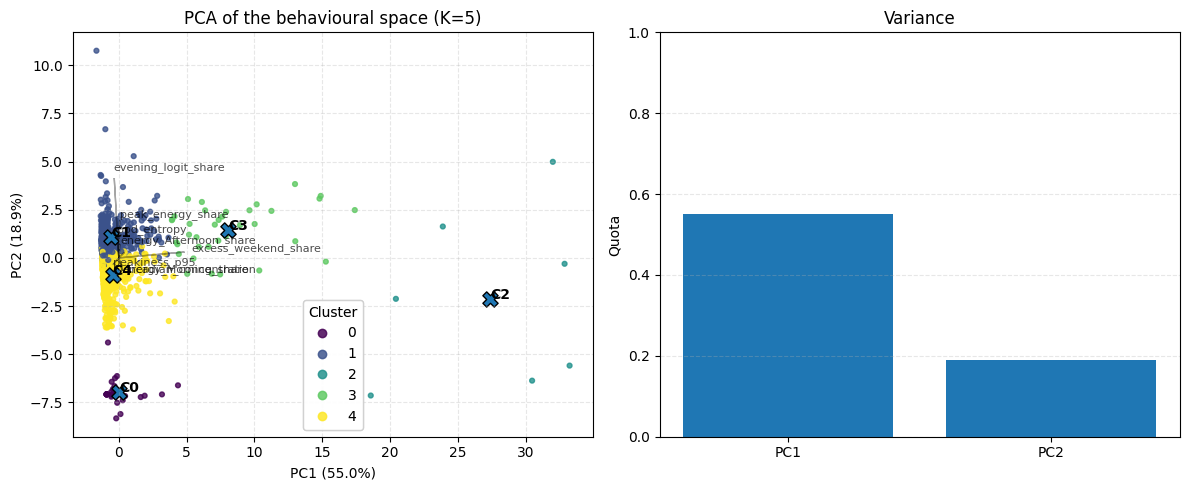

In [9]:
ARTIFACTS_DIR = "artifacts/clustering_behavior_K5"  # usa la cartella di artefatti desiderata (es. "..._K5")

# 1) Same clustering space
idx, Z_keep, Zs = transform_for_clustering(df_switch_transformed, artifacts_dir=ARTIFACTS_DIR, id_col="ca_number")

# 2) Load the saved KMeans and obtain labels (confirm K used)
km = joblib.load(f"{ARTIFACTS_DIR}/kmeans.joblib")
labels = km.predict(Zs)
K_used = km.n_clusters

# 3) PCA
pca = PCA(n_components=2, random_state=42)
P = pca.fit_transform(Zs)  # (n_samples, 2)

# 4) Coloured PCA scatter plot by cluster
fig, ax = plt.subplots(1, 2, figsize=(12,5))

sc = ax[0].scatter(P[:,0], P[:,1], c=labels, s=12, alpha=0.8)
ax[0].set_title(f"PCA of the behavioural space (K={K_used})")
ax[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
legend1 = ax[0].legend(*sc.legend_elements(), title="Cluster", loc="best")
ax[0].add_artist(legend1)
ax[0].grid(True, linestyle='--', alpha=0.3)

# 5) Biplot of loadings (directions of features in PC1-PC2 space)
#    To avoid huge arrows, I use scaling based on the standard deviation of the components.
loadings = pca.components_.T   # shape: (n_features, 2)
names = Z_keep.columns.tolist()

# scale to make the arrows visible in the cloud (tweak if necessary)
scale = 2.0 * np.sqrt(pca.explained_variance_)[:2].mean()
for i, name in enumerate(names):
    ax[0].arrow(0, 0, loadings[i,0]*scale, loadings[i,1]*scale,
                head_width=0.02, head_length=0.04, length_includes_head=True, alpha=0.35)
    # label only the 8 "strongest" features (loading norm)
#    or remove the filter to show them all
loading_strength = np.linalg.norm(loadings, axis=1)
top = np.argsort(loading_strength)[-8:]
for i in top:
    ax[0].text(loadings[i,0]*scale*1.10, loadings[i,1]*scale*1.10, names[i], fontsize=8, alpha=0.7)

# 6) Centroidi in PCA space (useful for readability)
centers_pca = pca.transform(km.cluster_centers_)
ax[0].scatter(centers_pca[:,0], centers_pca[:,1], marker='X', s=120, edgecolor='k')
for j in range(K_used):
    ax[0].text(centers_pca[j,0], centers_pca[j,1], f"C{j}", fontsize=10, weight='bold')

# 7) Explained variance (barplot) — right panel
ax[1].bar([1,2], pca.explained_variance_ratio_[:2])
ax[1].set_xticks([1,2]); ax[1].set_xticklabels(["PC1","PC2"])
ax[1].set_ylim(0, 1)
ax[1].set_title("Variance")
ax[1].set_ylabel("Quota")
ax[1].grid(True, axis='y', linestyle='--', alpha=0.3)

fig.tight_layout()

/rds/general/user/mg2324/home/HPC_test/IRPenv/lib64/python3.11/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/rds/general/user/mg2324/home/HPC_test/IRPenv/lib64/python3.11/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


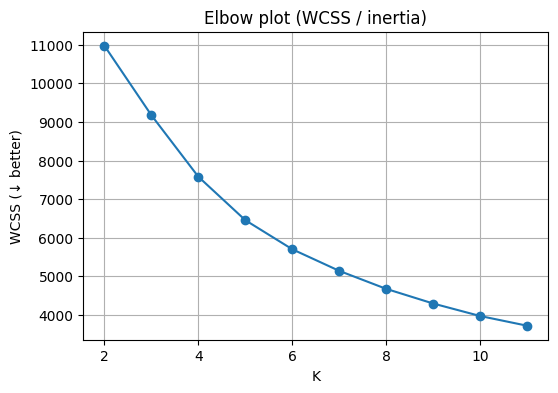

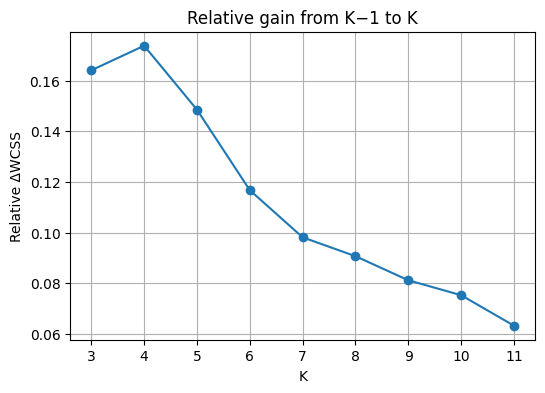

In [10]:
# === ELBOW PLOT (WCSS/inertia) ===
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import joblib
from pathlib import Path

# 1) Obtain the already scaled space (Zs) with the same artefacts as the fit.
#    Use the function you already have in the pipeline
#from clustering_behavior import transform_for_clustering  # <-- adatta l'import se il file ha un nome diverso

ARTIFACTS_DIR = "artifacts/clustering_behavior"  # cambia se usi un outdir diverso
idx, Z_keep, Zs = transform_for_clustering(df_switch_transformed, artifacts_dir=ARTIFACTS_DIR, id_col="ca_number")

# 2) Calculate WCSS/inertia for a grid of K
K_range = range(2, 12)
inertias = []
for K in K_range:
    km = KMeans(n_clusters=K, n_init=50, random_state=42).fit(Zs)
    inertias.append(km.inertia_)

# 3) Plot "Elbow"
plt.figure(figsize=(6,4))
plt.plot(list(K_range), inertias, marker='o')
plt.title('Elbow plot (WCSS / inertia)')
plt.xlabel('K'); plt.ylabel('WCSS (↓ better)')
plt.grid(True)

# 4) Relative variation to highlight the "elbow"
rel_gain = -np.diff(inertias) / np.array(inertias[:-1])
plt.figure(figsize=(6,4))
plt.plot(list(K_range)[1:], rel_gain, marker='o')
plt.title('Relative gain from K−1 to K')
plt.xlabel('K'); plt.ylabel('Relative ΔWCSS')
plt.grid(True)


In [8]:

# -----------------------------
# A) Event flags (semantica POWBAL)
# -----------------------------
def add_event_flags_powbal(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggiunge:
      - scheduled_event: evento postato all'API (fonte di verità)
      - actual_event   : evento con device 'vivo' prima dello slot (si spegne davvero)
      - override       : actual_event==1 & reward==0 (def supervisor)
      - has_event      : alias di scheduled_event (per tassi/quote)
      - notice_2h/8h   : solo sugli slot evento
      - reward_rate_event: reward_rate valido solo su slot evento

    Regole chiave (note dati):
      - Ignorare 'start_event'.
      - Se mancano switch_off_event/post_to_api, fallback prudente: reward_rate>0 o notice_time∈{2,8}.
      - notice_time==0 & reward_rate==0 => no event.
    """
    d = df.copy()

    # scheduled_event (gold standard, con fallback)
    if {"switch_off_event", "posted_to_api"}.issubset(d.columns):
        d["scheduled_event"] = (
            d["switch_off_event"].eq(1) & d["posted_to_api"].eq(1)
        ).astype(np.int8)
    else:
        rr = d.get("reward_rate", 0)
        nt = d.get("notice_time", 0)
        rr = rr.fillna(0) if hasattr(rr, "fillna") else rr
        nt = nt.fillna(0) if hasattr(nt, "fillna") else nt
        d["scheduled_event"] = ((rr > 0) | (pd.Series(nt, index=d.index).isin([2, 8]))).astype(np.int8)

    # actual_event (device stava assorbendo e viene spento allo slot)
    if "actual_event" in d.columns:
        # tieni quello presente, ma se manca pre_switch_off_reading calcolabile, armonizza
        pass
    if "pre_switch_off_reading" in d.columns:
        d["actual_event"] = np.where(
            d["scheduled_event"].eq(1)
            & d["pre_switch_off_reading"].notna()
            & (d["pre_switch_off_reading"] != 0),
            1, 0
        ).astype(np.int8)
    else:
        d["actual_event"] = d.get("actual_event", 0)

    # override (def supervisor): actual_event==1 & reward==0
    if "reward" not in d.columns:
        d["reward"] = 0.0
    d["override"] = np.where(
        d["actual_event"].eq(1) & pd.Series(d["reward"]).fillna(0).eq(0),
        1, 0
    ).astype(np.int8)

    # alias per chiarezza
    d["has_event"] = d["scheduled_event"].astype(np.int8)

    # notice flags solo su slot evento
    d["notice_2h"] = 0
    d["notice_8h"] = 0
    if "notice_time" in d.columns:
        ev = d["has_event"].eq(1)
        d.loc[ev & d["notice_time"].eq(2), "notice_2h"] = 1
        d.loc[ev & d["notice_time"].eq(8), "notice_8h"] = 1

    # reward_rate valido solo su slot evento
    if "reward_rate" in d.columns:
        d["reward_rate_event"] = np.where(
            d["has_event"].eq(1) & pd.Series(d["reward_rate"]).fillna(0).gt(0),
            d["reward_rate"], np.nan
        )
    else:
        d["reward_rate_event"] = np.nan

    return d


# -----------------------------
# B) Overlay per utente (profilazione post-fit)
# -----------------------------
def build_powbal_overlay(df_long: pd.DataFrame,
                         id_col: str = "ca_number",
                         keep_nan_for_conditionals: bool = True) -> pd.DataFrame:
    """
    Costruisce metriche per utente (NON usate nel fit del clustering/AE).

    Semantica:
      - tassi su tutti gli slot -> 0 se assenti
      - metriche condizionate all'evento -> NaN se l'utente non ha eventi (opz. fill)
    """
    d = add_event_flags_powbal(df_long)

    g   = d.groupby(id_col, observed=True)
    idx = g.size().index

    # Quotes on ALL slots (0 if never observed)
    event_slot_rate  = g["has_event"].mean().reindex(idx).fillna(0.0)
    actual_rate_slot = g["actual_event"].mean().reindex(idx).fillna(0.0)
    override_rate    = g["override"].mean().reindex(idx).fillna(0.0)

    # Conditioned to the event (NaN when event_slot_rate==0)
    eps = 1e-12
    actual_given_event   = (actual_rate_slot  / (event_slot_rate + eps)).where(event_slot_rate > 0)
    override_given_event = (override_rate     / (event_slot_rate + eps)).where(event_slot_rate > 0)

    reward_rate_mean_event = d.loc[d["has_event"].eq(1)].groupby(id_col)["reward_rate_event"] \
                               .mean().reindex(idx)
    reward_mean_event      = d.loc[d["has_event"].eq(1)].groupby(id_col)["reward"] \
                               .mean().reindex(idx)

    notice_2h_share = d.loc[d["has_event"].eq(1)].groupby(id_col)["notice_2h"].mean().reindex(idx)
    notice_8h_share = d.loc[d["has_event"].eq(1)].groupby(id_col)["notice_8h"].mean().reindex(idx)

    # Counts
    events_count  = g["has_event"].sum().reindex(idx).fillna(0).astype(int)
    actual_count  = g["actual_event"].sum().reindex(idx).fillna(0).astype(int)
    override_cnt  = g["override"].sum().reindex(idx).fillna(0).astype(int)

    # Total reward (useful for narrative)
    reward_total  = g["reward"].sum().reindex(idx).fillna(0.0)

    out = pd.DataFrame({
        "event_slot_rate":        event_slot_rate,
        "actual_rate_slot":       actual_rate_slot,
        "override_rate":          override_rate,
        "actual_given_event":     actual_given_event,
        "override_given_event":   override_given_event,
        "reward_rate_mean_event": reward_rate_mean_event,
        "reward_mean_event":      reward_mean_event,
        "reward_total":           reward_total,
        "notice_2h_share":        notice_2h_share,
        "notice_8h_share":        notice_8h_share,
        "events_count":           events_count,
        "actual_count":           actual_count,
        "override_count":         override_cnt,
    })

    # Meta opzionali
    if "city" in d.columns:
        out["city"] = g["city"].agg(lambda s: s.mode().iloc[0] if not s.mode().empty else None).reindex(idx)
    if "appliance" in d.columns:
        out["appliance"] = g["appliance"].agg(lambda s: s.mode().iloc[0] if not s.mode().empty else None).reindex(idx)
    if "preference" in d.columns:
        out["preference"] = g["preference"].agg(lambda s: s.mode().iloc[0] if not s.mode().empty else None).reindex(idx)

    if not keep_nan_for_conditionals:
        cond_cols = ["actual_given_event","override_given_event",
                     "reward_rate_mean_event","reward_mean_event",
                     "notice_2h_share","notice_8h_share"]
        out[cond_cols] = out[cond_cols].fillna(0.0)

    return out


# ---------------------------
# Season 
# ---------------------------
SEASON_ORDER = ["Winter", "Pre-monsoon", "Monsoon", "Post-monsoon"]

def ensure_season(df: pd.DataFrame,
                  date_hint: Optional[str] = None) -> pd.Series:
    """
    Return a season Series. If 'season' already exists it is returned as-is.
    Otherwise it is derived from a datetime-like column.

    Season mapping (India-friendly 4 blocks):
      - Winter:        Dec–Feb
      - Pre-monsoon:   Mar–May
      - Monsoon:       Jun–Aug
      - Post-monsoon:  Sep–Nov

    Parameters
    ----------
    df : pd.DataFrame
        Long table with either a 'season' column or a datetime-like column.
    date_hint : Optional[str]
        Name of a datetime-like column to use if present. If None, the
        function tries in this order: 'parsed_datetime', 'round_datetime', 'date'.

    Returns
    -------
    pd.Series
        Season labels aligned to df.index.
    """
    if "season" in df.columns:
        return df["season"]

    # pick a datetime-like column
    candidates = [date_hint] if date_hint else ["parsed_datetime", "round_datetime", "date"]
    col = next((c for c in candidates if c in df.columns), None)
    if col is None:
        raise ValueError("No 'season' and no datetime-like column found among "
                         "['parsed_datetime', 'round_datetime', 'date'].")

    dt = pd.to_datetime(df[col], errors="coerce")
    if dt.isna().all():
        raise ValueError(f"Column '{col}' cannot be parsed as datetime.")

    m = dt.dt.month

    def month_to_season(mm: int) -> str:
        if mm in (12, 1, 2):  return "Winter"
        if mm in (3, 4, 5):   return "Pre-monsoon"
        if mm in (6, 7, 8):   return "Monsoon"
        return "Post-monsoon"

    return m.map(month_to_season)



# -----------------------------
# C) Profilazione per-cluster (riassunto + distribuzioni)
# -----------------------------
# def profile_clusters_powbal(df_long: pd.DataFrame,
#                             labels: pd.Series,
#                             top_cities: int = 5,
#                             top_appliances: int = 5) -> dict:
#     X_prog = build_powbal_overlay(df_long)
#     per_user = X_prog.join(labels.rename("cluster"), how="left")
#     assert per_user["cluster"].notna().all(), "Alcuni ca_number non hanno cluster."

#     metrics = [
#         "event_slot_rate","actual_rate_slot","override_rate",
#         "actual_given_event","override_given_event",
#         "reward_rate_mean_event","reward_mean_event","reward_total",
#         "notice_2h_share","notice_8h_share",
#         "events_count","actual_count","override_count"
#     ]
#     grp = per_user.groupby("cluster", observed=True)
#     summary = pd.concat([
#         grp.size().rename("n_users"),
#         grp.apply(lambda g: (g["event_slot_rate"] > 0).mean()).rename("share_partecipanti"),
#         grp[metrics].median().add_prefix("med_"),
#         grp[metrics].quantile(0.25).add_prefix("p25_"),
#         grp[metrics].quantile(0.75).add_prefix("p75_"),
#     ], axis=1).sort_index()

    # # Distribuzioni opzionali
    # city_top = pd.DataFrame(columns=["cluster","city","city_share"])
    # if "city" in per_user.columns:
    #     c = per_user.groupby(["cluster","city"], observed=True).size()
    #     city_top = (c / c.groupby(level=0).sum()).rename("city_share") \
    #                .groupby(level=0).nlargest(top_cities) \
    #                .reset_index(level=0, drop=True).reset_index()

    # appl_top = pd.DataFrame(columns=["cluster","appliance","appliance_share"])
    # if "appliance" in per_user.columns:
    #     a = per_user.groupby(["cluster","appliance"], observed=True).size()
    #     appl_top = (a / a.groupby(level=0).sum()).rename("appliance_share") \
    #                .groupby(level=0).nlargest(top_appliances) \
    #                .reset_index(level=0, drop=True).reset_index()

    # pref_share = pd.DataFrame(columns=["cluster","preference","preference_share"])
    # if "preference" in per_user.columns:
    #     p = per_user.groupby(["cluster","preference"], observed=True).size()
    #     pref_share = (p / p.groupby(level=0).sum()).rename("preference_share") \
    #                  .reset_index()

    # return {
    #     "per_user": per_user,
    #     "cluster_summary": summary,
    #     "city_top": city_top,
    #     "appliance_top": appl_top,
    #     "preference_share": pref_share
    # }

def profile_clusters_powbal(df_long: pd.DataFrame,
                            labels: pd.Series,
                            top_cities: int = 5,
                            top_appliances: int = 5) -> dict:
    """
    Build post-fit profiling tables (event overlay + meta distributions) by cluster.

    Notes
    -----
    - Event semantics follow the trial corrections (scheduled_event =
      switch_off_event & posted_to_api; notice_time==0 & reward_rate==0 => no event;
      override == 1 when actual_event == 1 & reward == 0). Keep the computation
      consistent with your 'build_powbal_overlay' implementation.  # per trial docs
    """
    # ---- per-user event overlay (already aligned with trial semantics)
    X_prog = build_powbal_overlay(df_long)
    labs   = labels.rename("cluster")

    per_user = X_prog.join(labs, how="left")
    assert per_user["cluster"].notna().all(), "Some ca_number lack a cluster label."

    # robust summary metrics
    metrics = [
        "event_slot_rate","actual_rate_slot","override_rate",
        "actual_given_event","override_given_event",
        "reward_rate_mean_event","reward_mean_event","reward_total",
        "notice_2h_share","notice_8h_share","events_count","actual_count","override_count",
    ]
    grp = per_user.groupby("cluster", observed=True)
    summary = pd.concat([
        grp.size().rename("n_users"),
        grp.apply(lambda g: (g["event_slot_rate"]>0).mean()).rename("share_partecipanti"),
        grp[metrics].median().add_prefix("med_"),
        grp[metrics].quantile(0.25).add_prefix("p25_"),
        grp[metrics].quantile(0.75).add_prefix("p75_"),
    ], axis=1).sort_index()

    # ---- City top-N (optional)
    city_top = pd.DataFrame(columns=["cluster","city","city_share"])
    if "city" in df_long.columns:
        tmp = per_user[["cluster"]].join(df_long[["ca_number","city"]].drop_duplicates("ca_number")
                                         .set_index("ca_number"), how="left")
        c = tmp.groupby(["cluster","city"], observed=True).size()
        cshare = (c / c.groupby(level=0).sum()).rename("city_share")
        city_top = cshare.groupby(level=0).nlargest(top_cities) \
                        .reset_index(level=0, drop=True).reset_index()

    # ---- Appliance top-N (optional)
    appl_top = pd.DataFrame(columns=["cluster","appliance","appliance_share"])
    if "appliance" in df_long.columns:
        tmp = per_user[["cluster"]].join(df_long[["ca_number","appliance"]].drop_duplicates("ca_number")
                                         .set_index("ca_number"), how="left")
        a = tmp.groupby(["cluster","appliance"], observed=True).size()
        ashare = (a / a.groupby(level=0).sum()).rename("appliance_share")
        appl_top = ashare.groupby(level=0).nlargest(top_appliances) \
                        .reset_index(level=0, drop=True).reset_index()

    # ---- Season distribution (slot-level; robust to missing 'season')
    d_season = df_long.copy()
    d_season["season"] = ensure_season(d_season)
    d_season = d_season.merge(labs, left_on="ca_number", right_index=True, how="left")
    scounts = d_season.groupby(["cluster","season"], observed=True).size()
    season_share = (scounts / scounts.groupby(level=0).sum()).rename("season_share") \
                        .reset_index()

    return {
        "per_user": per_user,
        "cluster_summary": summary,
        "city_top": city_top,
        "appliance_top": appl_top,
        "season_share": season_share
    }





# -----------------------------
# D) Salvataggi comodi per il report / dashboard
# -----------------------------
# def save_profilazione_outputs(prof: dict, outdir: str, tag: str):
#     out = Path(outdir); out.mkdir(parents=True, exist_ok=True)
#     prof["per_user"].to_csv(out/f"per_user_{tag}.csv")
#     prof["cluster_summary"].to_csv(out/f"cluster_summary_{tag}.csv")
#     if "city_top" in prof and not prof["city_top"].empty:
#         prof["city_top"].to_csv(out/f"city_top_{tag}.csv", index=False)
#     if "appliance_top" in prof and not prof["appliance_top"].empty:
#         prof["appliance_top"].to_csv(out/f"appliance_top_{tag}.csv", index=False)
#     if "preference_share" in prof and not prof["preference_share"].empty:
#         prof["preference_share"].to_csv(out/f"preference_share_{tag}.csv", index=False)

def save_profilazione_outputs(prof: dict, outdir: str, tag: str) -> None:
    """
    Save profiling artifacts to CSV for reporting/dashboarding.
    """
    out = Path(outdir)
    out.mkdir(parents=True, exist_ok=True)
    prof["per_user"].to_csv(out / f"per_user_{tag}.csv")
    prof["cluster_summary"].to_csv(out / f"cluster_summary_{tag}.csv")
    if "city_top" in prof and not prof["city_top"].empty:
        prof["city_top"].to_csv(out / f"city_top_{tag}.csv", index=False)
    if "appliance_top" in prof and not prof["appliance_top"].empty:
        prof["appliance_top"].to_csv(out / f"appliance_top_{tag}.csv", index=False)
    if "season_share" in prof and not prof["season_share"].empty:
        prof["season_share"].to_csv(out / f"season_share_{tag}.csv", index=False)



In [9]:
# Esempio: profila K=5 e salva tabelle, servira' anche nell'autoencoder
prof_K5 = profile_clusters_powbal(df_switch_transformed, labels_K5)
save_profilazione_outputs(prof_K5, outdir="artifacts/profilazione", tag="K5")


/var/tmp/pbs.902063.pbs-7/ipykernel_357859/2630681888.py:298: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grp.apply(lambda g: (g["event_slot_rate"]>0).mean()).rename("share_partecipanti"),


In [12]:
tmp = add_event_flags_powbal(df_switch_transformed)
# override non fuori da slot evento
assert not ((tmp["override"]==1) & (tmp["scheduled_event"]==0)).any()
# condizionati NaN se nessun evento
ov = build_powbal_overlay(df_switch_transformed)
assert ov.loc[ov["event_slot_rate"]==0, "override_given_event"].isna().all()


In [9]:
display(prof_K5["cluster_summary"].round(3).head())

,n_users,share_partecipanti,med_event_slot_rate,med_actual_rate_slot,med_override_rate,med_actual_given_event,med_override_given_event,med_reward_rate_mean_event,med_reward_mean_event,med_reward_total,...,p75_actual_given_event,p75_override_given_event,p75_reward_rate_mean_event,p75_reward_mean_event,p75_reward_total,p75_notice_2h_share,p75_notice_8h_share,p75_events_count,p75_actual_count,p75_override_count
cluster,,,,,,,,,,,,,,,,,,,,,
0,27,0.407,0.000,0.000,0.000,0.000,0.000,18.000,0.000,0.000,...,0.024,0.000,18.545,0.003,0.000,0.464,0.184,16.00,0.00,0.00
1,495,0.909,0.036,0.006,0.001,0.223,0.030,17.863,0.373,66.320,...,0.419,0.094,18.385,0.910,227.800,0.383,0.180,424.50,85.00,19.00
2,7,0.429,0.000,0.000,0.000,0.000,0.000,17.324,0.000,0.000,...,0.001,0.000,19.912,0.000,0.000,0.352,0.228,42.00,0.00,0.00
3,36,0.944,0.038,0.001,0.000,0.020,0.002,17.724,0.073,8.375,...,0.065,0.027,18.518,0.176,36.195,0.371,0.185,353.75,9.25,4.25
4,427,0.920,0.037,0.003,0.000,0.109,0.016,17.938,0.327,62.870,...,0.253,0.081,18.382,0.751,164.280,0.378,0.181,447.50,54.50,15.00


In [10]:
# --- util: crea directory figure
FIGDIR = Path("artifacts/profilazione/figs")
FIGDIR.mkdir(parents=True, exist_ok=True)

# --- A) Behaviour summary per cluster (unità originali)
def summarize_behavior_by_cluster(df_long: pd.DataFrame,
                                  labels: pd.Series) -> pd.DataFrame:
    """Medians and p25/p75 of the most important behaviour features."""
    # elenco "canonico" (usa ciò che è disponibile)
    wanted = [
        "morning_share","afternoon_share","evening_share","night_share",
        "pod_entropy","excess_weekend_share","peak_energy_share",
        "circadian_concentration","day_to_day_cv","peakiness_p95",
        "evening_logit_share"  # se presente
    ]
    cols = [c for c in wanted if c in df_long.columns]
    # prendi valori univoci per utente (le feature sono allineate per utente)
    X_u = df_long.groupby("ca_number")[cols].first()
    X_u = X_u.join(labels.rename("cluster"), how="left")
    grp = X_u.groupby("cluster", observed=True)

    med = grp[cols].median().add_prefix("med_")
    p25 = grp[cols].quantile(0.25).add_prefix("p25_")
    p75 = grp[cols].quantile(0.75).add_prefix("p75_")
    n   = grp.size().rename("n_users")

    out = pd.concat([n, med, p25, p75], axis=1).sort_index()
    return out

# --- B) Barplot overlay (medians) for key metrics
def plot_overlay_bars(per_user: pd.DataFrame,
                      metrics = ("actual_given_event",
                                 "override_given_event",
                                 "reward_rate_mean_event",
                                 "notice_2h_share",
                                 "notice_8h_share")) -> plt.Figure:
    m = [c for c in metrics if c in per_user.columns]
    grp = per_user.groupby("cluster", observed=True)
    M = grp[m].median().sort_index()
    fig, ax = plt.subplots(figsize=(8,4))
    M.plot(kind="bar", ax=ax)
    ax.set_ylabel("Median (original units)")
    ax.set_title("Event profiling — cluster medians")
    ax.legend(loc="best", ncol=2, fontsize=9)
    fig.tight_layout()
    return fig

# --- C) Top-N city/appliance
def plot_top_shares(df_top: pd.DataFrame, what: str, N: int = 5) -> plt.Figure:
    """df_top = city_top o appliance_top: colonne ['cluster', what, f'{what}_share']"""
    share_col = f"{what}_share"
    if df_top.empty: return None
    # plot a pannelli: un pannello per cluster
    clusters = df_top["cluster"].unique()
    nC = len(clusters)
    fig, axes = plt.subplots(1, nC, figsize=(4*nC, 3), sharey=True)
    if nC == 1: axes = [axes]
    for ax, c in zip(axes, clusters):
        T = df_top[df_top["cluster"]==c].nlargest(N, share_col)
        ax.barh(T[what], T[share_col])
        ax.set_title(f"Cluster {c}")
        ax.invert_yaxis()
        ax.set_xlabel("Quota")
    fig.suptitle(f"Top-{N} {what} per cluster")
    fig.tight_layout()
    return fig


def plot_season_share_bars(season_share: pd.DataFrame,
                           outdir: str,
                           tag: str,
                           order: Optional[List[str]] = None) -> Path:
    """
    Plot stacked bar chart of season distribution by cluster.

    Parameters
    ----------
    season_share : pd.DataFrame
        Columns: ['cluster','season','season_share'].
    outdir : str
        Directory to save the figure.
    tag : str
        Suffix for file name (e.g., 'K5').
    order : Optional[List[str]]
        Season order for plotting. Defaults to SEASON_ORDER.

    Returns
    -------
    Path
        Path to the saved PNG file.
    """
    order = order or SEASON_ORDER
    pvt = (season_share.pivot(index="cluster", columns="season", values="season_share")
           .reindex(columns=order).fillna(0.0))
    fig, ax = plt.subplots(figsize=(8, 4.2), dpi=150)
    bottom = np.zeros(len(pvt))
    x = np.arange(len(pvt.index))
    for s in pvt.columns:
        vals = pvt[s].values
        ax.bar(x, vals, bottom=bottom, label=s)
        bottom += vals
    ax.set_xticks(x)
    ax.set_xticklabels(pvt.index)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Share")
    ax.set_xlabel("cluster")
    ax.set_title("Season distribution by cluster (slot-level)")
    ax.legend(loc="upper right", ncol=2, frameon=False)
    outdir = Path(outdir); outdir.mkdir(parents=True, exist_ok=True)
    path = outdir / f"season_share_{tag}.png"
    fig.tight_layout(); fig.savefig(path, bbox_inches="tight")
    plt.close(fig)
    return path




# # --- D) Radar (facoltativo) sulle behaviour (Δ rispetto alla mediana globale)
# def plot_behavior_radar(df_long: pd.DataFrame, labels: pd.Series) -> plt.Figure:
#     wanted = ["morning_share","afternoon_share","evening_share",
#               "pod_entropy","excess_weekend_share","circadian_concentration",
#               "day_to_day_cv","peakiness_p95"]
#     cols = [c for c in wanted if c in df_long.columns]
#     X_u = df_long.groupby("ca_number")[cols].first().join(labels.rename("cluster"))
#     global_med = X_u[cols].median()
#     Z = X_u[cols] - global_med  # Δ-mediana
#     grp = Z.join(X_u["cluster"]).groupby("cluster", observed=True)[cols].median()

#     categories = list(grp.columns)
#     K = grp.shape[0]
#     angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
#     angles += angles[:1]  # chiusura

#     fig = plt.figure(figsize=(5+K, 4))
#     ax = plt.subplot(111, polar=True)
#     for cl, row in grp.iterrows():
#         vals = row.tolist(); vals += vals[:1]
#         ax.plot(angles, vals, linewidth=2, label=f"Cluster {cl}")
#         ax.fill(angles, vals, alpha=0.1)
#     ax.set_thetagrids(np.degrees(angles[:-1]), categories)
#     ax.set_title("Behaviour radar – Δ dalla mediana globale")
#     ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
#     fig.tight_layout()
#     return fig


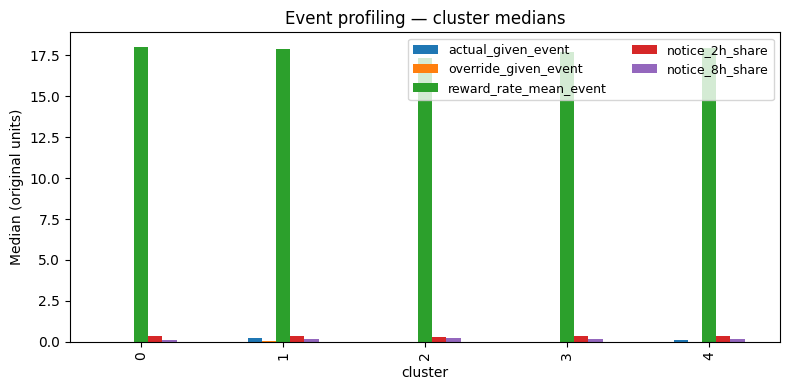

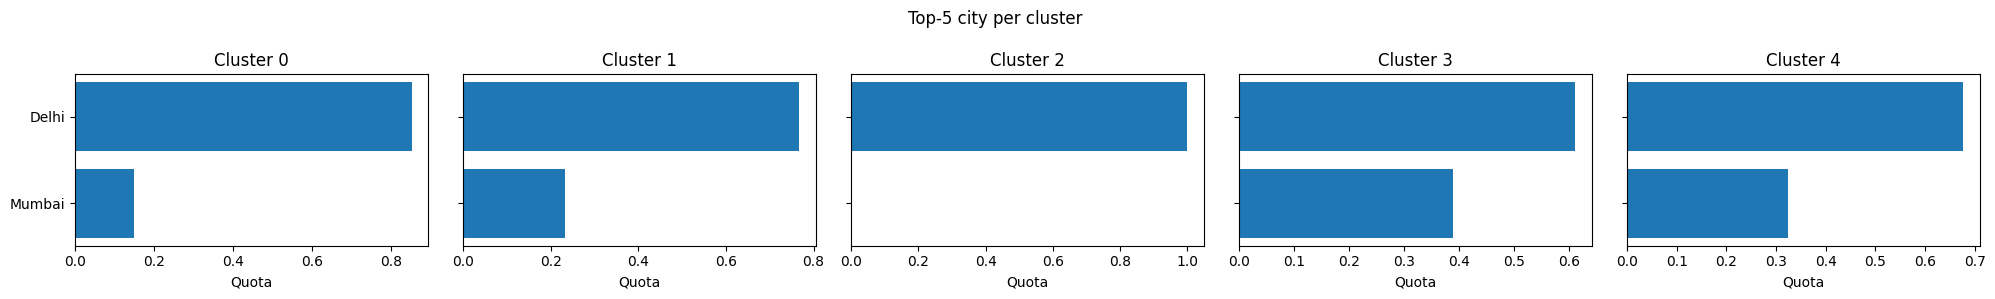

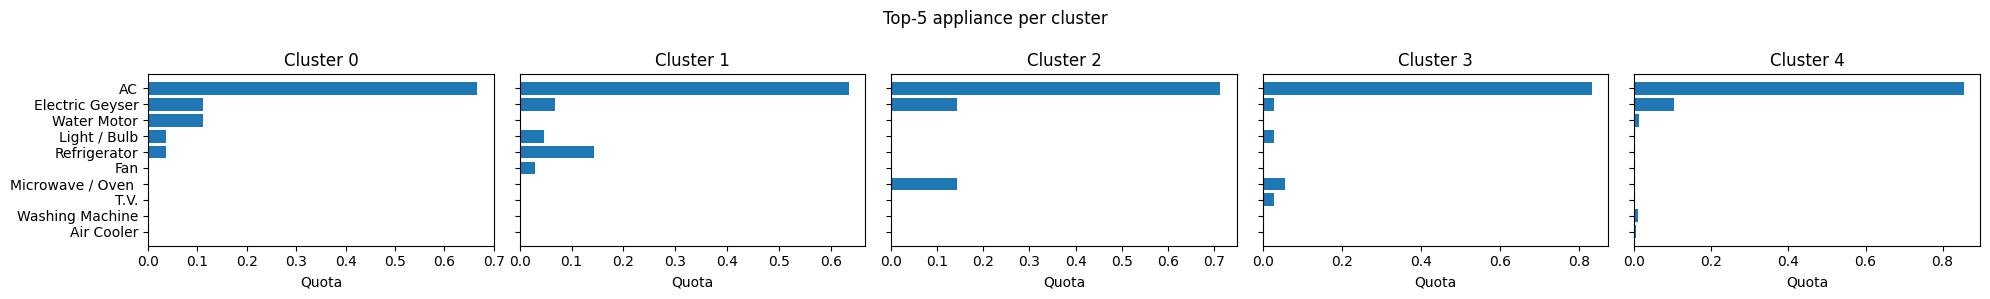

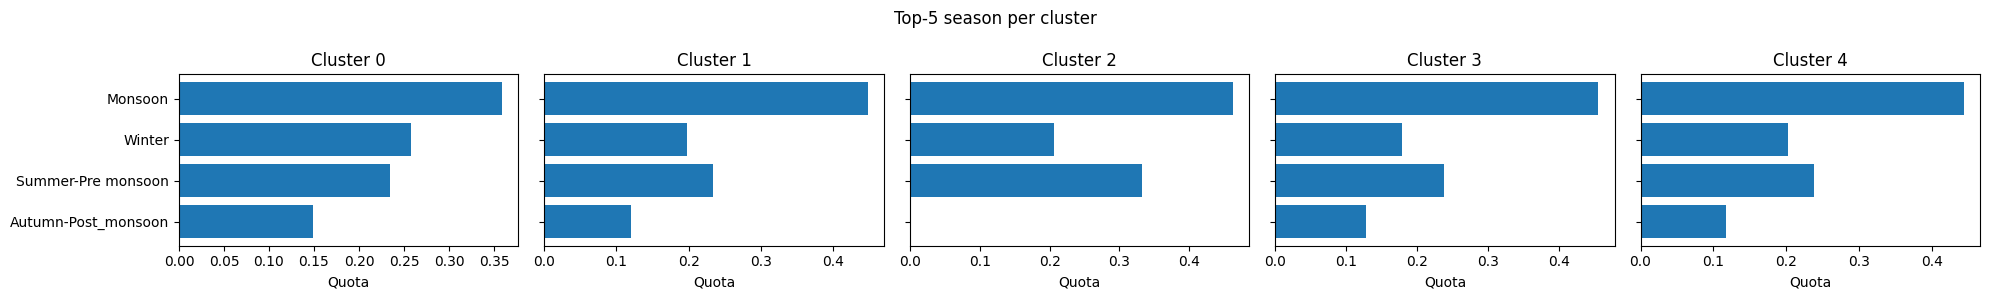

In [11]:
# ====== ESECUZIONE: crea e salva le figure per K=5 ======
beh_summary = summarize_behavior_by_cluster(df_switch_transformed, labels_K5)
beh_summary.to_csv(FIGDIR.parent / "behavior_summary_K5.csv")

# per_user dall'overlay già calcolato:
per_user = prof_K5["per_user"]

fig1 = plot_overlay_bars(per_user)
fig1.savefig(FIGDIR/"overlay_bars_K5.png", dpi=150, bbox_inches="tight")

fig2 = plot_top_shares(prof_K5["city_top"], "city", N=5)
if fig2:
    fig2.savefig(FIGDIR/"city_top_K5.png", dpi=150, bbox_inches="tight")

fig3 = plot_top_shares(prof_K5["appliance_top"], "appliance", N=5)
if fig3:
    fig3.savefig(FIGDIR/"appliance_top_K5.png", dpi=150, bbox_inches="tight")

# Season (slot-level) – stesso stile di city/appliance
fig4 = plot_top_shares(prof_K5["season_share"], "season", N=5)
fig4.savefig(FIGDIR / "season_top_K5.png", dpi=150, bbox_inches="tight")

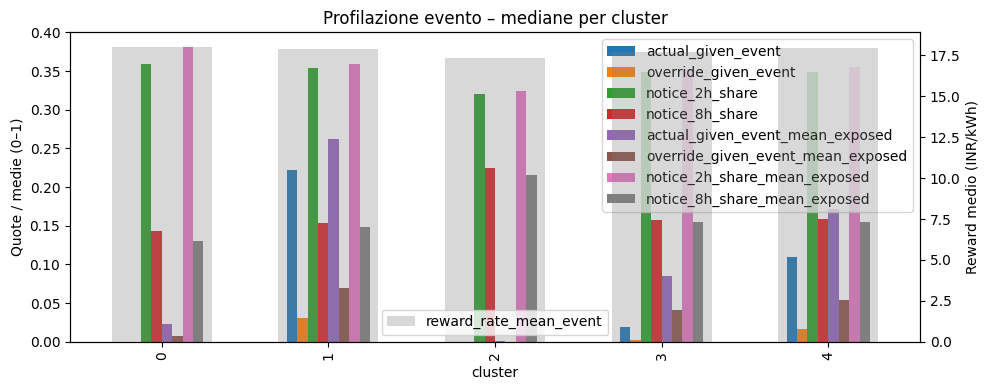

In [18]:
def overlay_by_cluster(per_user: pd.DataFrame):
    # metriche principali
    metrics = ["actual_given_event","override_given_event",
               "reward_rate_mean_event","notice_2h_share","notice_8h_share"]
    m_exist = [m for m in metrics if m in per_user.columns]
    g = per_user.groupby("cluster", observed=True)

    # mediane per cluster
    M_med = g[m_exist].median().sort_index()

    # medie condizionate tra utenti esposti (event_slot_rate>0)
    exposed = per_user["event_slot_rate"] > 0
    cond_metrics = [m for m in ["actual_given_event","override_given_event",
                                "notice_2h_share","notice_8h_share"]
                    if m in per_user.columns]
    M_cond = per_user.loc[exposed].groupby("cluster", observed=True)[cond_metrics] \
                     .mean().add_suffix("_mean_exposed").sort_index()

    return M_med.join(M_cond, how="left")

def plot_overlay_bars_separate(M: pd.DataFrame) -> None:
    import matplotlib.pyplot as plt
    reward_col = [c for c in M.columns if "reward_rate_mean_event" in c]
    other = [c for c in M.columns if c not in reward_col]
    fig, ax = plt.subplots(figsize=(10,4))
    M[other].plot(kind="bar", ax=ax)
    ax.set_ylabel("Share / mean (0–1)")
    ax.set_title("Event profiling — cluster medians")
    # Reward su asse secondario (se presente)
    if reward_col:
        ax2 = ax.twinx()
        M[reward_col].plot(kind="bar", ax=ax2, alpha=0.3, width=0.6, color="gray")
        ax2.set_ylabel("Mean reward rate (INR/kWh)")
    fig.tight_layout()
    plt.show()

# USO (riutilizza prof_K5 già calcolato)
M = overlay_by_cluster(prof_K5["per_user"])
plot_overlay_bars_separate(M)
M.round(3).to_csv("artifacts/profilazione/overlay_cluster_K5.csv")


In [21]:

def plot_behavior_radar_robust(
    df_long: pd.DataFrame,
    labels: pd.Series,
    features: list[str] | None = None,
    q_low: float = 0.10,
    q_high: float = 0.90,
    agg: str = "median",
) -> plt.Figure:
    """
    Plot a robust 'behavior radar' for K-means clusters.

    This function is defensive:
    - If required behavior features are missing in `df_long`, it calls
      `add_behavior_features(df_long)` to build them.
    - It tolerates both naming schemes for part-of-day shares
      (e.g. 'energy_Morning_share' or 'morning_share') and normalizes names.
    - If 'evening_logit_share' is not present, it is created from 'evening_share'.

    Parameters
    ----------
    df_long : pd.DataFrame
        Long table with at least 'ca_number' and energy/time columns.
        If behavior features are missing, they will be created.
    labels : pd.Series
        Cluster labels indexed by 'ca_number'.
    features : list[str] | None
        Optional explicit list of features to plot. If None, a default set is used.
    q_low, q_high : float
        Lower/upper quantiles used for robust min-max scaling (10–90% by default).
    agg : {"median", "mean"}
        Aggregation across users within each cluster.

    Returns
    -------
    matplotlib.figure.Figure
        The radar figure.
    """
    df_long = df_long.copy()
    df_long = df_long.loc[:, ~df_long.columns.duplicated()].copy()  # drop duplicate names

    # --- 0) Ensure behavior features exist -----------------------------------
    needed_base = {
        "morning_share", "afternoon_share", "evening_share",
        "pod_entropy", "excess_weekend_share", "peak_energy_share",
        "circadian_concentration", "day_to_day_cv", "peakiness_p95"
    }
    have = set(df_long.columns)
    if not needed_base.issubset(have):
        # Build behavior features once; assumes `add_behavior_features` is defined in the notebook
        df_long = add_behavior_features(df_long, id_col="ca_number")
        have = set(df_long.columns)

    # --- 1) Normalize PoD naming if the dataset uses energy_*_share ----------
    rename_map = {
        "energy_Morning_share": "morning_share",
        "energy_Afternoon_share": "afternoon_share",
        "energy_Evening_share": "evening_share",
        # keep 'night_share' if present, but it is not used in the radar default list
    }
    present_renames = {k: v for k, v in rename_map.items() if k in df_long.columns}
    if present_renames:
        df_long = df_long.rename(columns=present_renames)
        have = set(df_long.columns)

    # --- 2) Evening logit (if missing) ---------------------------------------
    if "evening_logit_share" not in df_long.columns and "evening_share" in df_long.columns:
        p = df_long["evening_share"].clip(1e-6, 1 - 1e-6)
        df_long["evening_logit_share"] = np.log(p / (1 - p))
        have = set(df_long.columns)

    # --- 3) Feature list (use only those present) -----------------------------
    default_feats = [
        "morning_share", "afternoon_share", "evening_share",
        "pod_entropy", "excess_weekend_share", "peak_energy_share",
        "circadian_concentration", "day_to_day_cv",
        "evening_logit_share",  # optional but useful if available
        "peakiness_p95",
    ]
    wanted = features or default_feats
    cols = [c for c in wanted if c in df_long.columns]
    if len(cols) < 3:
        missing = sorted(set(wanted) - set(cols))
        raise ValueError(
            f"Too few features for the radar.\n"
            f"Wanted={wanted} | Found={cols} | Missing={missing}.\n"
            f"Ensure behavior features are built and names match, or pass `features=`."
        )

    # --- 4) Collapse to one row per user (features are user-level constants) --
    X_u = df_long.groupby("ca_number", observed=True)[cols].first().copy()

    # --- 5) Join labels and aggregate per cluster -----------------------------
    A = X_u.join(labels.rename("cluster"), how="left")
    if agg == "median":
        C = A.groupby("cluster", observed=True)[cols].median()
    else:
        C = A.groupby("cluster", observed=True)[cols].mean()
    C = C.sort_index()

    # --- 6) Robust scaling (10–90% per feature across all users) --------------
    ql = X_u[cols].quantile(q_low)
    qh = X_u[cols].quantile(q_high)
    rng = (qh - ql).replace(0, np.nan)
    Z = (C - ql) / rng
    Z = Z.clip(0, 1).fillna(0.0)

    # --- 7) Radar plot --------------------------------------------------------
    cats = list(Z.columns)
    angles = np.linspace(0, 2 * np.pi, num=len(cats), endpoint=False).tolist()
    angles += angles[:1]  # close the polygon

    fig = plt.figure(figsize=(6 + 0.8 * Z.shape[0], 5))
    ax = plt.subplot(111, polar=True)

    for cl, row in Z.iterrows():
        vals = row.tolist() + [row.iloc[0]]
        ax.plot(angles, vals, linewidth=2, label=f"Cluster {cl}")
        ax.fill(angles, vals, alpha=0.1)

    ax.set_thetagrids(np.degrees(angles[:-1]), cats)
    ax.set_ylim(0, 1)
    ax.set_title("Behaviour radar — robust normalisation (10–90%)")
    ax.legend(loc="upper right", bbox_to_anchor=(1.30, 1.12))
    fig.tight_layout()
    return fig


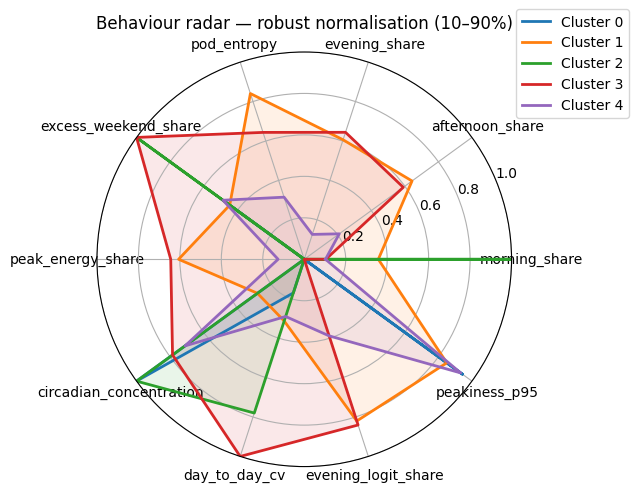

In [22]:
fig = plot_behavior_radar_robust(df_switch_transformed, labels_K5)
fig.savefig("artifacts/profilazione/figs/behaviour_radar_K5.png", dpi=150, bbox_inches="tight")


## 8) Outlier Inspection

Use reconstruction error (MSE) distribution per cluster to flag outliers — e.g., **95th percentile** or **IQR rule**.  
This supports triage actions (support/education) and data quality checks.


/var/tmp/pbs.883277.pbs-7/ipykernel_18207/3140345400.py:302: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grp.apply(lambda g: (g["event_slot_rate"]>0).mean()).rename("share_partecipanti"),


Profiling done. Tables and figures saved to: /rds/general/user/mg2324/home/HPC_test/irp-mg2324/artifacts/profilazione


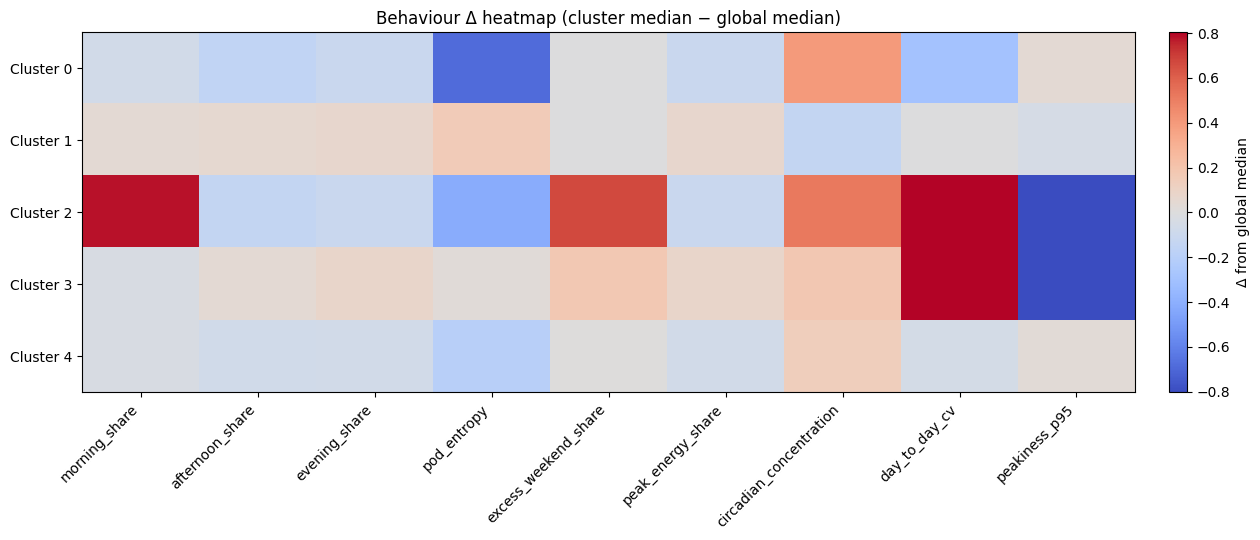

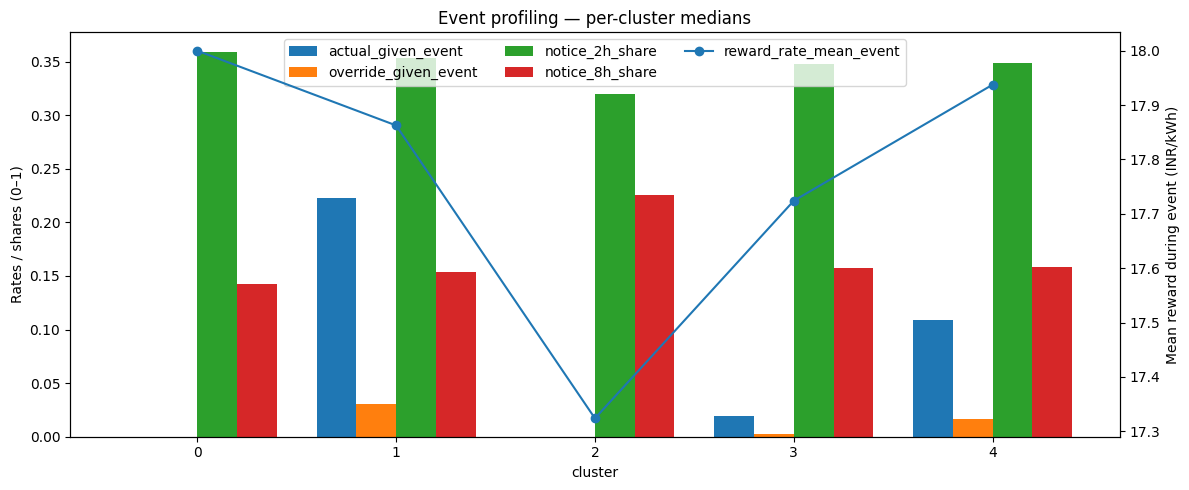

In [21]:
# === POST-PLOT: profiling + exports (drop-in) =================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------------------------
# 1) Helper: behaviour delta-by-cluster (Δ from global median) + heatmap
# ------------------------------------------------------------------------------
def summarize_behaviour_by_cluster(
    df_long: pd.DataFrame,
    labels: pd.Series,
    features: list | None = None
) -> pd.DataFrame:
    """
    Build a 'cluster cards' table with behaviour medians by cluster and
    deltas from global medians (same features used in the radar).

    Parameters
    ----------
    df_long : pd.DataFrame
        Long table with per-slot rows. Behaviour features must be user-level
        invariants already present in df_long (e.g., added by add_behavior_features).
    labels : pd.Series
        Index = 'ca_number', values = cluster id (KMeans output).
    features : list or None
        If None, auto-pick a robust default set (only those present in df_long).

    Returns
    -------
    pd.DataFrame
        MultiIndex columns ('median', 'delta'), indexed by cluster,
        values for each selected behaviour feature.
    """
    # Pick robust default features (only those that exist)
    default = [
        "morning_share", "afternoon_share", "evening_share",
        "pod_entropy", "excess_weekend_share", "peak_energy_share",
        "circadian_concentration", "day_to_day_cv", "peakiness_p95",
        "evening_logit_share"
    ]
    feats = [c for c in (features or default) if c in df_long.columns]
    if len(feats) < 3:
        raise ValueError(f"Too few behaviour features available for summary. Found={feats}")

    # Collapse to user-level (features are user-level constants replicated on slots)
    X_user = (
        df_long.groupby("ca_number", observed=True)[feats]
        .first()
        .join(labels.rename("cluster"), how="inner")
    )

    # Global medians (for deltas)
    gmed = X_user[feats].median()

    # Cluster medians and deltas
    cmed = X_user.groupby("cluster", observed=True)[feats].median().sort_index()
    cdel = (cmed - gmed)  # Δ = median(cluster) - median(global)

    # MultiIndex columns: ('median', feat) and ('delta', feat)
    out = pd.concat(
        {"median": cmed, "delta": cdel},
        axis=1
    )
    return out


def plot_behaviour_delta_heatmap(
    cards: pd.DataFrame,
    outpath: str | None = None,
    vlim: float | None = None
) -> plt.Figure:
    """
    Heatmap of behaviour deltas (Δ from global median) per cluster.

    Parameters
    ----------
    cards : pd.DataFrame
        Output of summarize_behaviour_by_cluster (MultiIndex columns).
    outpath : str or None
        If provided, save PNG to this path.
    vlim : float or None
        Symmetric limit for color scale. If None, compute from data (95th perc).

    Returns
    -------
    plt.Figure
    """
    delta = cards["delta"]  # clusters x features
    feats = list(delta.columns)
    clust = list(delta.index)

    # symmetric color range
    if vlim is None:
        m = np.nanpercentile(np.abs(delta.values), 95)
        vlim = max(m, 1e-6)

    fig, ax = plt.subplots(figsize=(1.2*len(feats)+2, 0.7*len(clust)+2))
    im = ax.imshow(delta.values, aspect="auto", cmap="coolwarm", vmin=-vlim, vmax= vlim)

    ax.set_xticks(range(len(feats)))
    ax.set_xticklabels(feats, rotation=45, ha="right")
    ax.set_yticks(range(len(clust)))
    ax.set_yticklabels([f"Cluster {k}" for k in clust])

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    cbar.set_label("Δ from global median", rotation=90)

    ax.set_title("Behaviour Δ heatmap (cluster median − global median)")
    fig.tight_layout()
    if outpath:
        Path(outpath).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(outpath, dpi=150, bbox_inches="tight")
    return fig


# ------------------------------------------------------------------------------
# 2) Helper: event-profile bars (slot rates & conditional medians)
# ------------------------------------------------------------------------------
def plot_event_profile_bars_from_profile(
    prof: dict,
    outpath: str | None = None
) -> plt.Figure:
    """
    Bar chart of per-cluster medians for key event metrics:
    - actual_given_event, override_given_event (conditional)
    - notice_2h_share, notice_8h_share (conditional)
    - reward_rate_mean_event (right axis)

    Parameters
    ----------
    prof : dict
        Output of profile_clusters_powbal(...).
    outpath : str or None
        If provided, save PNG to this path.

    Returns
    -------
    plt.Figure
    """
    per_user = prof["per_user"].copy()
    # Choose only metrics that exist
    cond_cols = [c for c in [
        "actual_given_event", "override_given_event",
        "notice_2h_share", "notice_8h_share"
    ] if c in per_user.columns]
    reward_col = "reward_rate_mean_event" if "reward_rate_mean_event" in per_user.columns else None

    med = per_user.groupby("cluster", observed=True)[cond_cols].median().sort_index()

    fig, ax = plt.subplots(figsize=(12, 5))
    width = 0.8 / max(1, len(cond_cols))
    ks = med.index.to_list()

    # Left axis bars
    for i, c in enumerate(cond_cols):
        ax.bar([k + (i - (len(cond_cols)-1)/2.)*width for k in range(len(ks))],
               med[c].values, width=width, label=c)

    ax.set_xticks(range(len(ks)))
    ax.set_xticklabels(ks)
    ax.set_xlabel("cluster")
    ax.set_ylabel("Rates / shares (0–1)")
    ax.set_title("Event profiling — per-cluster medians")

    # Right axis: reward
    if reward_col is not None:
        med_r = per_user.groupby("cluster", observed=True)[reward_col].median().sort_index()
        ax2 = ax.twinx()
        ax2.plot(range(len(ks)), med_r.values, marker="o", linestyle="-", label=reward_col)
        ax2.set_ylabel("Mean reward during event (INR/kWh)")
        # Build a single legend
        lines, labels = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines + lines2, labels + labels2, loc="upper center", ncols=3)
    else:
        ax.legend(loc="upper center", ncols=3)

    fig.tight_layout()
    if outpath:
        Path(outpath).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(outpath, dpi=150, bbox_inches="tight")
    return fig


# ------------------------------------------------------------------------------
# 3) RUN: profiling + exports for your K=5 solution
# ------------------------------------------------------------------------------
OUTDIR = Path("artifacts/profilazione")
OUTDIR.mkdir(parents=True, exist_ok=True)

# 3.1) Build powbal overlay and per-cluster profiling
prof_K5 = profile_clusters_powbal(df_switch_transformed, labels_K5)
save_profilazione_outputs(prof_K5, OUTDIR, tag="K5")   # CSV: per_user, cluster_summary, city/appliance top

# 3.2) Behaviour 'cards' (Δ from global median) using radar features and heatmap
# Canonical behaviour features used by the clustering & radar
BEHAV_FEATURES = [
    "morning_share", "afternoon_share", "evening_share",
    "pod_entropy", "excess_weekend_share", "peak_energy_share",
    "circadian_concentration", "day_to_day_cv", "peakiness_p95",
]

cards_K5 = summarize_behaviour_by_cluster(
    df_switch_transformed, labels_K5, features=BEHAV_FEATURES
)

cards_K5.to_csv(OUTDIR / "behaviour_cards_K5.csv")
_ = plot_behaviour_delta_heatmap(cards_K5, OUTDIR / "figs/behaviour_delta_heatmap_K5.png")

# 3.3) Event-profile bars (medians) and save figure
_ = plot_event_profile_bars_from_profile(prof_K5, OUTDIR / "figs/event_medians_K5.png")
print("Profiling done. Tables and figures saved to:", OUTDIR.resolve())


In [22]:
missing = [c for c in BEHAV_FEATURES if c not in df_switch_transformed.columns]
if missing:  # you likely forgot to build features in this session
    df_switch_transformed = add_behavior_features(df_switch_transformed)


In [23]:

def build_user_season_share(
    df_long: pd.DataFrame,
    id_col: str = "ca_number",
    season_col: str = "season"
) -> pd.DataFrame:
    """
    Build per-user season shares from slot-level records.

    Parameters
    ----------
    df_long : pd.DataFrame
        Long table with at least [id_col, season_col] at 30-min resolution.
    id_col : str
        User id column.
    season_col : str
        Season categorical column (e.g., 'Winter', 'Summer', ...).

    Returns
    -------
    pd.DataFrame
        Index = user id; columns = 'season_<name>_share' in [0,1] summing to 1 per user.
    """
    d = df_long[[id_col, season_col]].dropna()
    # counts per user x season
    counts = d.groupby([id_col, season_col], observed=True).size().unstack(fill_value=0)
    shares = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    shares.columns = [f"season_{c}_share" for c in shares.columns]
    return shares

def summarize_user_season_by_cluster(
    per_user_season: pd.DataFrame,
    labels: pd.Series
) -> dict:
    """
    Join per-user season shares with cluster labels and compute robust summaries.

    Parameters
    ----------
    per_user_season : pd.DataFrame
        Output of build_user_season_share (index=ca_number).
    labels : pd.Series
        Cluster id per user (index must match users); values are integers.

    Returns
    -------
    dict
        {
          'per_user' : per-user table with 'cluster',
          'median'   : per-cluster medians of season shares,
          'p25'      : per-cluster 25th percentiles,
          'p75'      : per-cluster 75th percentiles
        }
    """
    labs = labels.rename("cluster")
    df = per_user_season.join(labs, how="left")
    assert df["cluster"].notna().all(), "Some users have no cluster label."
    grp = df.groupby("cluster", observed=True)
    return {
        "per_user": df,
        "median": grp.median().sort_index(),
        "p25": grp.quantile(0.25).sort_index(),
        "p75": grp.quantile(0.75).sort_index(),
    }

def plot_season_bars_user(
    median_df: pd.DataFrame,
    title: str = "Season share per user — median by cluster"
) -> plt.Figure:
    """
    Grouped bars: clusters on x, one bar per season = median user share in that cluster.
    """
    seasons = list(median_df.columns)
    x = np.arange(len(median_df.index))
    width = 0.8 / max(1, len(seasons))

    fig, ax = plt.subplots(figsize=(10, 4))
    for i, s in enumerate(seasons):
        label = s.replace("season_", "").replace("_share", "")
        ax.bar(x + i * width - 0.4 + width / 2, median_df[s].values, width, label=label)

    ax.set_xlabel("cluster")
    ax.set_ylabel("Median user share (0–1)")
    ax.set_xticks(x)
    ax.set_xticklabels(median_df.index)
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.20), ncol=4, frameon=False, fontsize=9)
    fig.tight_layout()
    return fig


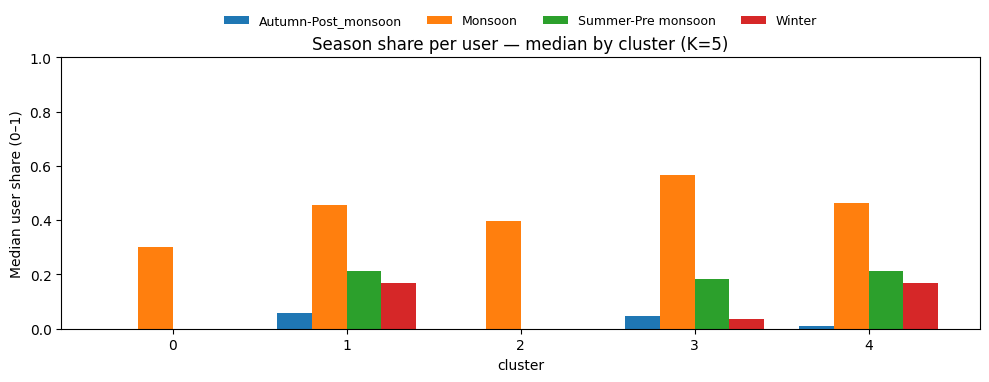

In [24]:
# Build per-user shares, summarize by cluster, and plot (K=5 example)
season_user = build_user_season_share(df_switch_transformed)
season_user_sum = summarize_user_season_by_cluster(season_user, labels_K5)

fig5 = plot_season_bars_user(season_user_sum["median"],
                             title="Season share per user — median by cluster (K=5)")
fig5.savefig(FIGDIR / "season_user_median_bars_K5.png", dpi=150, bbox_inches="tight")

# (opzionale) esporta tabelle per il report/dashboard
(OUTDIR / "profilazione").mkdir(parents=True, exist_ok=True)
season_user.to_csv(OUTDIR / "profilazione" / "season_user_shares.csv")
season_user_sum["median"].to_csv(OUTDIR / "profilazione" / "season_user_median_by_cluster_K5.csv")


In [24]:
df = df_switch_transformed              # long table con feature di comportamento + derivate
labels = labels_K5                      # Serie: index=ca_number, values=cluster (p.es. K=5)
ID_COL = "ca_number"


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List, Optional, Dict

# ---------------------------
# Utilities
# ---------------------------
def _require(df: pd.DataFrame, cols: List[str], where: str = ""):
    """Raise a helpful error if required columns are missing."""
    miss = [c for c in cols if c not in df.columns]
    if miss:
        where = f" in {where}" if where else ""
        raise ValueError(f"Missing columns{where}: {miss}")

def _join_labels(df_long: pd.DataFrame, labels: pd.Series, id_col: str) -> pd.DataFrame:
    """Join cluster labels to the long table; expects labels.index = id_col."""
    if not isinstance(labels, pd.Series):
        raise TypeError("labels must be a pd.Series with index=ca_number and values=cluster")
    if labels.index.name != id_col:
        labels = labels.rename_axis(id_col)
    d = df_long.merge(labels.rename("cluster"), left_on=id_col, right_index=True, how="left")
    if d["cluster"].isna().any():
        raise ValueError("Some rows have no cluster after join; check id_col and label index.")
    return d

# ---------------------------
# Behaviour summary / heatmap
# ---------------------------
BEHAVIOUR_FEATURES = [
    "morning_share","afternoon_share","evening_share",      # night_share esclusa per evitare somma=1
    "pod_entropy","excess_weekend_share","peak_energy_share",
    "circadian_concentration","day_to_day_cv","peakiness_p95",
]

def summarise_behaviour_by_cluster(df_long: pd.DataFrame, labels: pd.Series, id_col: str) -> pd.DataFrame:
    """
    Compute per-cluster medians for behaviour features, and global medians.
    Returns a tidy table with index=cluster and columns=features; also returns global medians.
    """
    _require(df_long, BEHAVIOUR_FEATURES + [id_col], "summarise_behaviour_by_cluster")
    d = _join_labels(df_long, labels, id_col)
    # collapse to user-level medians (robust to long-table duplication)
    g_user = d.groupby([id_col,"cluster"], observed=True)[BEHAVIOUR_FEATURES].median()
    cl_med = g_user.groupby("cluster", observed=True).median()
    gl_med = g_user.median()
    return cl_med, gl_med

def plot_behaviour_delta_heatmap(df_long: pd.DataFrame, labels: pd.Series, id_col: str,
                                 outdir: Path, tag: str = "K") -> plt.Figure:
    """
    Heatmap of (cluster median - global median) for behaviour features.
    Saves 'figs/behaviour_delta_heatmap_{tag}.png' under outdir.
    """
    cl_med, gl_med = summarise_behaviour_by_cluster(df_long, labels, id_col)
    delta = cl_med.subtract(gl_med, axis=1)

    fig, ax = plt.subplots(figsize=(10, 4.2), dpi=150)
    im = ax.imshow(delta.values, cmap="coolwarm", aspect="auto", vmin=-np.nanmax(np.abs(delta.values)), vmax=np.nanmax(np.abs(delta.values)))

    ax.set_yticks(range(len(delta.index)))
    ax.set_yticklabels([f"Cluster {c}" for c in delta.index])
    ax.set_xticks(range(len(delta.columns)))
    ax.set_xticklabels(delta.columns, rotation=45, ha="right")
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Δ from global median")

    ax.set_title(f"Behaviour Δ heatmap (cluster median – global median) [{tag}]")
    fig.tight_layout()

    (outdir / "figs").mkdir(parents=True, exist_ok=True)
    fig.savefig(outdir / f"figs/behaviour_delta_heatmap_{tag}.png", bbox_inches="tight")
    return fig

# ---------------------------
# Event overlay (per-user → per-cluster medians)
# ---------------------------
def build_powbal_overlay(df_long: pd.DataFrame, id_col: str) -> pd.DataFrame:
    """
    Build per-user overlay metrics used for event profiling, following the trial semantics:
      - has_event: scheduled_event AND (reward_rate>0 OR notice_time in {2,8})
      - actual_event: device was consuming before event and turned off at event time
      - override: actual_event==1 & reward==0
    Returns a user-level table indexed by id_col.
    """
    required = [id_col, "reward_rate", "notice_time", "switch_off_event", "posted_to_api"]
    _require(df_long, required, "build_powbal_overlay (base columns)")
    d = df_long.copy()

    # scheduled_event & has_event (robust to zeros) – aligns with supervisor clarification
    # (notice_time==0 & reward_rate==0 -> no event; else event).  See project notes.  # noqa
    d["scheduled_event"] = ((d["switch_off_event"] == 1) & (d["posted_to_api"] == 1)).astype(np.int8)
    rr = d["reward_rate"].fillna(0)
    nt = d["notice_time"].fillna(0)
    d["has_event"] = (d["scheduled_event"].eq(1) & ((rr > 0) | (nt.isin([2, 8])))).astype(np.int8)

    # actual_event (keep if present; otherwise infer from pre_switch_off_reading if available)
    if "actual_event" not in d.columns:
        if "pre_switch_off_reading" in d.columns:
            d["actual_event"] = np.where(
                d["scheduled_event"].eq(1) &
                d["pre_switch_off_reading"].notna() &
                (d["pre_switch_off_reading"] != 0),
                1, 0).astype(np.int8)
        else:
            d["actual_event"] = 0

    # override as in supervisor definition
    if "override" not in d.columns:
        d["reward"] = d.get("reward", 0.0)
        d["override"] = np.where(
            d["actual_event"].eq(1) & pd.Series(d["reward"]).fillna(0).eq(0),
            1, 0).astype(np.int8)

    # notice flags (only on event slots)
    d["notice_2h"] = 0; d["notice_8h"] = 0
    ev = d["has_event"].eq(1)
    if "notice_time" in d.columns:
        d.loc[ev & d["notice_time"].eq(2), "notice_2h"] = 1
        d.loc[ev & d["notice_time"].eq(8), "notice_8h"] = 1

    # group to user-level metrics
    g = d.groupby(id_col, observed=True)
    idx = g.size().index

    event_slot_rate  = g["has_event"].mean().reindex(idx)
    actual_rate_slot = g["actual_event"].mean().reindex(idx)
    override_rate    = g["override"].mean().reindex(idx)

    eps = 1e-12
    actual_given_event   = (actual_rate_slot  / (event_slot_rate + eps)).where(event_slot_rate > 0)
    override_given_event = (override_rate     / (event_slot_rate + eps)).where(event_slot_rate > 0)

    reward_rate_mean_event = d.loc[ev].groupby(id_col)["reward_rate"].mean().reindex(idx)
    notice_2h_share = d.loc[ev].groupby(id_col)["notice_2h"].mean().reindex(idx)
    notice_8h_share = d.loc[ev].groupby(id_col)["notice_8h"].mean().reindex(idx)

    out = pd.DataFrame({
        "event_slot_rate":        event_slot_rate,
        "actual_rate_slot":       actual_rate_slot,
        "override_rate":          override_rate,
        "actual_given_event":     actual_given_event,
        "override_given_event":   override_given_event,
        "reward_rate_mean_event": reward_rate_mean_event,
        "notice_2h_share":        notice_2h_share,
        "notice_8h_share":        notice_8h_share,
    })
    # optional metadata
    for c in ["city", "appliance", "season"]:
        if c in d.columns:
            out[c] = g[c].agg(lambda s: s.mode().iloc[0] if not s.mode().empty else None)
    return out

def profile_event_medians(df_long: pd.DataFrame, labels: pd.Series, id_col: str) -> pd.DataFrame:
    """
    Compute per-cluster medians of the per-user overlay metrics.
    """
    per_user = build_powbal_overlay(df_long, id_col)
    per_user = per_user.join(labels.rename("cluster"), how="left")
    metrics = [
        "actual_given_event","override_given_event","notice_2h_share","notice_8h_share",
        "reward_rate_mean_event"
    ]
    grp = per_user.groupby("cluster", observed=True)
    return grp[metrics].median().sort_index()

def plot_event_profile_bars(df_long: pd.DataFrame, labels: pd.Series, id_col: str,
                            outdir: Path, tag: str = "K") -> plt.Figure:
    """
    Bar chart per cluster: medians of actual_given_event, override_given_event, notice shares
    with a line for reward_rate_mean_event.
    """
    S = profile_event_medians(df_long, labels, id_col)
    fig, ax1 = plt.subplots(figsize=(10, 4.2), dpi=150)

    x = np.arange(len(S.index))
    w = 0.18
    ax1.bar(x - 1.5*w, S["actual_given_event"].values, width=w, label="actual_given_event")
    ax1.bar(x - 0.5*w, S["override_given_event"].values, width=w, label="override_given_event")
    ax1.bar(x + 0.5*w, S["notice_2h_share"].values, width=w, label="notice_2h_share")
    ax1.bar(x + 1.5*w, S["notice_8h_share"].values, width=w, label="notice_8h_share")
    ax1.set_xticks(x)
    ax1.set_xticklabels(S.index)
    ax1.set_xlabel("cluster"); ax1.set_ylabel("Rates / shares (0–1)")

    ax2 = ax1.twinx()
    ax2.plot(x, S["reward_rate_mean_event"].values, marker="o", label="reward_rate_mean_event", linestyle="-")
    ax2.set_ylabel("Mean reward during event (INR/kWh)")

    lines, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels1 + labels2, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.15))

    ax1.set_title(f"Event profiling — per-cluster medians [{tag}]")
    fig.tight_layout()
    (outdir / "figs").mkdir(parents=True, exist_ok=True)
    fig.savefig(outdir / f"figs/event_medians_{tag}.png", bbox_inches="tight")
    return fig

# ---------------------------
# Top city/appliance (small-multiples)
# ---------------------------
def _top_share_bar(per_user: pd.DataFrame, col: str, outdir: Path, tag: str, top_k: int = 5) -> Optional[plt.Figure]:
    """
    Small-multiples with top-k categories per cluster for a column (city or appliance).
    """
    if col not in per_user.columns:
        return None
    cats = []
    for cl, d in per_user.groupby("cluster", observed=True):
        c = (d[col].value_counts(dropna=True, normalize=True)
             .head(top_k).rename(f"Cluster {cl}"))
        cats.append(c)
    if not cats:
        return None
    T = pd.concat(cats, axis=1).fillna(0.0)

    n = T.shape[1]
    fig, axes = plt.subplots(1, n, figsize=(3.0*n, 3.0), dpi=150, sharey=True)
    if n == 1: axes = [axes]
    for ax, (cl, s) in zip(axes, T.items()):
        ax.barh(s.index, s.values)
        ax.set_title(cl); ax.set_xlabel("Share"); ax.set_xlim(0, 1)
    axes[0].set_ylabel(col)
    fig.suptitle(f"Top-{top_k} {col} per cluster [{tag}]", y=1.02)
    fig.tight_layout()
    (outdir / "figs").mkdir(parents=True, exist_ok=True)
    fig.savefig(outdir / f"figs/{col}_top_{tag}.png", bbox_inches="tight")
    return fig

# ---------------------------
# Season share — per user, median per cluster
# ---------------------------
def plot_season_share_per_user(df_long: pd.DataFrame, labels: pd.Series, id_col: str,
                               outdir: Path, tag: str = "K") -> Optional[plt.Figure]:
    """
    Median user share of seasons by cluster.
    Expects a 'season' column with finite set of categories.
    """
    if "season" not in df_long.columns:
        return None
    seasons = [c for c in sorted(df_long["season"].dropna().unique())]
    d = _join_labels(df_long, labels, id_col)
    g = d.groupby([id_col, "cluster", "season"], observed=True).size().rename("n").reset_index()
    g["user_total"] = g.groupby([id_col, "cluster"])["n"].transform("sum")
    g["share"] = g["n"] / g["user_total"]
    # median share per season & cluster
    med = g.groupby(["cluster","season"], observed=True)["share"].median().unstack(fill_value=0.0)
    cl = med.index

    fig, ax = plt.subplots(figsize=(10, 3.6), dpi=150)
    bottom = np.zeros(len(cl))
    for s in seasons:
        vals = med.get(s, pd.Series(0.0, index=cl)).values
        ax.bar(cl, vals, bottom=bottom, label=s)
        bottom += vals
    ax.set_xlabel("cluster"); ax.set_ylabel("Median user share (0–1)")
    ax.set_title(f"Season share per user — median by cluster ({tag})")
    ax.legend(ncol=min(4, len(seasons)), loc="upper center", bbox_to_anchor=(0.5, 1.18))
    fig.tight_layout()

    (outdir / "figs").mkdir(parents=True, exist_ok=True)
    fig.savefig(outdir / f"figs/season_share_user_{tag}.png", bbox_inches="tight")
    return fig

# ---------------------------
# Derived features (new visuals)
# ---------------------------
DERIVED_REQ = [
    "event_upcoming_count_3h","event_next_run_class",
    "event_recent_count_8h","override_rolling_8h"
]

def _join_for_derived(df_long: pd.DataFrame, labels: pd.Series, id_col: str) -> pd.DataFrame:
    """Join labels and require derived columns."""
    _require(df_long, DERIVED_REQ + [id_col], "_join_for_derived")
    return _join_labels(df_long, labels, id_col)

def plot_upcoming_count_bars(df_long: pd.DataFrame, labels: pd.Series, id_col: str,
                             outdir: Path, tag: str = "K") -> plt.Figure:
    """Bar of mean event_upcoming_count_3h per cluster."""
    d = _join_for_derived(df_long, labels, id_col)
    cl_mean = d.groupby("cluster", observed=True)["event_upcoming_count_3h"].mean()
    fig, ax = plt.subplots(figsize=(8,3), dpi=150)
    ax.bar(cl_mean.index, cl_mean.values)
    ax.set_title(f"Upcoming events within 3h — mean by cluster [{tag}]")
    ax.set_xlabel("cluster"); ax.set_ylabel("count (0–6)")
    fig.tight_layout()
    (outdir / "figs").mkdir(parents=True, exist_ok=True)
    fig.savefig(outdir / f"figs/upcoming3h_mean_{tag}.png", bbox_inches="tight")
    return fig

def plot_season_share_per_user_fixed(df_long: pd.DataFrame, labels: pd.Series,
                                     id_col: str = "ca_number",
                                     season_col: str = "season",
                                     energy_col: str = "energy_Wh"):
    """
    Plot median per-user seasonal shares by cluster (bars sum to 1 per user before aggregation).
    Steps:
      1) Build per-user seasonal shares that sum to 1 (using energy weights).
      2) Join cluster labels and compute median share per cluster & season.
      3) Stacked bar chart (one bar per cluster, 100% scale).
    """
    d = df_long[[id_col, season_col, energy_col]].copy()
    g = d.groupby([id_col, season_col], observed=True)[energy_col].sum().unstack(season_col).fillna(0.0)
    per_user = g.div(g.sum(axis=1).replace(0, 1), axis=0)  # row-normalize to 1

    per_user = per_user.join(labels.rename("cluster"), how="left")
    assert per_user["cluster"].notna().all(), "Missing cluster labels for some users."

    med = per_user.groupby("cluster", observed=True).median()
    med = med[sorted(med.columns)]  # stable order

    fig, ax = plt.subplots(figsize=(10, 4))
    bottom = None
    for col in med.columns:
        ax.bar(med.index.astype(str), med[col], bottom=bottom, label=col)
        bottom = med[col] if bottom is None else bottom + med[col]

    ax.set_ylabel("Median user share (0–1)")
    ax.set_xlabel("cluster")
    ax.set_title("Season share per user — median by cluster")
    ax.legend(ncol=4, bbox_to_anchor=(0.5, 1.15), loc="upper center")
    ax.set_ylim(0, 1)
    return fig

def _event_context_filter(df: pd.DataFrame, horizon_steps: int = 6) -> pd.DataFrame:
    """
    Keep only slots that lie in the decision context (next event within ~3h).
    This uses the L1..L6 flags (0.5h steps).
    """
    L_cols = [f"switch_off_L{i}" for i in range(1, horizon_steps+1) if f"switch_off_L{i}" in df.columns]
    assert L_cols, "L* flags not found; provide L1..L6 in the dataframe."
    return df.loc[df[L_cols].sum(axis=1) > 0].copy()

def plot_next_run_class_by_cluster(df: pd.DataFrame, labels: pd.Series) -> plt.Figure:
    """
    Show distribution of 'event_next_run_class' (none / 1_slot / 2+_slots) within the decision context.
    If the 'none' mass dominates, you're plotting too many non-event slots.
    """
    d = _event_context_filter(df)
    d = d.join(labels.rename("cluster"), on="ca_number")
    tab = (d.groupby(["cluster", "event_next_run_class"]).size()
             .groupby(level=0).apply(lambda s: s / s.sum())
             .rename("share").reset_index())

    pivot = tab.pivot(index="cluster", columns="event_next_run_class", values="share").fillna(0)
    fig, ax = plt.subplots(figsize=(8, 4))
    pivot.plot(kind="bar", stacked=True, ax=ax)
    ax.set_ylabel("share")
    ax.set_xlabel("cluster")
    ax.set_title("Next run class distribution by cluster (decision context)")
    ax.legend(title="class", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.set_ylim(0, 1)
    return fig


def plot_override_recent_hist(df: pd.DataFrame, labels: pd.Series) -> plt.Figure:
    """
    Histograms of override_rolling_8h and event_recent_count_8h per cluster, restricted to decision context.
    Prevents the 'all-zero' artifact seen when computed over all slots.
    """
    d = _event_context_filter(df).join(labels.rename("cluster"), on="ca_number")
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    for ax, col in zip(axes, ["override_rolling_8h", "event_recent_count_8h"]):
        sns.boxplot(data=d, x="cluster", y=col, ax=ax)
        ax.set_xlabel("cluster")
        ax.set_title(col)

    fig.suptitle("Distributions in decision context")
    return fig


def plot_recency_vs_upcoming_scatter(df_long: pd.DataFrame, labels: pd.Series, id_col: str,
                                     outdir: Path, tag: str = "K", max_points: int = 12000) -> plt.Figure:
    """Scatter of event_recent_count_8h (x) vs event_upcoming_count_3h (y), coloured by cluster."""
    d = _join_for_derived(df_long, labels, id_col)
    if len(d) > max_points:
        d = d.sample(max_points, random_state=42)
    clrs = plt.cm.tab10(np.linspace(0,1,len(d["cluster"].unique())))
    fig, ax = plt.subplots(figsize=(7,4), dpi=150)
    for i, (cl, g) in enumerate(d.groupby("cluster", observed=True)):
        ax.scatter(g["event_recent_count_8h"], g["event_upcoming_count_3h"], s=8, alpha=0.25, label=f"C{cl}", color=clrs[i])
    ax.set_xlabel("recent count in 8h"); ax.set_ylabel("upcoming count in 3h (next)")
    ax.set_title(f"Recency × Imminence by cluster [{tag}]")
    ax.legend(loc="upper right", ncol=2, title="cluster")
    fig.tight_layout()
    (outdir / "figs").mkdir(parents=True, exist_ok=True)
    fig.savefig(outdir / f"figs/recency_vs_upcoming_{tag}.png", bbox_inches="tight")
    return fig

# ---------------------------
# Orchestrator
# ---------------------------
class StoryPack:
    """
    Orchestrates the full set of storytelling charts and saves them under outdir/figs.
    Usage:
        story = StoryPack(df, labels, id_col="ca_number", outdir=Path("artifacts/storytelling_K5"))
        story.run_all(show=True, tag="K5")
    """
    def __init__(self, df_long: pd.DataFrame, labels: pd.Series, id_col: str,
                 outdir: Path, show: bool = True, tag: str = "K"):
        self.df = df_long
        self.labels = labels
        self.id_col = id_col
        self.outdir = Path(outdir)
        self.outdir.mkdir(parents=True, exist_ok=True)
        self.show = show
        self.tag = tag

    def run_all(self):
        figs = []
        figs.append(plot_behaviour_delta_heatmap(self.df, self.labels, self.id_col, self.outdir, self.tag))
        figs.append(plot_event_profile_bars(self.df, self.labels, self.id_col, self.outdir, self.tag))

        # per-user overlay (for top shares)
        per_user = build_powbal_overlay(self.df, self.id_col).join(self.labels.rename("cluster"))
        figs.append(_top_share_bar(per_user, "city", self.outdir, self.tag))
        figs.append(_top_share_bar(per_user, "appliance", self.outdir, self.tag))

        figs.append(plot_season_share_per_user(self.df, self.labels, self.id_col, self.outdir, self.tag))

        # derived features
        figs.append(plot_upcoming_count_bars(self.df, self.labels, self.id_col, self.outdir, self.tag))
        figs.append(plot_next_run_class_by_cluster(self.df, self.labels, self.id_col, self.outdir, self.tag))
        figs.append(plot_recency_vs_upcoming_scatter(self.df, self.labels, self.id_col, self.outdir, self.tag))
        figs.append(plot_season_share_per_user_fixed(self.df, self.labels, self.id_col, self.outdir, self.tag))
        figs.append(plot_override_recent_hist(self.df, self.labels, self.id_col, self.outdir, self.tag))
        

        if self.show:
            for f in figs:
                if f is not None:
                    plt.show(f)

TypeError: plot_recent_vs_imminent_hex() takes 2 positional arguments but 5 were given

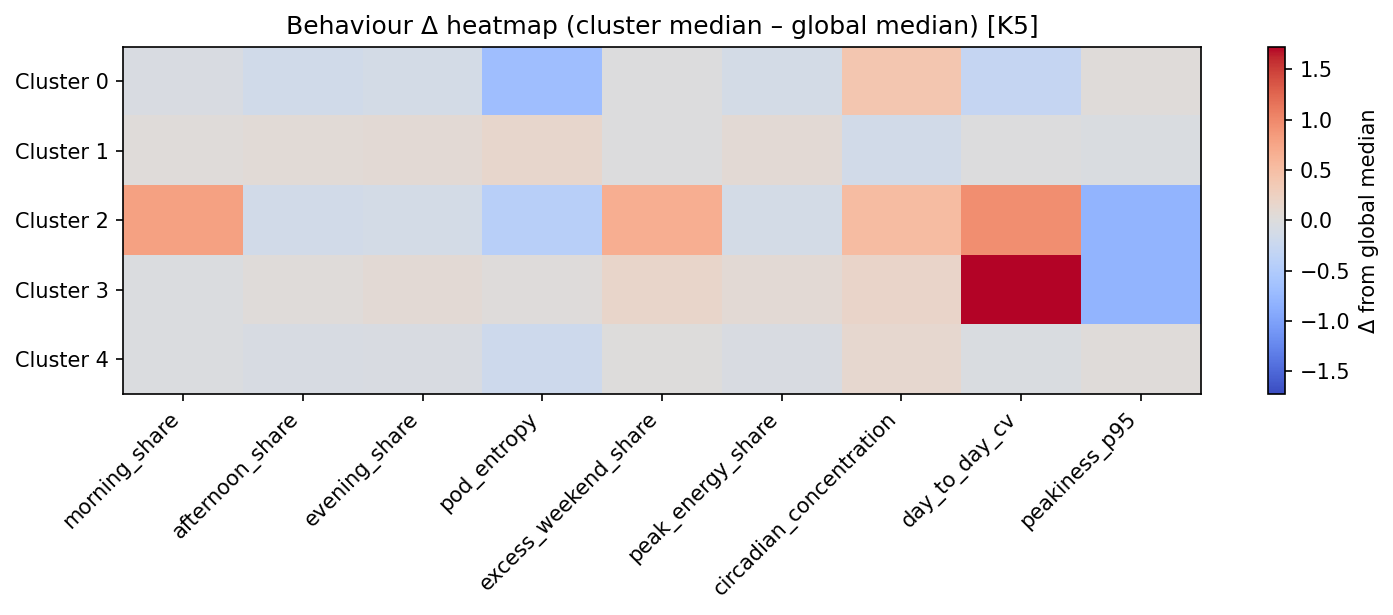

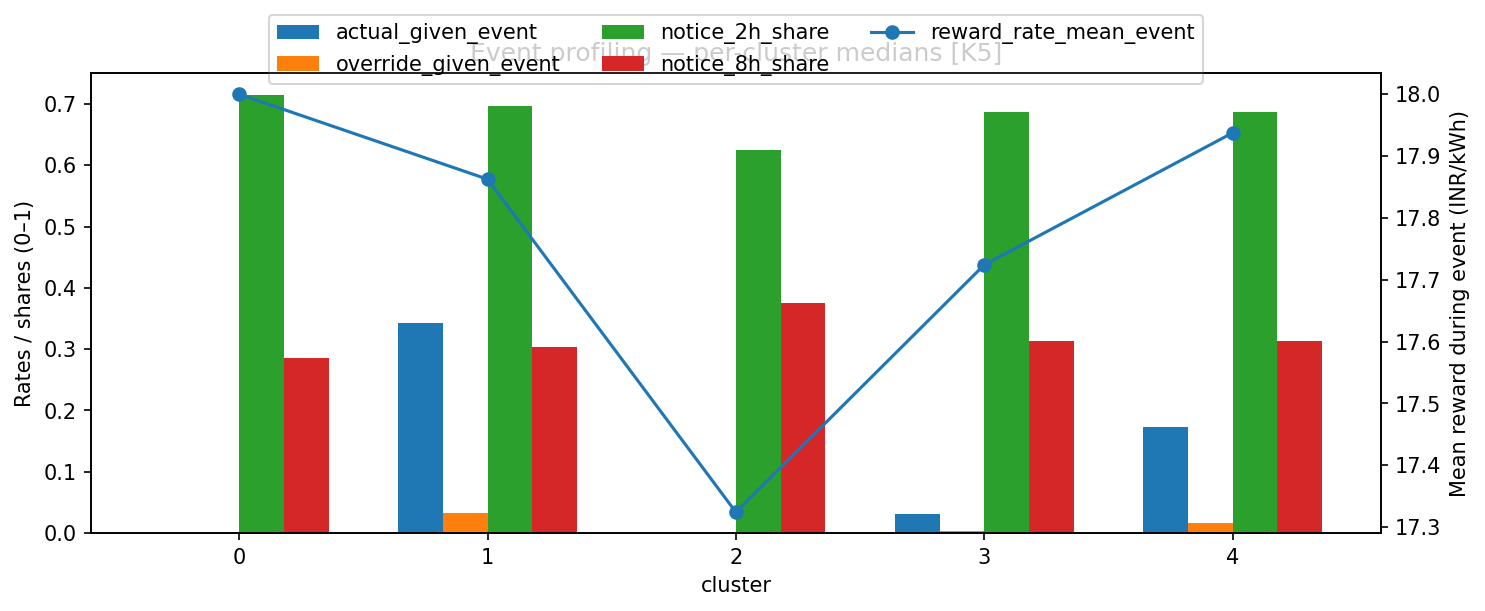

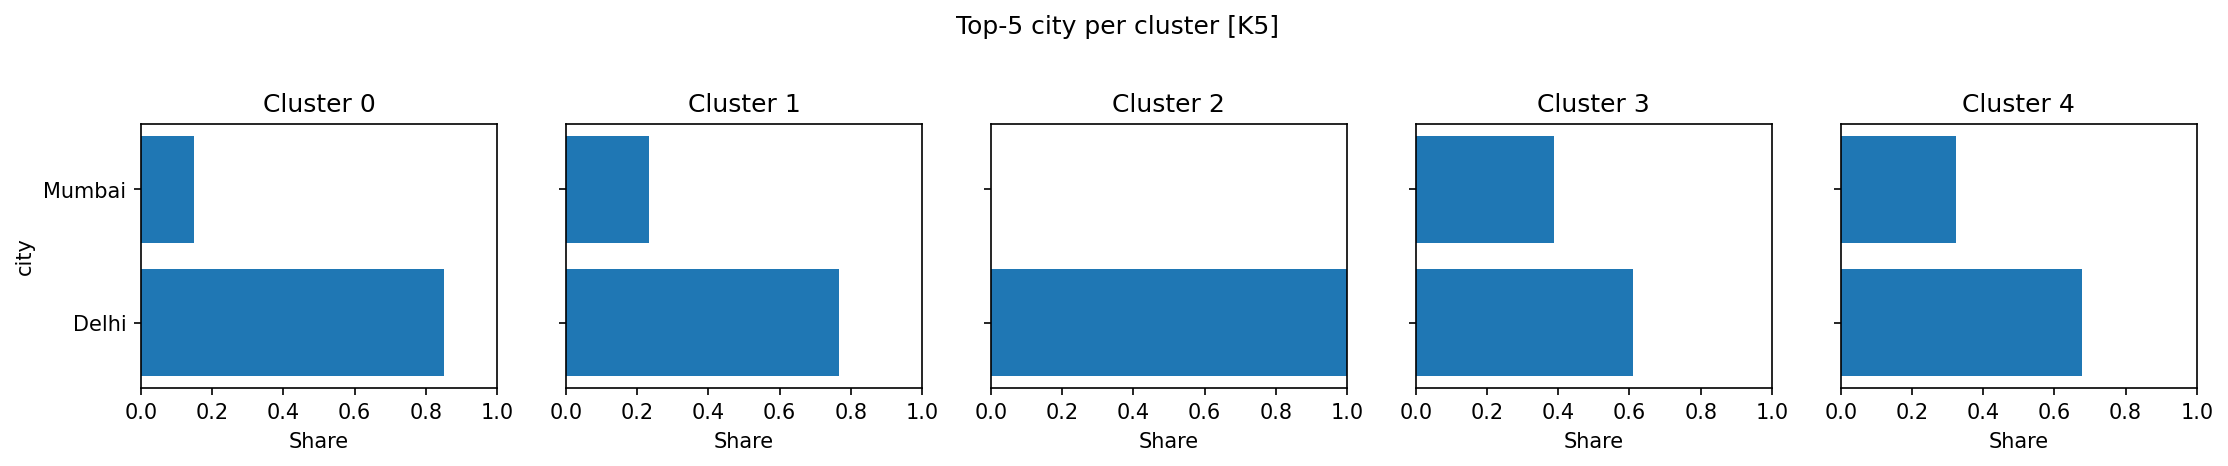

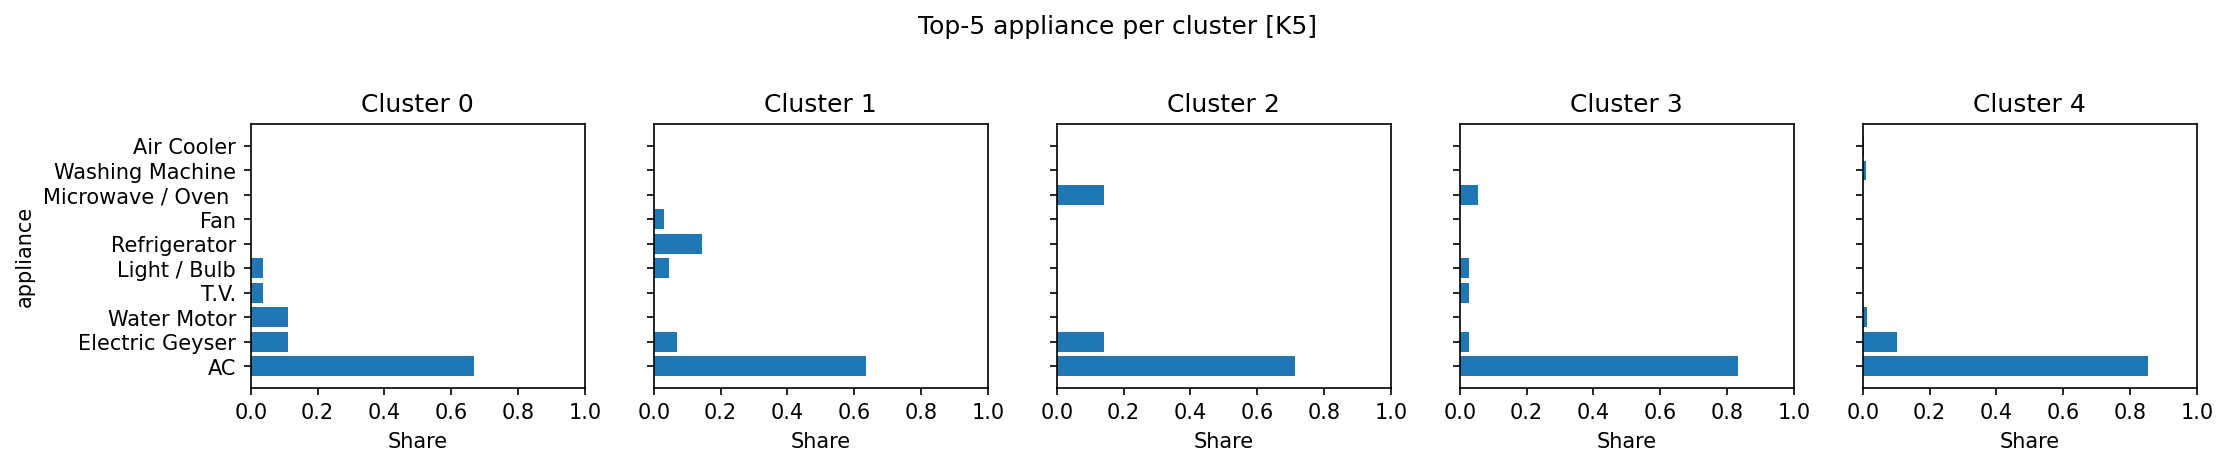

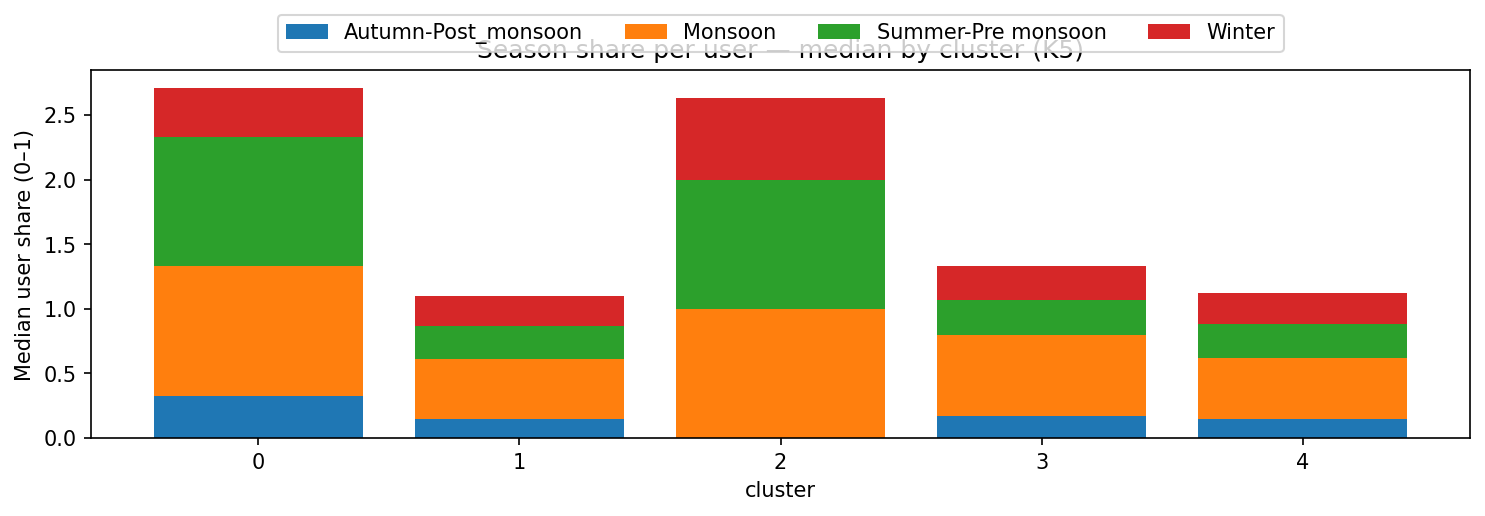

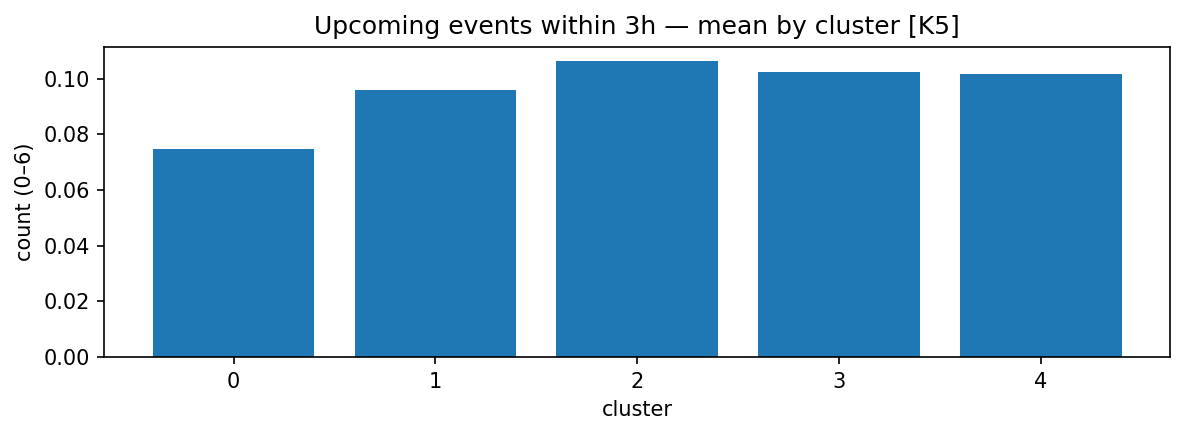

In [27]:
from pathlib import Path
OUTDIR = Path("artifacts/storytelling_K5")
OUTDIR.mkdir(parents=True, exist_ok=True)

# run everything (salva PNG + mostra inline)
story = StoryPack(df, labels, id_col=ID_COL, outdir=OUTDIR, show=True, tag="K5")
story.run_all()


START AUTOENCODER

In [11]:
labels_K5, info_K5 = fit_behavior_kmeans(
    df_switch_transformed,
    K_range=range(3, 10),
    manual_k=5,                 # <-- forzo K=5
    outdir="artifacts/clustering_behavior_K5"
)

In [ ]:
# labels, info = fit_behavior_kmeans(
#     df_switch_transformed,
#     feature_spec=None,
#     K_range=range(3, 10),
#     manual_k=None,
#     night_like="Night",
#     outdir="artifacts/clustering_behavior"
# )


In [8]:
# --- AE starter: imports & reproducibility -----------------------------------
from __future__ import annotations

from pathlib import Path
import json, os, time
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, losses, regularizers

# You already have these in your clustering notebook.
# We only *use* them here (do not re-implement).
# from your_clustering_module import transform_for_clustering
# If in the same notebook, the function is already defined in memory:
#   transform_for_clustering(df_long, artifacts_dir, id_col) -> (idx, Z_keep, Zs)

# --------------------- Reproducibility & logging ------------------------------
def set_all_seeds(seed: int = 42):
    """Set seeds for Python/numpy/TF to improve reproducibility."""
    import random
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def tf_quiet():
    """Reduce TF verbosity."""
    os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # errors & warnings only
    tf.get_logger().setLevel("ERROR")

set_all_seeds(42)
tf_quiet()
print("TF version:", tf.__version__)


TF version: 2.20.0


In [9]:
# --------------------- Paths & basic config -----------------------------------
ART_DIR = Path("artifacts/clustering_behavior_K5")  # or "artifacts/clustering_behavior_K5"
AE_DIR  = Path("artifacts/ae_behavior")
FIG_DIR = AE_DIR / "figs"
AE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

ID_COL = "ca_number"   # keep consistent with your pipeline
TAG    = "K5"          # purely for labeling outputs

# If you already cached labels to parquet you can load here; otherwise we'll
# pass them later or merge post-hoc.
# Example (optional):
# labels = pd.read_parquet("artifacts/clustering_behavior_K5/labels_K5.parquet")
# labels.name = "cluster"


In [10]:
# --------------------- Build AE dataset from clustering artifacts -------------
def prepare_ae_data(
    df_long: pd.DataFrame,
    artifacts_dir: str | Path = ART_DIR,
    id_col: str = ID_COL,
    test_size: float = 0.15,
    val_size: float = 0.15,
    seed: int = 42
):
    """
    Use the *same* preprocessing as clustering artifacts to build the AE matrix.
    Returns:
        dict with X_train, X_val, X_test (np.float32),
        index splits (idx_train/val/test), feature_names, and the *full* arrays.
    """
    # Your function (already defined in the clustering notebook)
    idx, Z_keep, Zs = transform_for_clustering(df_long, artifacts_dir=str(artifacts_dir), id_col=id_col)

    # Zs is the scaled numeric array; we keep it in float32 to save RAM
    X_full = np.asarray(Zs, dtype=np.float32)
    feature_names = list(Z_keep.columns)

    # Train/val/test split (stratify optional if you want cluster balance)
    idx_full = pd.Index(idx)
    X_train, X_temp, idx_train, idx_temp = train_test_split(
        X_full, idx_full, test_size=(test_size + val_size), random_state=seed
    )
    rel_val = val_size / (test_size + val_size)
    X_val, X_test, idx_val, idx_test = train_test_split(
        X_temp, idx_temp, test_size=(1 - rel_val), random_state=seed
    )

    return dict(
        X_full=X_full, idx_full=idx_full,
        X_train=X_train, X_val=X_val, X_test=X_test,
        idx_train=idx_train, idx_val=idx_val, idx_test=idx_test,
        feature_names=feature_names
    )


In [11]:
# df_switch_transformed must be your long table (same you used for clustering)
ae_data = prepare_ae_data(df_switch_transformed, artifacts_dir=ART_DIR, id_col=ID_COL)
for k,v in ae_data.items():
    if isinstance(v, np.ndarray): print(k, v.shape)


/rds/general/user/mg2324/home/HPC_test/IRPenv/lib64/python3.11/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/rds/general/user/mg2324/home/HPC_test/IRPenv/lib64/python3.11/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


X_full (992, 9)
X_train (694, 9)
X_val (149, 9)
X_test (149, 9)


define symmetric AE

## 6) Autoencoder (AE): Embeddings & Reconstruction Error

A symmetric dense AE learns a non‑linear user embedding and a per‑user reconstruction **MSE**.  
Training uses `EarlyStopping` and `ModelCheckpoint`; best model is saved (e.g., `ae_best_K5.keras`).  
Outputs saved to `artifacts/ae_K5/tables/`: **`embeddings_K5.parquet`** and **`recon_error_K5.parquet`**.  
Cells in this section cover **training** and **(if artifacts exist) reload**.


In [12]:
# --------------------- Build the autoencoder model ----------------------------
def build_autoencoder(
    input_dim: int,
    latent_dim: int = 8,
    width_factor: int = 2,
    dropout: float = 0.05,
    l2_reg: float = 1e-5,
    lr: float = 1e-3
) -> tuple[tf.keras.Model, tf.keras.Model]:
    """
    Create a small symmetric AE with MSE loss.
    - input_dim: number of features
    - latent_dim: size of bottleneck
    - width_factor: scales the hidden width ~ 2*input_dim/width_factor
    - dropout/l2_reg: gentle regularization to avoid trivial identity mapping
    Returns: (autoencoder, encoder)
    """
    reg = regularizers.l2(l2_reg)
    hidden = max(16, (input_dim * width_factor))

    inp = layers.Input(shape=(input_dim,), name="ae_input")
    x   = layers.Dense(hidden, activation="relu", kernel_regularizer=reg)(inp)
    x   = layers.Dropout(dropout)(x)
    x   = layers.Dense(hidden//2, activation="relu", kernel_regularizer=reg)(x)
    z   = layers.Dense(latent_dim, name="latent")(x)

    x   = layers.Dense(hidden//2, activation="relu", kernel_regularizer=reg)(z)
    x   = layers.Dropout(dropout)(x)
    out = layers.Dense(input_dim, activation="linear", name="recon")(x)

    ae = models.Model(inp, out, name="autoencoder")
    enc = models.Model(inp, z, name="encoder")

    ae.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss=losses.MeanSquaredError()
    )
    return ae, enc


## 7) Instant Reload (Artifacts → Tables/Figures)

If `labels_K5.parquet` and AE tables (`embeddings_*.parquet`, `recon_error_*.parquet`) exist under `artifacts/…`,  
this section **rebuilds diagnostic tables and plots without refitting**. If labels are missing, it reloads KMeans and predicts from stored preprocessors.


CPU friendly

In [13]:
# --------------------- Train & save bundle ------------------------------------
def train_autoencoder(
    ae: tf.keras.Model,
    X_train: np.ndarray,
    X_val: np.ndarray,
    outdir: Path = AE_DIR,
    max_epochs: int = 300,
    batch_size: int = 256,
    tag: str = TAG
):
    """
    Train the AE with early stopping and checkpoint (best val_loss).
    Saves: best model (.keras) and training history (.json).
    """
    outdir.mkdir(parents=True, exist_ok=True)
    ckpt_path  = outdir / f"ae_best_{tag}.keras"
    hist_path  = outdir / f"history_{tag}.json"

    cbs = [
        callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True),
        callbacks.ModelCheckpoint(str(ckpt_path), monitor="val_loss", save_best_only=True),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8, min_lr=1e-5)
    ]
    hist = ae.fit(
        X_train, X_train,
        validation_data=(X_val, X_val),
        epochs=max_epochs,
        batch_size=batch_size,
        verbose=1,
        callbacks=cbs
    ).history

    with open(hist_path, "w") as f:
        json.dump(hist, f, indent=2)
    print(f"[AE] Saved best model → {ckpt_path}")
    return hist


In [14]:
input_dim = ae_data["X_train"].shape[1]
ae, enc = build_autoencoder(input_dim=input_dim, latent_dim=8, width_factor=2)
history = train_autoencoder(ae, ae_data["X_train"], ae_data["X_val"], outdir=AE_DIR, tag=TAG)


Epoch 1/300


2025-08-27 18:34:14.007254: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 2.2439 - val_loss: 1.2071 - learning_rate: 0.0010
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 2.0941 - val_loss: 1.1845 - learning_rate: 0.0010
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 2.0414 - val_loss: 1.1617 - learning_rate: 0.0010
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 2.0421 - val_loss: 1.1397 - learning_rate: 0.0010
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.9245 - val_loss: 1.1187 - learning_rate: 0.0010
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.8587 - val_loss: 1.0987 - learning_rate: 0.0010
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.8117 - val_loss: 1.0801 - learning_rate: 0.0010
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.8166 - val_loss: 1.0620 - learning_rate: 0.0010
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.7096 - val_loss: 1.0444 - learning_rate: 0.0010
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s

In [15]:
from pathlib import Path
from keras.models import load_model
import json

def load_best_autoencoder(ae_dir: Path, tag: str):
    """
    Load the best AE checkpoint (.keras) and return (ae, enc).
    The encoder is derived from the layer named 'z'.
    """
    ckpt_path = ae_dir / f"ae_best_{tag}.keras"
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}. "
                                "Run training once to create it.")
    ae = load_model(ckpt_path, compile=False)
    # derive encoder from the 'z' layer (make sure your build_autoencoder names it 'z')
    from keras import Model
    enc = Model(ae.input, ae.get_layer("z").output, name="encoder")
    return ae, enc

def get_or_train_autoencoder(build_fn, train_fn, ae_data: dict,
                             ae_dir: Path, tag: str,
                             input_dim: int, latent_dim: int = 8, width_factor: int = 2,
                             max_epochs: int = 300, batch_size: int = 256):
    """
    If a checkpoint exists, load it. Otherwise build+train and save.
    Returns (ae, enc, history_dict_or_None).
    """
    ae_dir.mkdir(parents=True, exist_ok=True)
    ckpt_path = ae_dir / f"ae_best_{tag}.keras"
    if ckpt_path.exists():
        ae, enc = load_best_autoencoder(ae_dir, tag)
        print(f"[AE] Loaded best model → {ckpt_path}")
        return ae, enc, None

    # Build + train once, then the next runs will just load
    ae, enc = build_fn(input_dim=input_dim, latent_dim=latent_dim, width_factor=width_factor)
    hist = train_fn(ae, ae_data["X_train"], ae_data["X_val"],
                    outdir=ae_dir, tag=tag, max_epochs=max_epochs, batch_size=batch_size)

    # (already saved by ModelCheckpoint)
    print(f"[AE] Saved best model → {ckpt_path}")
    return ae, enc, hist


In [16]:
AE_DIR = Path("artifacts/ae_K5")   # o la tua cartella attuale
TAG    = "K5"

input_dim = ae_data["X_train"].shape[1]
ae, enc, history = get_or_train_autoencoder(
    build_fn=build_autoencoder,
    train_fn=train_autoencoder,
    ae_data=ae_data,
    ae_dir=AE_DIR, tag=TAG,
    input_dim=input_dim, latent_dim=8, width_factor=2,
    max_epochs=300, batch_size=256
)


Epoch 1/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 2.4145 - val_loss: 1.2254 - learning_rate: 0.0010
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 2.4011 - val_loss: 1.2091 - learning_rate: 0.0010
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 2.3618 - val_loss: 1.1930 - learning_rate: 0.0010
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 2.3447 - val_loss: 1.1762 - learning_rate: 0.0010
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 2.3227 - val_loss: 1.1594 - learning_rate: 0.0010
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 2.2592 - val_loss: 1.1424 - learning_rate: 0.0010
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 2.2364 - val_loss: 1.1229 - learning_rate: 0.0010
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 2.2078 - val_loss: 1.1033 - learning_rate: 0.0010
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 2.1516 - val_loss: 1.0842 - learning_rate: 0.0010
Epoch 10/300
3/3 ━━━━━━━━━━━

In [17]:
# --------------------- Embeddings, error & alignment --------------------------
def compute_embeddings_and_error(
    enc: tf.keras.Model,
    ae: tf.keras.Model,
    X_full: np.ndarray,
    idx_full: pd.Index
) -> tuple[pd.DataFrame, pd.Series]:
    """
    Returns:
      - embeddings: DataFrame [n_users x latent_dim] indexed by user id
      - recon_error: per-user MSE reconstruction error (Series)
    """
    Z = enc.predict(X_full, verbose=0)
    X_hat = ae.predict(X_full, verbose=0)
    mse = np.mean(np.square(X_full - X_hat), axis=1)

    emb = pd.DataFrame(Z, index=idx_full).add_prefix("z")
    err = pd.Series(mse, index=idx_full, name="recon_mse")
    return emb, err

def save_outputs_bundle(
    emb: pd.DataFrame,
    err: pd.Series,
    feature_names: list[str],
    outdir: Path = AE_DIR,
    tag: str = TAG
):
    """Persist embeddings, error and metadata for the report."""
    (outdir / "tables").mkdir(exist_ok=True, parents=True)
    emb_path = outdir / "tables" / f"embeddings_{tag}.parquet"
    err_path = outdir / "tables" / f"recon_error_{tag}.parquet"
    meta_path = outdir / f"ae_metadata_{tag}.json"

    emb.to_parquet(emb_path)
    err.to_frame().to_parquet(err_path)
    meta = dict(
        created=time.strftime("%Y-%m-%d %H:%M:%S"),
        n_users=int(emb.shape[0]),
        latent_dim=int(emb.shape[1]),
        input_features=feature_names
    )
    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)
    print(f"[AE] Saved: {emb_path.name}, {err_path.name}, {meta_path.name}")


In [18]:
# Reload best AE (optional, ensures we use checkpoint)
best_path = AE_DIR / f"ae_best_{TAG}.keras"
ae_best = tf.keras.models.load_model(best_path)
enc_best = models.Model(ae_best.input, ae_best.get_layer("latent").output)

emb, err = compute_embeddings_and_error(
    enc_best, ae_best, ae_data["X_full"], ae_data["idx_full"]
)
save_outputs_bundle(emb, err, ae_data["feature_names"], outdir=AE_DIR, tag=TAG)


[AE] Saved: embeddings_K5.parquet, recon_error_K5.parquet, ae_metadata_K5.json


In [ ]:
labels_K5.to_frame("cluster").to_parquet("artifacts/clustering_behavior_K5/labels_K5.parquet")


In [19]:
# Suppose `labels` is a pd.Series(index=ca_number, values=cluster)
# Merge for analysis
df_qc = emb.join(err).join(labels_K5.rename("cluster"))
df_qc.head()

# Quick QC: reconstruction error by cluster (median)
cluster_err = df_qc.groupby("cluster")["recon_mse"].median().sort_index()
print(cluster_err)

# Silhouette in latent space using your K=5 labels (how well AE preserves separation)
sil = silhouette_score(emb.values, df_qc["cluster"].values)
print(f"Silhouette on AE latent with K5 labels: {sil:.3f}")


cluster
0    0.574745
1    0.092191
2    1.034263
3    0.230699
4    0.047467
Name: recon_mse, dtype: float32
Silhouette on AE latent with K5 labels: 0.203


In [20]:
from pathlib import Path
from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------------------
# Inline + file saving friendly plotting utilities
# ---------------------------------------------------------------------

def plot_latent_scatter(
    emb: pd.DataFrame,
    labels: pd.Series | None = None,
    outdir: str | Path = "figs",
    tag: str = "K5",
    *,
    show: bool = True,
    save: bool = True,
):
    """
    2D scatter of the first two latent dimensions. If `labels` are provided,
    points are colored by cluster.
    Parameters
    ----------
    emb : pd.DataFrame
        Latent space with at least two columns.
    labels : pd.Series | None
        Optional cluster labels aligned to `emb.index`.
    outdir : str | Path
        Directory where the PNG will be written (if `save=True`).
    tag : str
        Suffix for the filename.
    show : bool
        If True, display the figure inline in Jupyter.
    save : bool
        If True, save the figure as PNG to `outdir`.
    """
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(6, 5))
    x, y = emb.iloc[:, 0], emb.iloc[:, 1]

    if labels is None:
        ax.scatter(x, y, s=6, alpha=0.6)
    else:
        for c in sorted(labels.unique()):
            sel = (labels == c)
            ax.scatter(x[sel], y[sel], s=6, alpha=0.7, label=f"C{c}")
        ax.legend(title="cluster", frameon=False)

    ax.set_xlabel(emb.columns[0]); ax.set_ylabel(emb.columns[1])
    ax.set_title(f"AE latent space — first 2 dims [{tag}]")
    fig.tight_layout()

    if save:
        fig.savefig(outdir / f"ae_latent_scatter_{tag}.png", dpi=150, bbox_inches="tight")
    if show:
        display(fig)
    plt.close(fig)
    return fig


def plot_error_by_cluster(
    err: pd.Series,
    labels: pd.Series,
    outdir: str | Path = "figs",
    tag: str = "K5",
    *,
    show: bool = True,
    save: bool = True,
):
    """
    Bar chart of median reconstruction MSE by cluster.
    Parameters are analogous to `plot_latent_scatter`.
    """
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    med = err.groupby(labels).median().sort_index()
    fig, ax = plt.subplots(figsize=(6, 4))
    med.plot(kind="bar", ax=ax, color="#4C78A8")
    ax.set_ylabel("Median reconstruction MSE")
    ax.set_xlabel("cluster")
    ax.set_title(f"Reconstruction error by cluster [{tag}]")
    fig.tight_layout()

    if save:
        fig.savefig(outdir / f"ae_error_by_cluster_{tag}.png", dpi=150, bbox_inches="tight")
    if show:
        display(fig)
    plt.close(fig)
    return fig


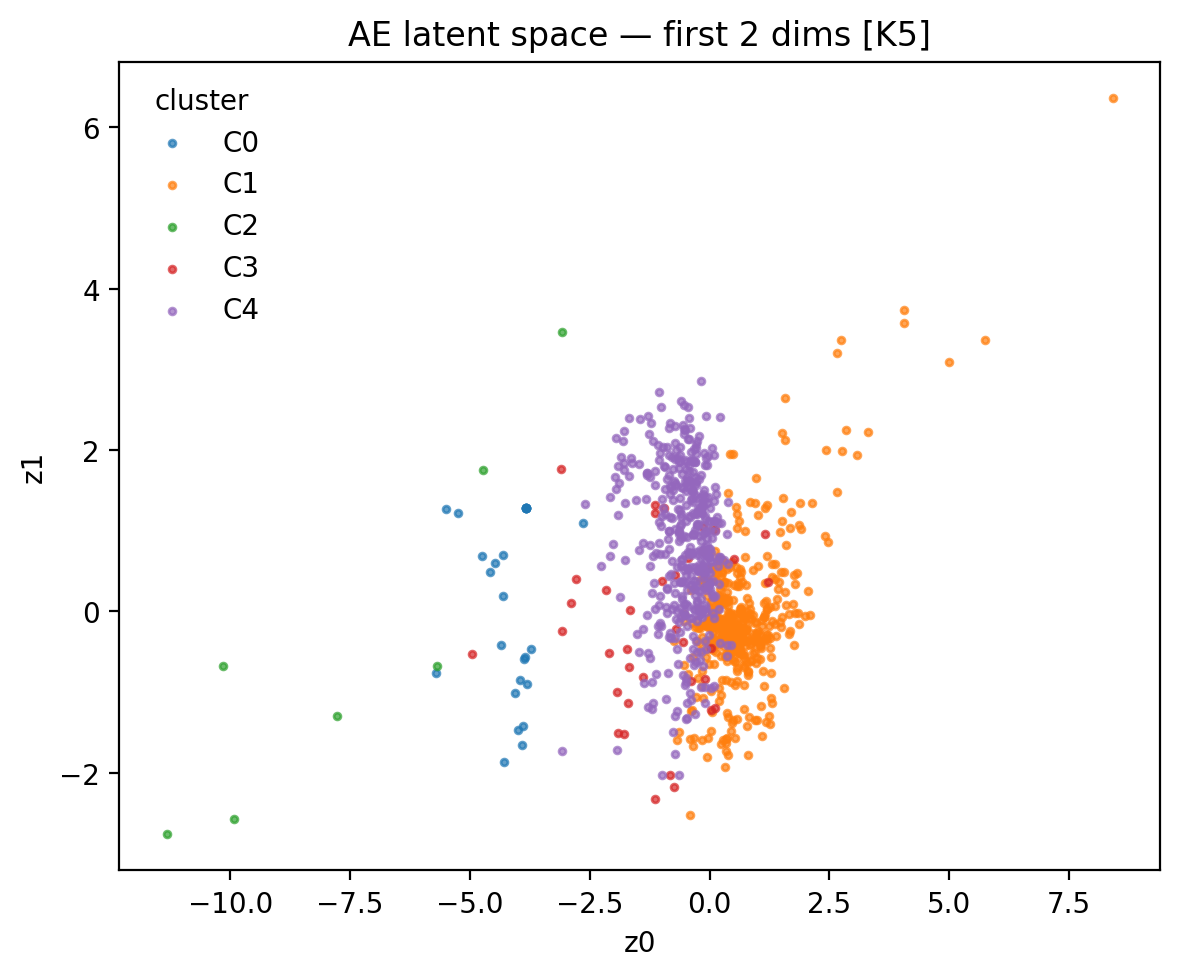

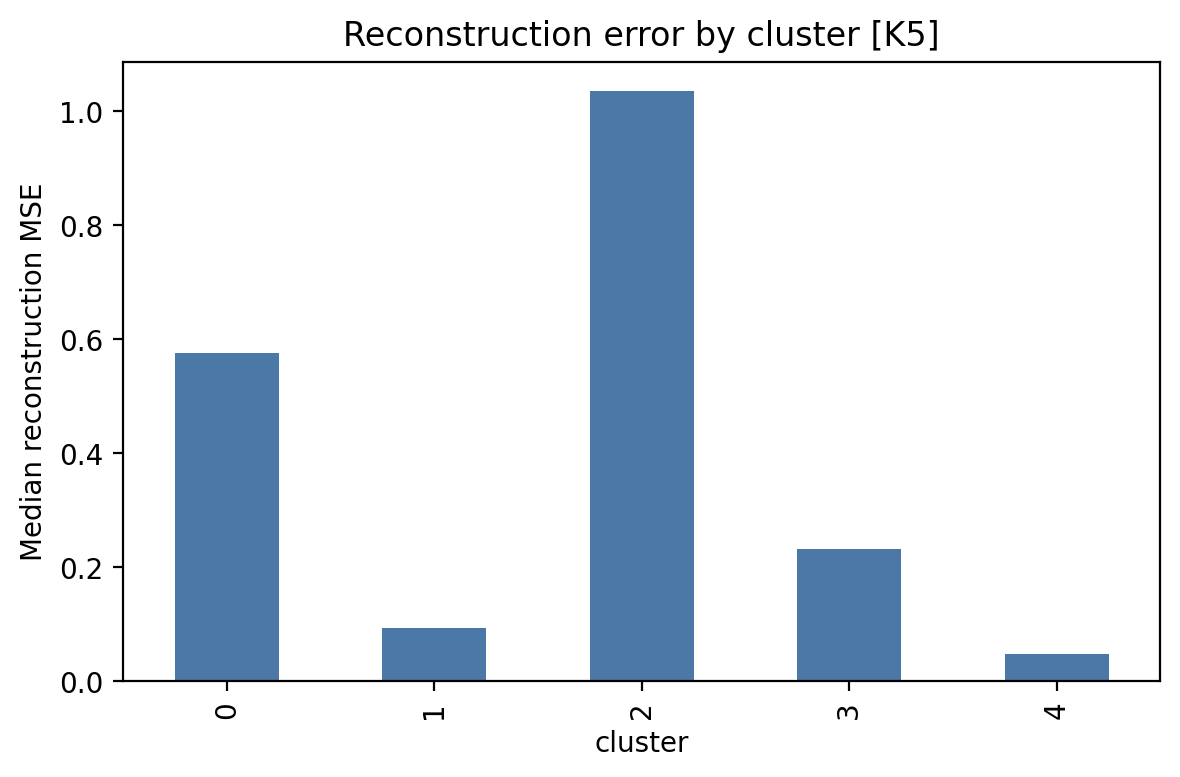

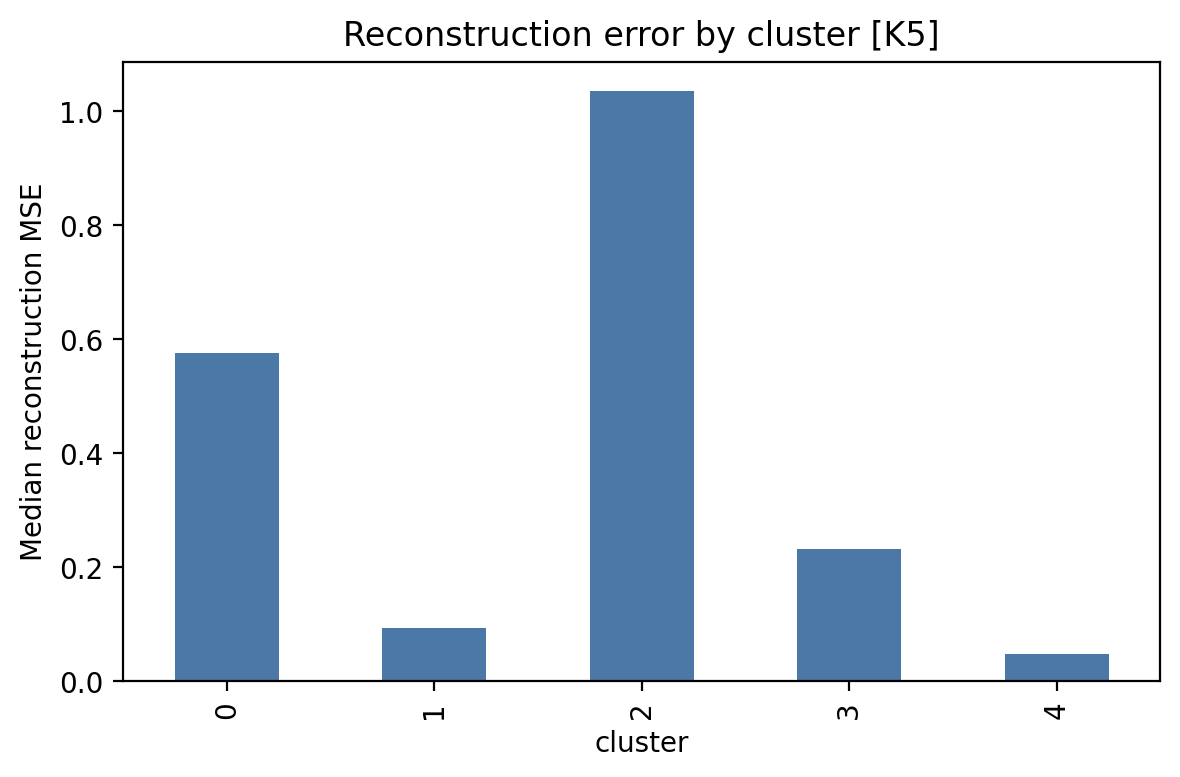

In [21]:
# assicurati, in una cella in alto del notebook:
%matplotlib inline
# (opzionale) migliore qualità:
%config InlineBackend.figure_format = 'retina'

# poi chiami così:
plot_latent_scatter(emb, labels=labels_K5, outdir=FIG_DIR, tag=TAG, show=True, save=True)
plot_error_by_cluster(err, labels=labels_K5, outdir=FIG_DIR, tag=TAG, show=True, save=True)


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import silhouette_score

# ---------- PLOTS ----------

def plot_recon_violin(err: pd.Series, labels: pd.Series,
                      outdir: str, tag: str = "", show: bool = True) -> None:
    """
    Violin/box plot of reconstruction error by cluster.
    Parameters
    ----------
    err : pd.Series
        Reconstruction MSE indexed by user (same index as `labels`).
    labels : pd.Series
        Cluster labels (index aligned with `err`).
    outdir : str
        Output directory for saving the PNG.
    tag : str
        Suffix to add to the figure filename (e.g., 'K5').
    show : bool
        If True, show inline; otherwise only save and close.
    """
    d = pd.DataFrame({"err": err, "cluster": labels}).dropna()
    outdir = Path(outdir); outdir.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(7,4))
    order = sorted(d["cluster"].unique())
    data = [d.loc[d["cluster"]==c, "err"].values for c in order]

    parts = ax.violinplot(data, positions=order, showmeans=False, showextrema=False)
    for pc in parts['bodies']: 
        pc.set_alpha(0.4)
    ax.boxplot(data, positions=order, widths=0.2, showfliers=False)

    ax.set_xlabel("cluster"); ax.set_ylabel("reconstruction MSE")
    ax.set_title(f"Reconstruction error distribution by cluster [{tag}]")
    fig.tight_layout()
    fig.savefig(outdir / f"ae_recon_violin_{tag}.png", dpi=150)
    if show: plt.show()
    else: plt.close(fig)

def plot_recon_hist(err: pd.Series, labels: pd.Series,
                    outdir: str, tag: str = "", show: bool = True) -> None:
    """
    Overlaid histograms of reconstruction error per cluster (semi‑transparent).
    """
    d = pd.DataFrame({"err": err, "cluster": labels}).dropna()
    outdir = Path(outdir); outdir.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(7,4))
    for c in sorted(d["cluster"].unique()):
        vals = d.loc[d["cluster"]==c, "err"].values
        ax.hist(vals, bins=30, alpha=0.35, label=f"C{c}", density=True)
    ax.set_xlabel("reconstruction MSE"); ax.set_ylabel("density")
    ax.set_title(f"Error histograms by cluster [{tag}]")
    ax.legend()
    fig.tight_layout()
    fig.savefig(outdir / f"ae_recon_hist_{tag}.png", dpi=150)
    if show: plt.show()
    else: plt.close(fig)

# ---------- OUTLIERS ----------

def mad_threshold(x: np.ndarray, k: float = 3.5) -> float:
    """
    Robust upper threshold using Median Absolute Deviation (MAD).
    Returns median(x) + k * 1.4826 * MAD.
    """
    x = np.asarray(x, dtype=float)
    med = np.median(x)
    mad = 1.4826 * np.median(np.abs(x - med))
    return med + k * mad

def flag_outliers_by_mad(err: pd.Series, labels: pd.Series | None = None,
                         per_cluster: bool = True, k: float = 3.5) -> pd.DataFrame:
    """
    Flag outliers based on a robust MAD threshold (global or per cluster).

    Returns
    -------
    pd.DataFrame with columns:
        - err : reconstruction MSE
        - cluster : cluster label (if provided)
        - is_outlier : boolean flag
        - thr_used : threshold applied for that row
    """
    d = pd.DataFrame({"err": err})
    if labels is not None:
        d["cluster"] = labels
    else:
        d["cluster"] = "ALL"

    out = []
    for c, g in d.groupby("cluster", observed=True):
        thr = mad_threshold(g["err"].values, k=k) if per_cluster else mad_threshold(d["err"].values, k=k)
        tmp = g.copy()
        tmp["thr_used"] = thr
        tmp["is_outlier"] = tmp["err"] > thr
        out.append(tmp)
    out = pd.concat(out).sort_values("err", ascending=False)
    return out

# ---------- SILHOUETTE (già fatto, ma comodo a colpo d’occhio) ----------

def silhouette_in_latent(emb: pd.DataFrame, labels: pd.Series) -> float:
    """
    Silhouette score of provided labels in latent space.
    """
    X = emb.values
    y = labels.values
    return float(silhouette_score(X, y))


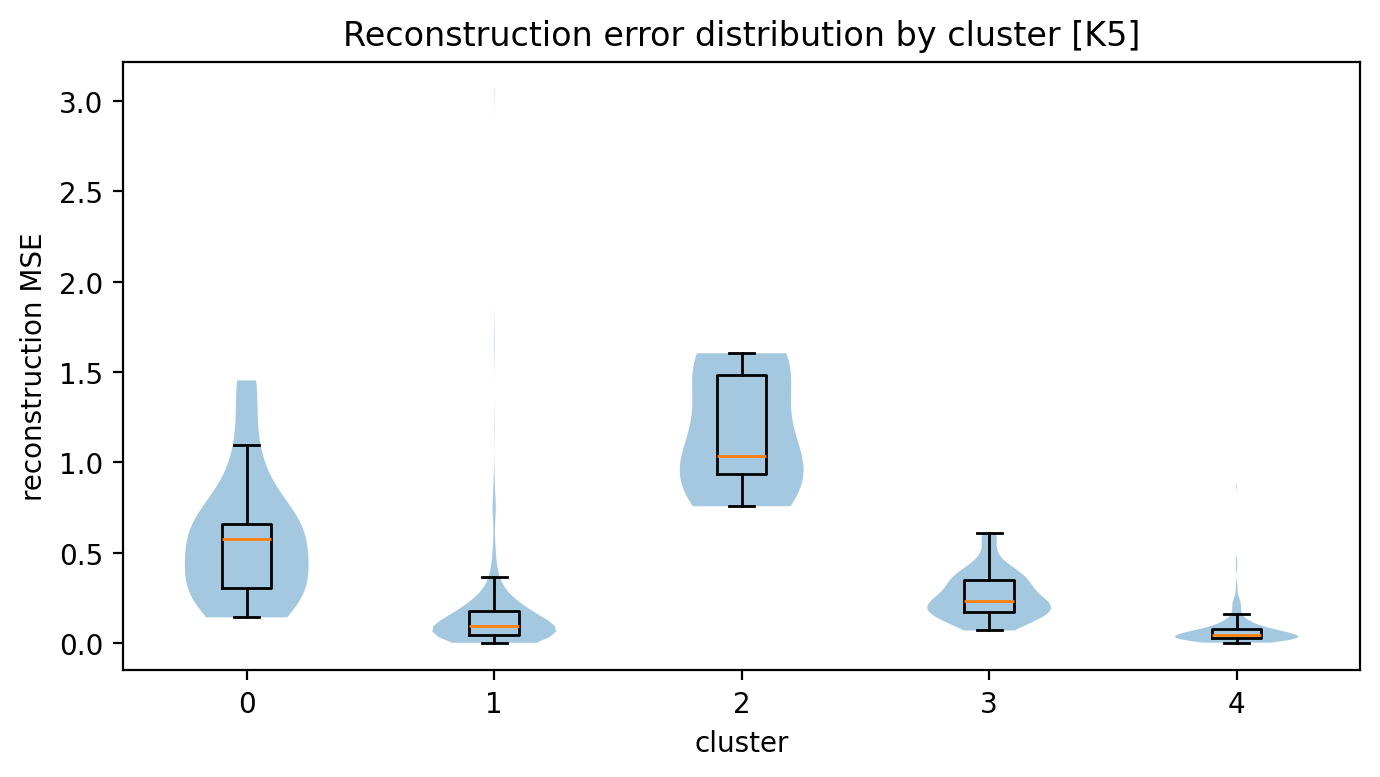

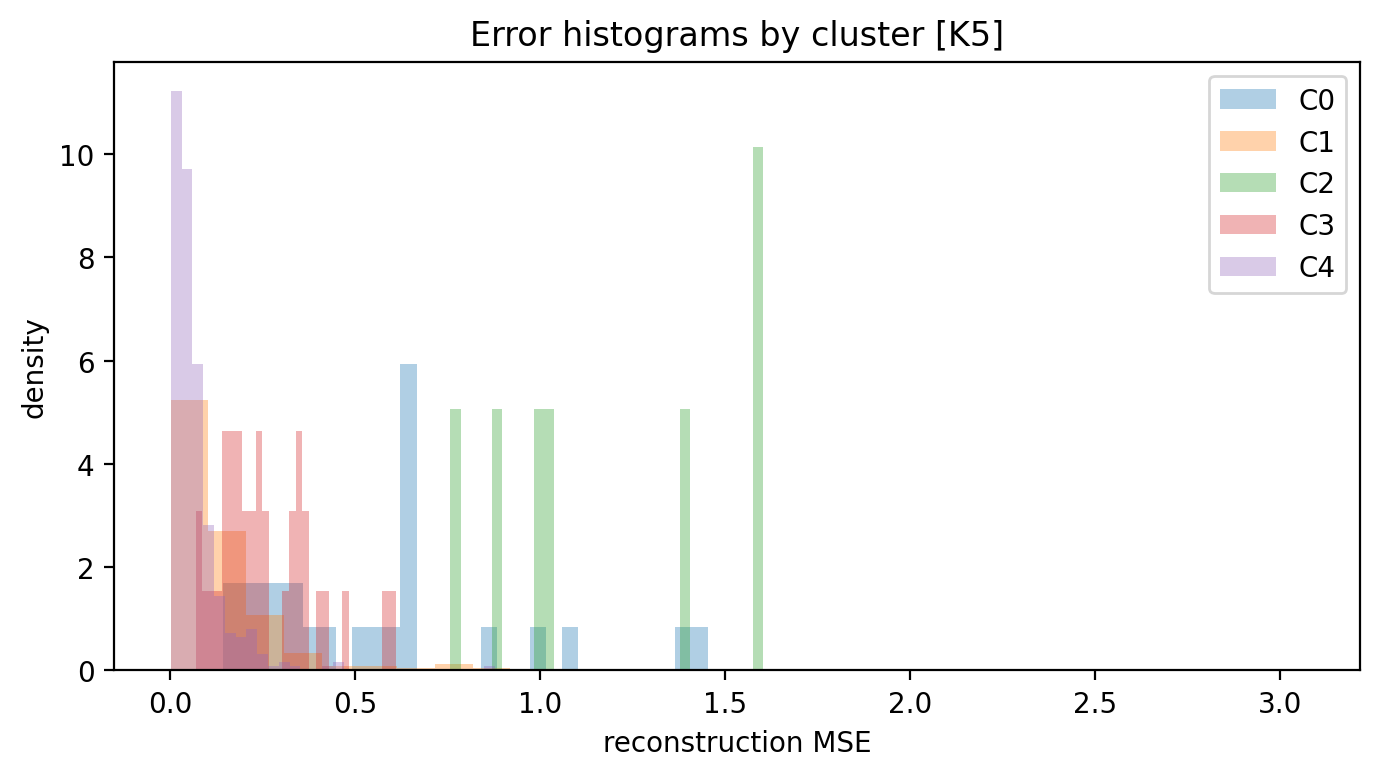

                   err  cluster  thr_used  is_outlier
ca_number                                            
60005527688   3.063478        1  0.372593        True
60027045768   1.710578        1  0.372593        True
60008890471   1.611924        1  0.372593        True
60012217166   1.202044        1  0.372593        True
60010983678   0.925186        1  0.372593        True
900000992030  0.878579        4  0.180067        True
60001600687   0.870020        1  0.372593        True
900001166819  0.835486        1  0.372593        True
900000821122  0.779669        1  0.372593        True
60000288526   0.768688        1  0.372593        True
60020950683   0.752875        1  0.372593        True
60002055758   0.747669        1  0.372593        True
60026114102   0.733695        1  0.372593        True
60011825134   0.725545        1  0.372593        True
60000841936   0.711920        1  0.372593        True
900001163461  0.690521        1  0.372593        True
60001794217   0.557831      

In [23]:
FIG_DIR = "artifacts/ae_figs"
TAG = "K5"

# 1) Distribuzioni e istogrammi errori
plot_recon_violin(err, labels_K5, outdir=FIG_DIR, tag=TAG, show=True)
plot_recon_hist(err, labels_K5, outdir=FIG_DIR, tag=TAG, show=True)

# 2) Outlier (MAD per cluster)
out = flag_outliers_by_mad(err, labels_K5, per_cluster=True, k=3.5)
top_out = out[out["is_outlier"]].head(20)   # i 20 più anomali
print(top_out[["err","cluster","thr_used","is_outlier"]])

# (opzionale) soglia globale più severa
out_global = flag_outliers_by_mad(err, labels_K5, per_cluster=False, k=3.5)


## 9) Where‑to‑Act (Priority Matrix)

We combine **opportunity** (higher reward rate) and **stability** (lower override).  
After robust [0,1] normalization (e.g., 10th–90th percentiles), a penalty can be applied:  
\( \gamma \) penalizes high overrides; \( \delta \) penalizes high **AE risk** (normalized MSE).  
The heatmap (and optional bubble chart) ranks clusters for action.


In [24]:

# --- robust scaler: mappa in [0,1] usando i quantili (default 10% - 90%)
def robust_minmax(s: pd.Series, qlow=0.10, qhigh=0.90):
    lo, hi = s.quantile([qlow, qhigh])
    return ((s - lo) / (hi - lo)).clip(0, 1)

def build_where_to_act(per_user: pd.DataFrame,
                       labels: pd.Series,
                       metrics=("override_given_event", "reward_rate_mean_event", "pr_auc"),
                       outdir="artifacts/where_to_act",
                       tag="K5",
                       cmap="RdYlGn_r"):
    """
    Crea la matrice 'Where to act' (heatmap + tabella HTML).
    - per_user: DataFrame a livello utente (index = ca_number) con le colonne metriche richieste
    - labels:   pd.Series (index=ca_number, values=cluster)
    - metrics:  tuple di metriche candidate; quelle assenti vengono ignorate
    - outdir:   cartella dove salvare PNG/HTML
    - tag:      etichetta per i file (es. 'K5')
    Ritorna: (df_mediani, df_norm, df_priority)
    """
    outdir = Path(outdir); outdir.mkdir(parents=True, exist_ok=True)

    # mantieni solo metriche presenti
    metrics = [m for m in metrics if m in per_user.columns]
    if not metrics:
        raise ValueError("Nessuna metrica richiesta trovata in per_user.columns")

    # join e mediana per cluster
    df = per_user.join(labels.rename("cluster"), how="inner")
    df_med = df.groupby("cluster")[metrics].median().sort_index()

    # normalizzazione "opportunity" per colonna
    # direzione: - override alto = 'male' (priorità ↑)
    #            - reward_rate alto = 'bene' (ma aumenta la convenienza → priorità ↑)
    #            - pr_auc alto = 'bene' (modulatore di fattibilità → priorità ↑)
    df_norm = pd.DataFrame(index=df_med.index)
    for m in metrics:
        scaled = robust_minmax(df_med[m])
        if m == "override_given_event":
            # override alto = problema ⇒ mantengo 'alto = rosso'
            df_norm[m] = scaled
        else:
            # reward/pr_auc alti aumentano l'opportunità ⇒ li teniamo "alti = rosso"
            df_norm[m] = scaled

    # Priority score: prodotto pesato dei driver disponibili
    # - se manca pr_auc, non entra nel prodotto (peso 1)
    cols_for_priority = [c for c in ["override_given_event", "reward_rate_mean_event", "pr_auc"] if c in df_norm.columns]
    df_priority = pd.DataFrame(index=df_norm.index)
    df_priority["priority"] = df_norm[cols_for_priority].prod(axis=1)
    df_priority = df_priority.sort_values("priority", ascending=False)

    # --- Heatmap (colore = alto → rosso = 'dove agire')
    plt.close("all")
    fig, ax = plt.subplots(1, 1, figsize=(8, 4 + 0.2*len(df_norm)))
    hm = sns.heatmap(df_norm.loc[df_priority.index], annot=df_med.loc[df_priority.index].round(3),
                     fmt="", cmap=cmap, cbar=True, linewidths=.5, linecolor='white',
                     ax=ax, vmin=0, vmax=1)
    ax.set_title(f"Where to act — normalized opportunity (medians annotated) [{tag}]")
    ax.set_xlabel("Key metrics")
    ax.set_ylabel("Cluster (sorted by priority)")
    fig.tight_layout()
    figpath = outdir / f"where_to_act_heatmap_{tag}.png"
    fig.savefig(figpath, dpi=200, bbox_inches="tight")

    # --- Tabella stilizzata per il report (HTML)
    styled = (df_med.loc[df_priority.index]
              .assign(priority=df_priority["priority"])
              .style
              .background_gradient(axis=None, cmap=cmap, subset=metrics)
              .bar(subset=["priority"], color="#d62728")  # barre sulla priority
              .format("{:.3f}"))
    htmlpath = outdir / f"where_to_act_table_{tag}.html"
    styled.to_html(htmlpath)

    print(f"[Where-to-act] Saved: {figpath}")
    print(f"[Where-to-act] Saved: {htmlpath}")
    return df_med, df_norm, df_priority


[Where-to-act] Saved: artifacts/where_to_act_K5/where_to_act_heatmap_K5.png
[Where-to-act] Saved: artifacts/where_to_act_K5/where_to_act_table_K5.html


,override_given_event,reward_rate_mean_event,priority
cluster,,,
0,0.000,18.000,0.000
1,0.030,17.863,0.771
2,0.000,17.324,0.000
3,0.002,17.724,0.044
4,0.016,17.938,0.614


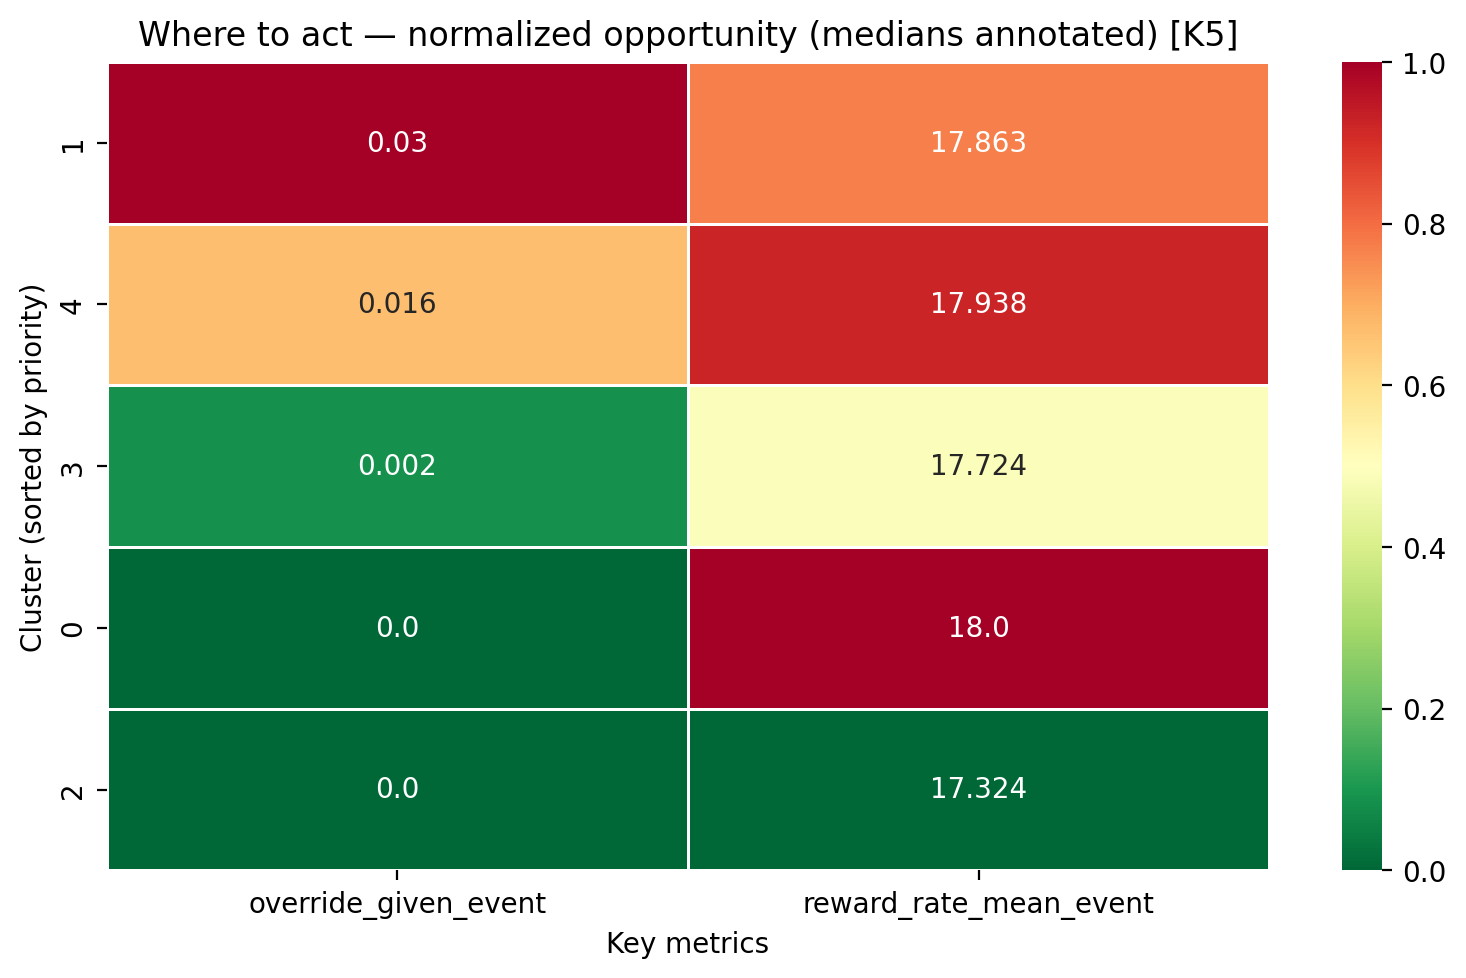

In [30]:
from pathlib import Path

# Supponiamo di avere:
# - labels_K5 : pd.Series (index=ca_number, values=0..4)
# - prof_K5   : dict con 'per_user' già costruito nel tuo notebook di profilazione

# Seleziona (quando presenti) le metriche chiave per utente
cols = [c for c in ["override_given_event", "reward_rate_mean_event", "pr_auc"] 
        if c in prof_K5["per_user"].columns]
per_user = prof_K5["per_user"][cols].copy()

# Esegui la matrice "Where to act"
OUTDIR = "artifacts/where_to_act_K5"
df_med, df_norm, df_priority = build_where_to_act(per_user, labels_K5,
                                                  metrics=("override_given_event","reward_rate_mean_event","pr_auc"),
                                                  outdir=OUTDIR, tag="K5")

# Mostra anche la tabella in notebook (opzionale)
display(df_med.assign(priority=df_priority["priority"]).round(3))


In [39]:
    # --- 0) Prerequisiti: devono già esistere df_switch_transformed, labels_K5, emb, err ---
    # labels_K5: pd.Series index=ca_number, values=cluster (K=5)
    # emb/err: dall’AE (embeddings e recon_mse) – se non li hai, ricaricali dai Parquet salvati.
    
    from pathlib import Path
    
    # --- 1) Costruisci overlay a livello utente/evento e aggancia i cluster ---
    # (ri-eseguo in modo idempotente; se avevi già ov non fa danni)
    tmp = add_event_flags_powbal(df_switch_transformed)          # flags coerenti
    ov  = build_powbal_overlay(df_switch_transformed)            # overlay per utente
    
    # unisci le etichette dei cluster: se ov ha index = ca_number il join è diretto
    if ov.index.name == "ca_number":
        ov = ov.join(labels_K5.rename("cluster"))
    else:
        # se ca_number è colonna e non index
        ov = ov.merge(labels_K5.rename("cluster"),
                      left_on="ca_number", right_index=True, how="left")
    
    # --- 2) Mediane “chiave” per cluster (override e reward) ---
    metrics = (
        ov.groupby("cluster", observed=True)
          .agg(
              override_given_event    = ("override_given_event",    "median"),
              reward_rate_mean_event  = ("reward_rate_mean_event",  "median"),
          )
          .sort_index()
    )
    
    # --- 3) (Opzionale) rischio AE: MSE mediano per cluster ---
    # Se df_qc non esiste lo creo qui (AE embeddings + recon_mse + cluster)
    try:
        df_qc
    except NameError:
        df_qc = emb.join(err).join(labels_K5.rename("cluster"))
    
    ae_cluster_err = (
        df_qc.groupby("cluster", observed=True)["recon_mse"]
             .median()
             .reindex(metrics.index)   # allineo gli indici ai cluster di 'metrics'
    )
    
    # --- 4) Tabella & heatmap penalizzata ---
    OUTDIR = Path("artifacts/where_to_act_K5")
    tab_pen = where_to_act_penalized(
        metrics       = metrics,
        ae_err        = ae_cluster_err,     # oppure None se vuoi solo la penalità override
        outdir        = OUTDIR,
        tag           = "K5",
        gamma         = 2.0,                # penalità più severa sugli override
        delta         = 0.30,               # peso 'rischio AE' (metti 0.0 per spegnerlo)
    )
    
    display(tab_pen.round(3))  # comodo a video


[Where-to-act] Saved: artifacts/where_to_act_K5/where_to_act_heatmap_K5.png
[Where-to-act] Saved: artifacts/where_to_act_K5/where_to_act_table_K5.html


,override_given_event,reward_rate_mean_event,priority
cluster,,,
0,0.000,18.000,0.768
3,0.002,17.724,0.434
4,0.016,17.938,0.148
1,0.030,17.863,0.000
2,0.000,17.324,0.000


In [40]:
def _minmax(x):
    x = x.astype(float)
    lo, hi = x.min(), x.max()
    return (x - lo) / (hi - lo + 1e-9)

def plot_where_to_act(tab_pen: pd.DataFrame,
                      outdir: str | Path = "artifacts/where_to_act_K5",
                      tag: str = "K5",
                      ae_cluster_err: pd.Series | None = None,
                      gamma: float = 2.0,
                      delta: float = 0.30):
    """
    Make two report-quality visuals for the penalised 'where to act' table:
      (1) Normalised heatmap (clusters sorted by priority)
      (2) Opportunity vs. Stability bubble chart

    Parameters
    ----------
    tab_pen : DataFrame returned by where_to_act_penalized(...).
              Must contain columns:
              ['override_given_event','reward_rate_mean_event','priority'].
    outdir : folder where figures will be saved.
    tag    : label appended to filenames and titles (e.g., 'K5').
    ae_cluster_err : optional Series with AE median recon MSE per cluster (index aligned).
    gamma, delta   : penalties used (override, AE risk) – shown in figure subtitle.
    """

    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    # work on a copy
    T = tab_pen.copy()
    T.index.name = "cluster"

    # Normalisations for plotting
    T["override_norm"] = _minmax(T["override_given_event"])
    T["reward_norm"]   = _minmax(T["reward_rate_mean_event"])
    T["priority_norm"] = T["priority"] / (T["priority"].max() + 1e-12)

    if ae_cluster_err is not None:
        T["ae_mse"]    = ae_cluster_err.reindex(T.index)
        T["ae_norm"]   = _minmax(T["ae_mse"])
    else:
        T["ae_norm"]   = np.nan  # not available

    # Sort by priority (highest first)
    T = T.sort_values("priority", ascending=False)

    # -------------------------
    # (1) Normalised heatmap
    # -------------------------
    hm = T[["override_norm", "reward_norm"]].copy()
    hm.columns = ["Override (norm ↑ = higher)", "Reward rate (norm ↑ = higher)"]

    # annotate with the original medians to keep the numbers
    annot = T[["override_given_event", "reward_rate_mean_event"]].round(3).values

    plt.figure(figsize=(7.2, 5.0), dpi=150)
    ax = sns.heatmap(hm,
                     cmap="YlOrRd",
                     annot=annot,
                     fmt="",
                     cbar_kws={"label": "Normalised value (0‑1)"},
                     linewidths=0.6, linecolor="white")
    ax.set_title(f"Where to act — normalised opportunity (medians annotated) [{tag}]",
                 fontsize=12, pad=10)
    ax.set_xlabel("Key metrics"); ax.set_ylabel("Cluster (sorted by priority)")
    # small subtitle with penalties
    plt.suptitle(f"Penalties: γ (override) = {gamma}, δ (AE risk) = {delta}",
                 y=0.94, fontsize=9, color="dimgray")

    f1_png = outdir / f"where_to_act_heatmap_{tag}.png"
    f1_pdf = outdir / f"where_to_act_heatmap_{tag}.pdf"
    plt.tight_layout(); plt.savefig(f1_png, dpi=300); plt.savefig(f1_pdf); plt.show()

    # ---------------------------------------
    # (2) Opportunity vs Stability bubble map
    # ---------------------------------------
    # x: reward (normalised)
    # y: stability = 1 - override_norm (higher is better)
    # size: priority_norm
    # colour: AE risk (if available) else override_norm
    T["stability"] = 1.0 - T["override_norm"]
    bubble_color   = T["ae_norm"] if T["ae_norm"].notna().any() else T["override_norm"]
    color_label    = "AE risk (norm)" if T["ae_norm"].notna().any() else "Override (norm)"

    plt.figure(figsize=(7.8, 5.2), dpi=150)
    sc = plt.scatter(T["reward_norm"], T["stability"],
                     s=200*(0.35 + T["priority_norm"]),  # keep all visible
                     c=bubble_color, cmap="RdYlGn_r", edgecolor="k", alpha=0.90)
    for cid, r in T.iterrows():
        plt.text(r["reward_norm"]+0.01, r["stability"]+0.01,
                 f"C{cid}", fontsize=9, weight="bold")

    cbar = plt.colorbar(sc); cbar.set_label(color_label)
    plt.xlabel("Opportunity: reward rate (normalised)")
    plt.ylabel("Stability: 1 − override (normalised)")
    plt.title(f"Opportunity vs Stability — bubble size = priority [{tag}]")
    plt.grid(alpha=0.25)

    f2_png = outdir / f"where_to_act_bubble_{tag}.png"
    f2_pdf = outdir / f"where_to_act_bubble_{tag}.pdf"
    plt.tight_layout(); plt.savefig(f2_png, dpi=300); plt.savefig(f2_pdf); plt.show()

    print(f"[Where‑to‑act] Saved: {f1_png}, {f1_pdf}, {f2_png}, {f2_pdf}")

# --- Usage (with your existing variables)
plot_where_to_act(tab_pen, outdir="artifacts/where_to_act_K5", tag="K5",
                   ae_cluster_err=ae_cluster_err, gamma=2.0, delta=0.30)


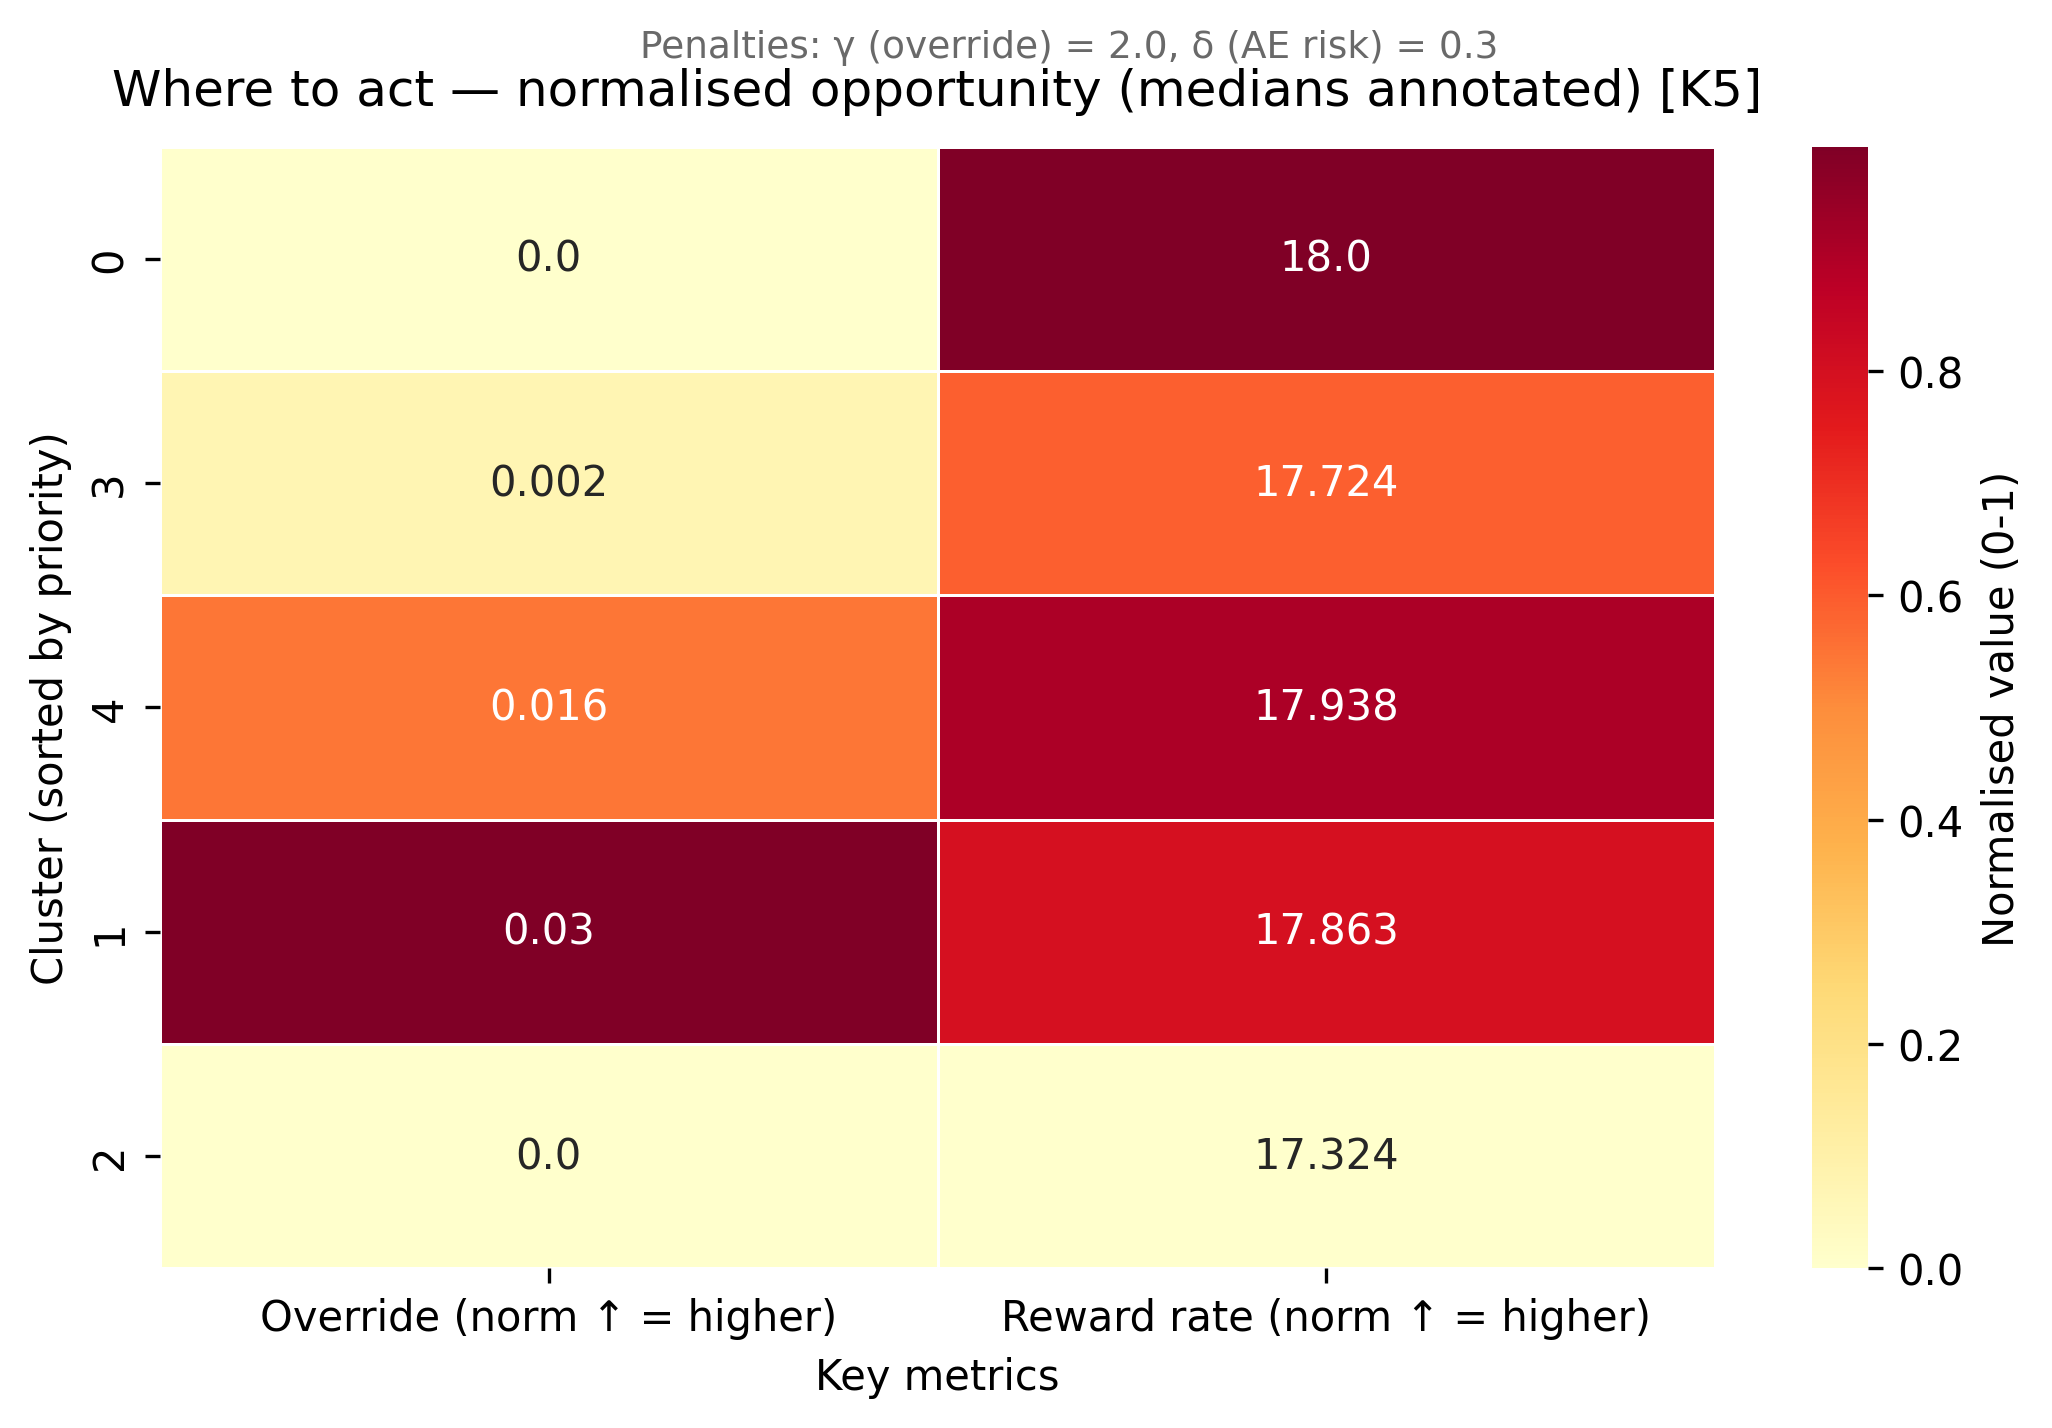

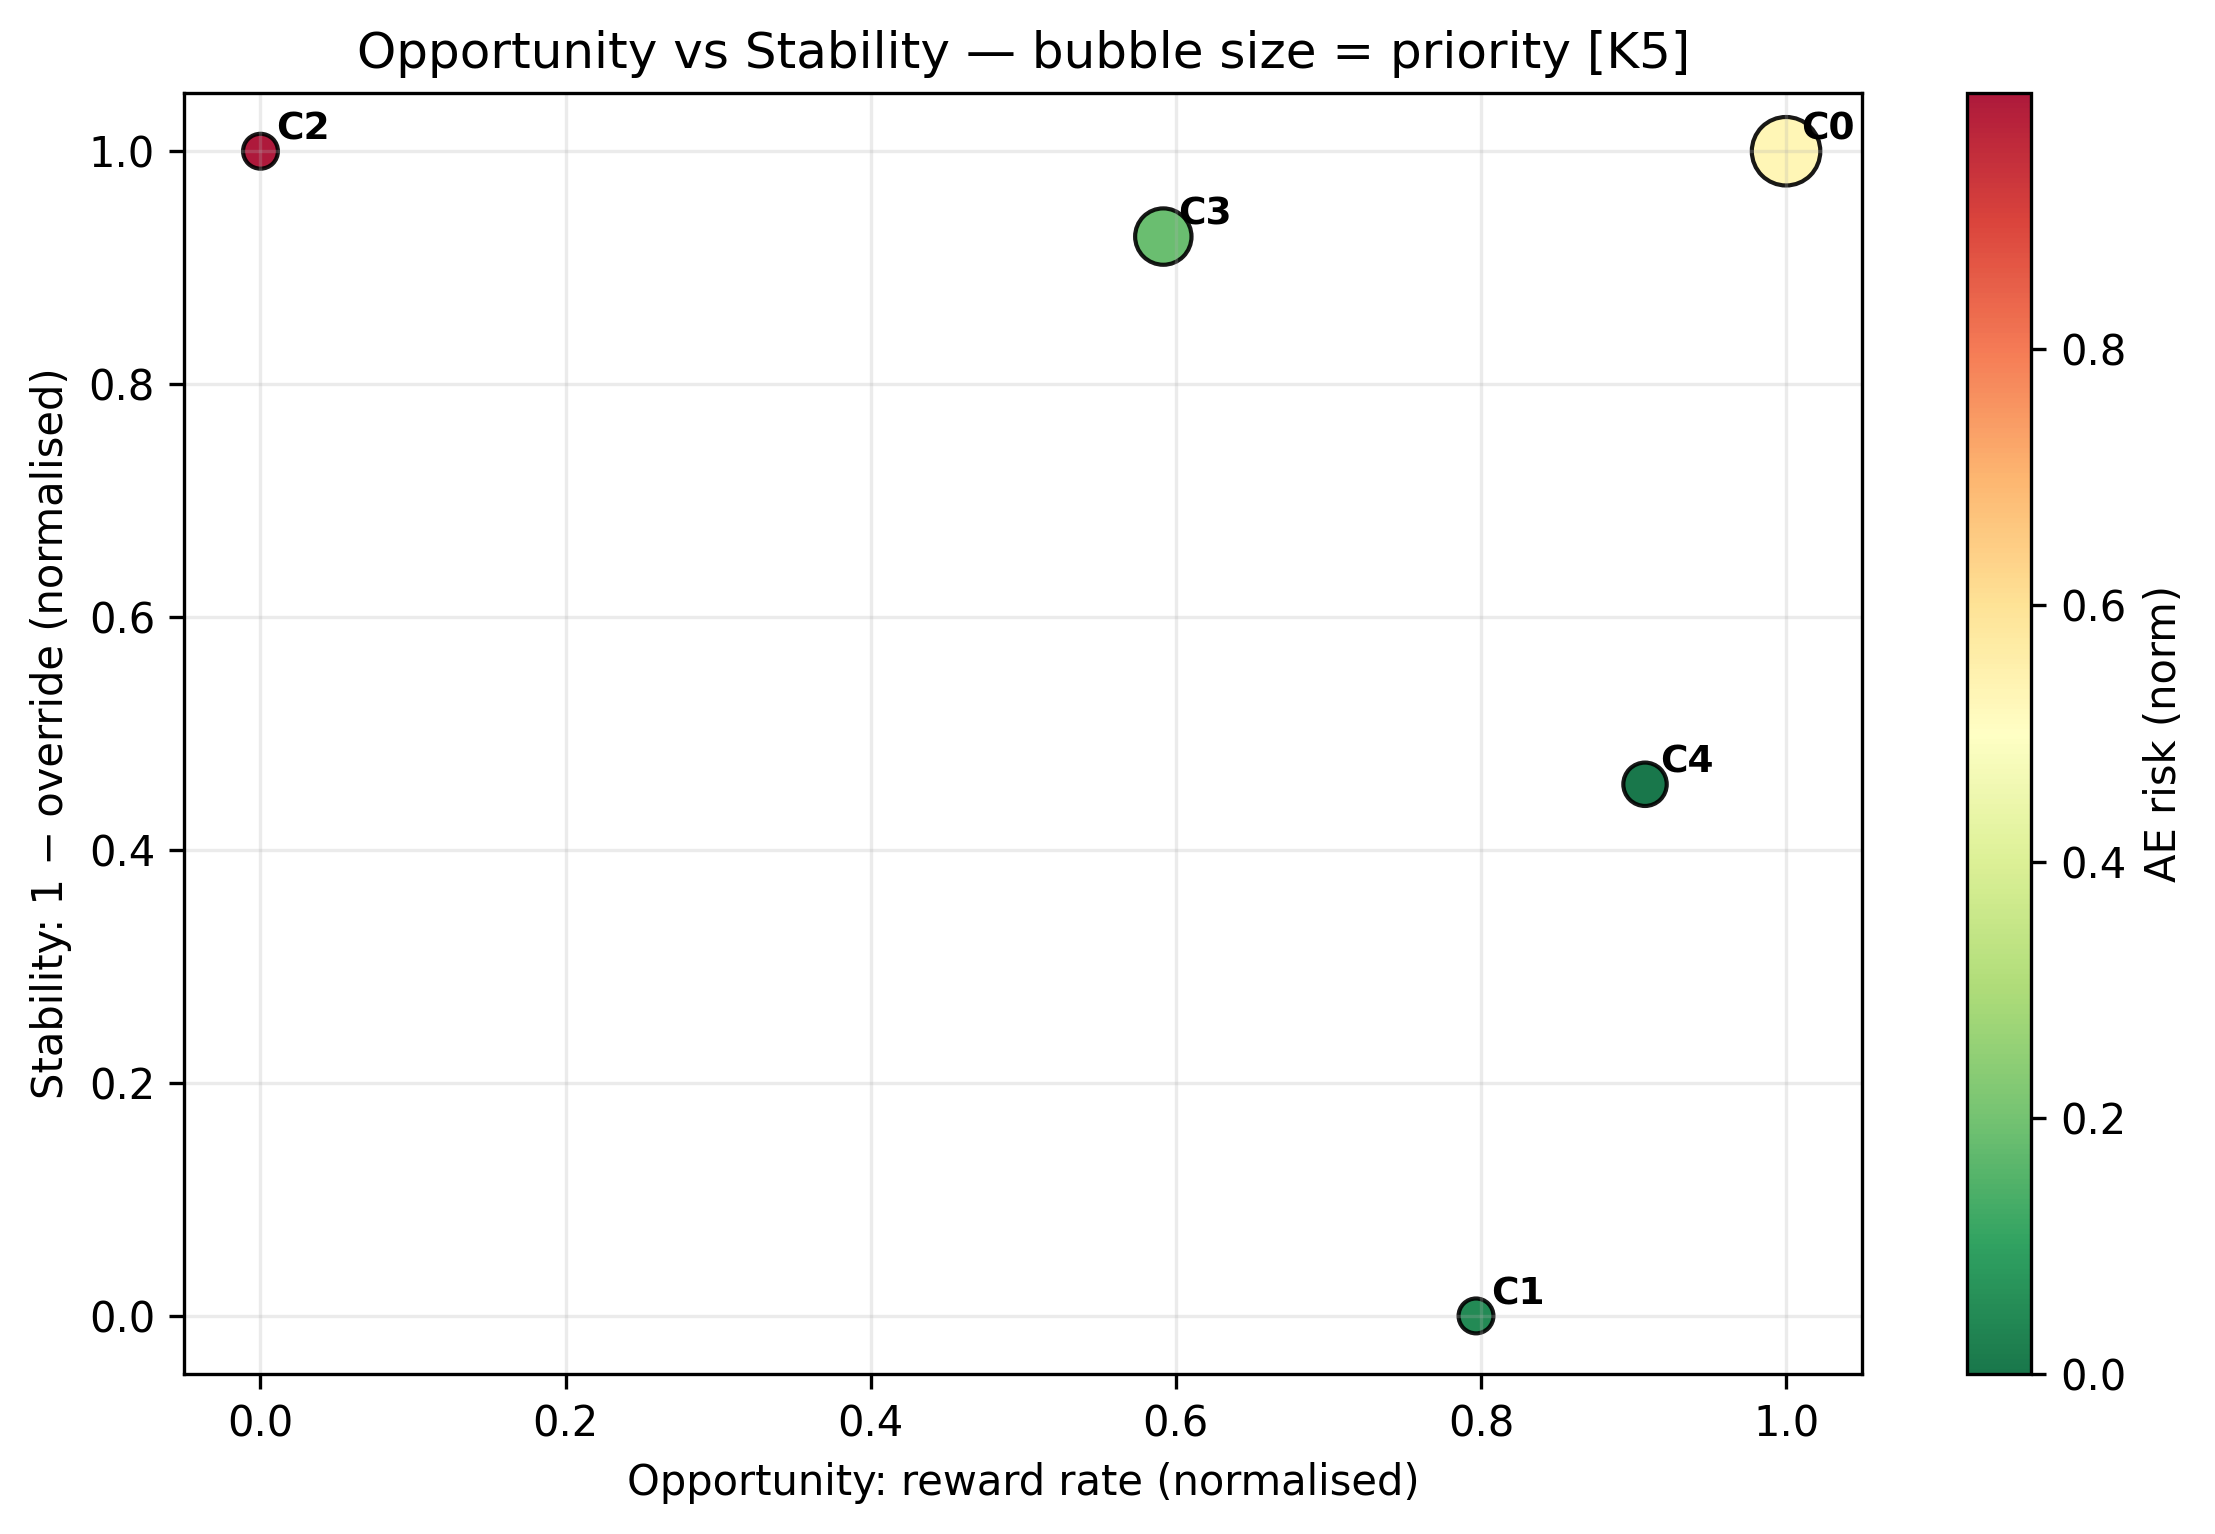

[Where‑to‑act] Saved: artifacts/where_to_act_K5/where_to_act_heatmap_K5.png, artifacts/where_to_act_K5/where_to_act_heatmap_K5.pdf, artifacts/where_to_act_K5/where_to_act_bubble_K5.png, artifacts/where_to_act_K5/where_to_act_bubble_K5.pdf


In [41]:
plot_where_to_act(tab_pen, outdir="artifacts/where_to_act_K5", tag="K5",
                   ae_cluster_err=ae_cluster_err, gamma=2.0, delta=0.30)

In [36]:
    # PNG EXPORT PACK 
    
    
    # ---------- util ----------
    
    def _savefig(fig, path, dpi=300):
        Path(path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(path, dpi=dpi, bbox_inches="tight")
        plt.close(fig)
    
    def _ensure_labels_k5(labels=None, path="artifacts/clustering_behavior_K5/labels_K5.parquet"):
        if labels is not None:
            return labels
        lab = pd.read_parquet(path)["cluster"]
        lab.name = "cluster"
        return lab
    
    def _ensure_ae_tables(emb=None, err=None, tag="K5", ae_dir="artifacts/ae_K5"):
        if emb is None:
            emb = pd.read_parquet(Path(ae_dir)/"tables"/f"embeddings_{tag}.parquet")
        if err is None:
            err = pd.read_parquet(Path(ae_dir)/"tables"/f"recon_error_{tag}.parquet")["recon_mse"]
        return emb, err
    
    # ---------- plots AE ----------
    
    def plot_ae_latent_png(emb, labels, outdir, tag="K5"):
        fig, ax = plt.subplots(figsize=(6,6))
        for c in sorted(labels.unique()):
            sel = labels.eq(c)
            ax.scatter(emb.loc[sel, "z0"], emb.loc[sel, "z1"], s=12, alpha=0.8, label=f"C{c}")
        ax.set_xlabel("z0"); ax.set_ylabel("z1")
        ax.set_title(f"AE latent space — first 2 dims [{tag}]")
        ax.legend(title="cluster")
        _savefig(fig, Path(outdir)/f"ae_latent_{tag}.png")
    
    def plot_err_median_by_cluster_png(err, labels, outdir, tag="K5"):
        med = pd.DataFrame({"err": err, "cluster": labels}).groupby("cluster")["err"].median()
        fig, ax = plt.subplots(figsize=(6,4))
        ax.bar(med.index.astype(str), med.values)
        ax.set_xlabel("cluster"); ax.set_ylabel("Median reconstruction MSE")
        ax.set_title(f"Reconstruction error by cluster [{tag}]")
        _savefig(fig, Path(outdir)/f"ae_error_median_by_cluster_{tag}.png")
    
    def plot_err_violin_png(err, labels, outdir, tag="K5"):
        df = pd.DataFrame({"err": err, "cluster": labels})
        order = sorted(df["cluster"].unique())
        data = [df.loc[df["cluster"].eq(c),"err"].values for c in order]
        fig, ax = plt.subplots(figsize=(7,4))
        parts = ax.violinplot(data, positions=np.arange(len(order)), showmeans=False, showmedians=True)
        # overlay small box‑like quartiles
        for i, arr in enumerate(data):
            q1, med, q3 = np.quantile(arr, [0.25,0.5,0.75])
            ax.plot([i-0.2,i+0.2],[med,med], color="k", lw=2)
            ax.plot([i,i],[q1,q3], color="k", lw=2)
        ax.set_xticks(np.arange(len(order))); ax.set_xticklabels([str(c) for c in order])
        ax.set_xlabel("cluster"); ax.set_ylabel("reconstruction MSE")
        ax.set_title(f"Reconstruction error distribution by cluster [{tag}]")
        _savefig(fig, Path(outdir)/f"ae_error_violin_{tag}.png")
    
    # ---------- where‑to‑act ----------
    
    def _normalize_01(x):
        x = x.astype(float)
        rng = x.max() - x.min()
        return (x - x.min())/(rng + 1e-9)
    
    def compute_where_to_act_matrix(overlay_df, labels):
        """
        overlay_df deve avere indice=ca_number e colonne:
          ['override_given_event', 'reward_rate_mean_event']
        """
        m = overlay_df.join(labels.rename("cluster")).groupby("cluster")[["override_given_event","reward_rate_mean_event"]].median()
        # normalizza per heatmap + priorità
        m_norm = m.copy()
        m_norm["override_given_event"]   = _normalize_01(m["override_given_event"])
        m_norm["reward_rate_mean_event"] = _normalize_01(m["reward_rate_mean_event"])
        # priorità: alta override e reward basso => opportunità maggiore
        m["priority"] = m_norm["override_given_event"]*(1.0 - m_norm["reward_rate_mean_event"])
        m["priority"] = m["priority"].round(3)
        return m, m_norm
    
    def plot_where_to_act_heatmap_png(matrix_norm, matrix_raw, outdir, tag="K5"):
        # ordina per priorità (calcolata su matrix_raw)
        order = matrix_raw["priority"].sort_values(ascending=False).index.tolist()
        A = matrix_norm.loc[order, ["override_given_event","reward_rate_mean_event"]].values
    
        fig, ax = plt.subplots(figsize=(7,5))
        im = ax.imshow(A, cmap="RdYlGn_r", vmin=0, vmax=1)
        ax.set_yticks(np.arange(len(order))); ax.set_yticklabels([str(c) for c in order])
        ax.set_xticks([0,1]); ax.set_xticklabels(["override_given_event","reward_rate_mean_event"])
        ax.set_ylabel("Cluster (sorted by priority)")
        ax.set_title(f"Where to act — normalized opportunity (medians annotated) [{tag}]")
        # annotazioni con le mediane reali
        for i,r in enumerate(order):
            ax.text(0, i, f"{matrix_raw.loc[r,'override_given_event']:.3f}", ha="center", va="center", color="white")
            ax.text(1, i, f"{matrix_raw.loc[r,'reward_rate_mean_event']:.3f}", ha="center", va="center", color="black")
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("normalized scale (0–1)")
        _savefig(fig, Path(outdir)/f"where_to_act_heatmap_{tag}.png")
    
    def table_to_png(df, path, title=None, fmt="{:.3f}"):
        fig, ax = plt.subplots(figsize=(6, 0.6+0.45*len(df)))
        ax.axis("off")
        tbl = ax.table(cellText=[[fmt.format(v) if isinstance(v,(int,float,np.floating)) else v for v in row]
                                 for row in df.values],
                       rowLabels=[str(i) for i in df.index],
                       colLabels=list(df.columns),
                       loc="center")
        tbl.auto_set_font_size(False); tbl.set_fontsize(9)
        tbl.scale(1, 1.25)
        if title: ax.set_title(title, pad=12)
        _savefig(fig, path)
    
    # ---------- pack ----------
    
    def export_report_pngs(labels_K5=None,
                           emb=None, err=None,
                           overlay_df=None,   # opzionale: se None, lo ricalcoli tu prima
                           outdir="artifacts/report_png_K5",
                           tag="K5"):
        outdir = Path(outdir); outdir.mkdir(parents=True, exist_ok=True)
        labels = _ensure_labels_k5(labels_K5)
        emb, err = _ensure_ae_tables(emb, err, tag=tag, ae_dir="artifacts/ae_K5")
    
        # AE
        plot_ae_latent_png(emb, labels, outdir, tag=tag)
        plot_err_median_by_cluster_png(err, labels, outdir, tag=tag)
        plot_err_violin_png(err, labels, outdir, tag=tag)
    
        # Where‑to‑act (richiede overlay_df già costruito)
        if overlay_df is not None:
            M_raw, M_norm = compute_where_to_act_matrix(overlay_df, labels)
            # heatmap
            plot_where_to_act_heatmap_png(M_norm, M_raw, outdir, tag=tag)
            # tabella PNG
            table_to_png(M_raw.round(3),
                         outdir / f"where_to_act_table_{tag}.png",
                         title=f"Where‑to‑act — medians & priority [{tag}]")
            print(M_raw.round(3))
    
        print(f"[PNG pack] Saved in: {outdir.resolve()}")


In [34]:
# 1) Se hai già emb/err salvati da AE e labels_K5 su disco:
#    (altrimenti passali direttamente come argomenti)

# Overlay per la “Where‑to‑act” (se vuoi includere anche le due PNG della matrice/tabella)
# overlay_df deve avere indice = ca_number e colonne:
#   ['override_given_event', 'reward_rate_mean_event']
# Se l’hai già calcolato: overlay_df = ov
# Altrimenti, ricalcolalo come fai nel notebook (build_powbal_overlay(...)).

export_report_pngs(
    labels_K5=None,                    # se None, legge artifacts/clustering_behavior_K5/labels_K5.parquet
    emb=None, err=None,                # se None, legge artifacts/ae_K5/tables/*_K5.parquet
    overlay_df=ov,                     # opzionale: se non lo passi, salta la parte Where‑to‑act
    outdir="artifacts/report_png_K5",
    tag="K5"
)


NameError: name 'ov' is not defined

In [35]:
# 1) (se serve) aggiungi i flag evento
tmp = add_event_flags_powbal(df_switch_transformed)  # la tua funzione

# 2) costruisci l’overlay utente-livello richiesto dalla Where-to-act
#    deve avere indice = ca_number e colonne:
#    ['override_given_event', 'reward_rate_mean_event']
ov = build_powbal_overlay(df_switch_transformed)   # oppure build_powbal_overlay(tmp)

# (facoltativo) sanity check
assert {"override_given_event","reward_rate_mean_event"}.issubset(ov.columns)

# 3) esporta tutte le PNG (inclusa la Where-to-act)
export_report_pn gs(
    labels_K5=None,      # se None, legge artifacts/clustering_behavior_K5/labels_K5.parquet
    emb=None, err=None,  # se None, legge artifacts/ae_K5/tables/*_K5.parquet
    overlay_df=ov,       # <-- ora esiste
    outdir="artifacts/report_png_K5",
    tag="K5"
)


SyntaxError: invalid syntax (3193564209.py, line 13)

## Appendix — Glossary of Behavior Features

- **`energy_*_share`**: user’s energy share across Morning/Afternoon/Evening (Night optional).  
- **`pod_entropy`**: diversity across PoD (higher = more mixed).  
- **`excess_weekend_share`**: weekend energy share − weekend slot share.  
- **`peak_energy_share`**: energy share within peak windows (or Evening as fallback).  
- **`circadian_concentration`**: concentration at specific hours across 24h.  
- **`day_to_day_cv`**: relative day‑to‑day variability of consumption.  
- **`peakiness_p95`**: presence of spikes (1 − mean/95th percentile).  
- **`evening_logit_share`**: logit transform of the evening share.
